<a href="https://colab.research.google.com/github/srj1407/Data_Science_and_ML/blob/main/Advanced_Supervised_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (20, 6)

In [ ]:
!gdown 1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg

Downloading...
From: https://drive.google.com/uc?id=1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg
To: /content/mobilesales.xlsx
100% 13.7k/13.7k [00:00<00:00, 26.0MB/s]


In [ ]:
mobile_sales = pd.read_excel('/content/mobilesales.xlsx')
mobile_sales.head()

,DATE,Sales
0,2001-01-01,6519.0
1,2001-02-01,6654.0
2,2001-03-01,7332.0
3,2001-04-01,7332.0
4,2001-05-01,8240.0


In [ ]:
mobile_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    217 non-null    datetime64[ns]
 1   Sales   198 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.5 KB


In [ ]:
mobile_sales['Sales'].describe()

,Sales
count,198.000000
mean,10842.757576
std,2605.006293
min,108.000000
25%,8856.000000
50%,10745.000000
75%,12399.750000
max,23740.000000


In [ ]:
mobile_sales['DATE'].describe()

,DATE
count,217
mean,2009-12-31 04:25:26.267281152
min,2001-01-01 00:00:00
25%,2005-07-01 00:00:00
50%,2010-01-01 00:00:00
75%,2014-07-01 00:00:00
max,2019-01-01 00:00:00


In [ ]:
mobile_sales.set_index('DATE', inplace = True)

In [ ]:
mobile_sales

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0
...,...
2018-09-01,13838.0
2018-10-01,15351.0
2018-11-01,15615.0


<Axes: xlabel='DATE'>

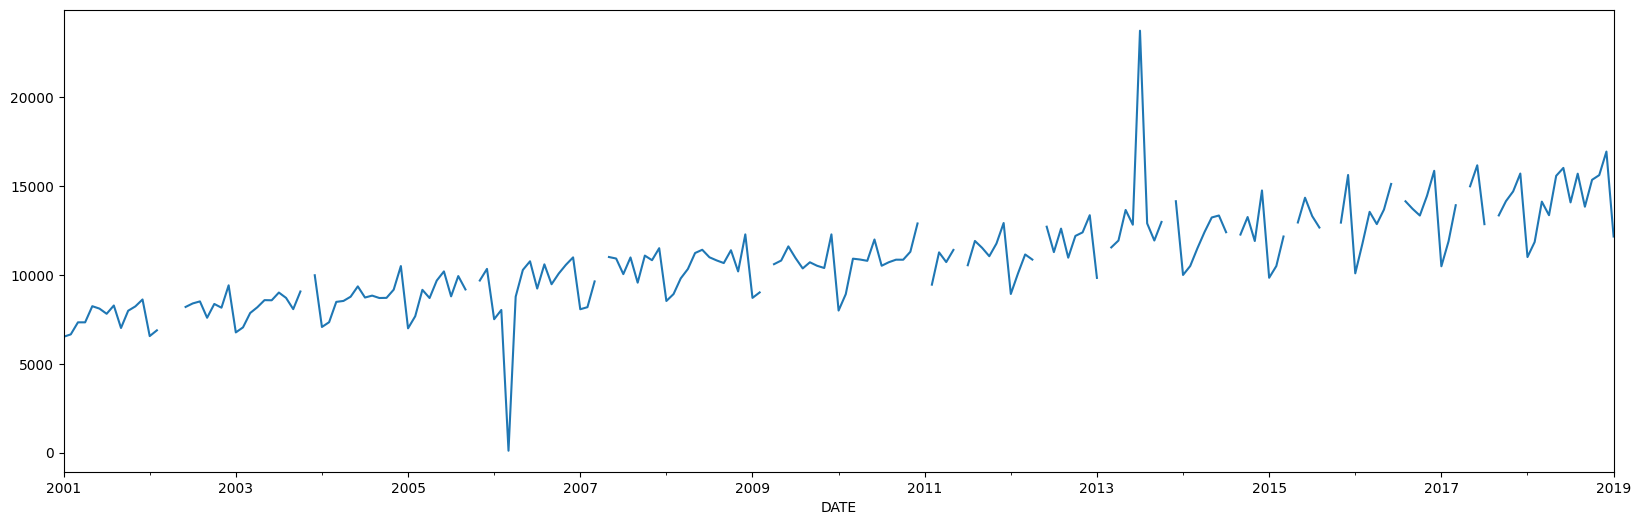

In [ ]:
mobile_sales.Sales.plot()

In [ ]:
mobile_sales.isna().sum()

,0
Sales,19


In [ ]:
mobile_sales.loc[mobile_sales.Sales.isna()]

,Sales
DATE,
2002-03-01,NaN
2002-04-01,NaN
2002-05-01,NaN
2003-11-01,NaN
2005-10-01,NaN
2007-04-01,NaN
2009-03-01,NaN
2011-01-01,NaN
2011-06-01,NaN


In [ ]:
mobile_sales.Sales.mean()

np.float64(10842.757575757576)

In [ ]:
mobile_sales.Sales.median()

10745.0

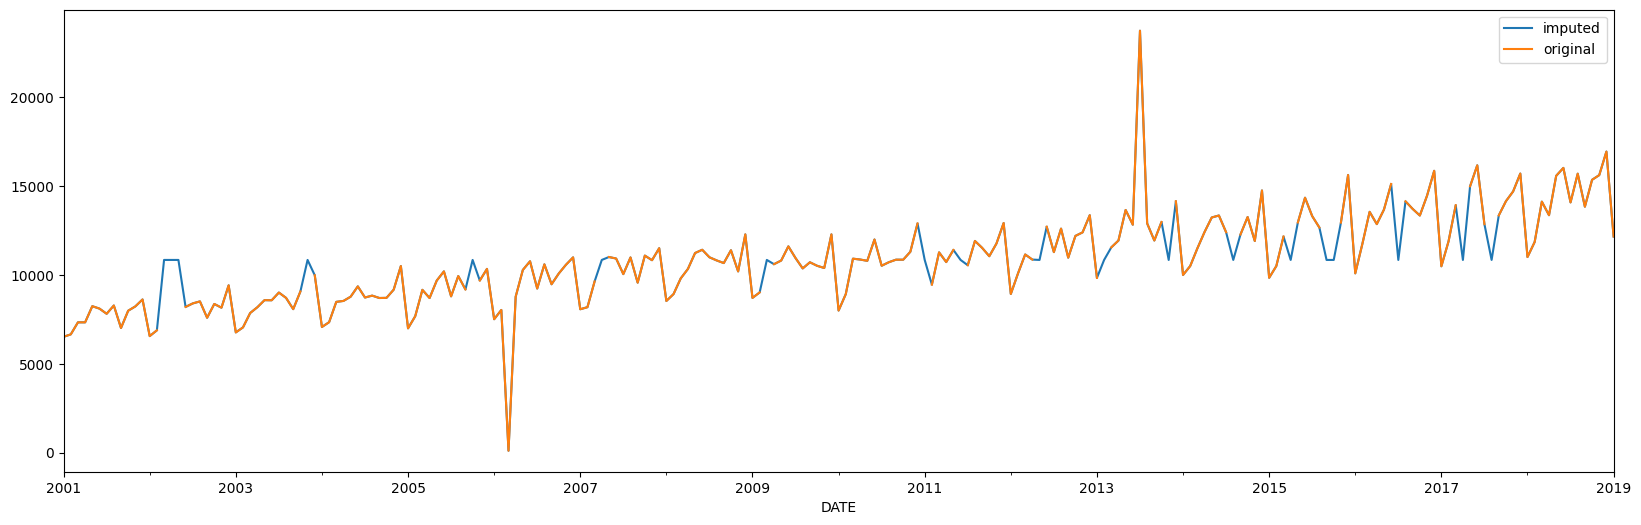

In [ ]:
mobile_sales.Sales.fillna(mobile_sales.Sales.mean()).plot(label='imputed')
mobile_sales.Sales.plot(label='original')
plt.legend()

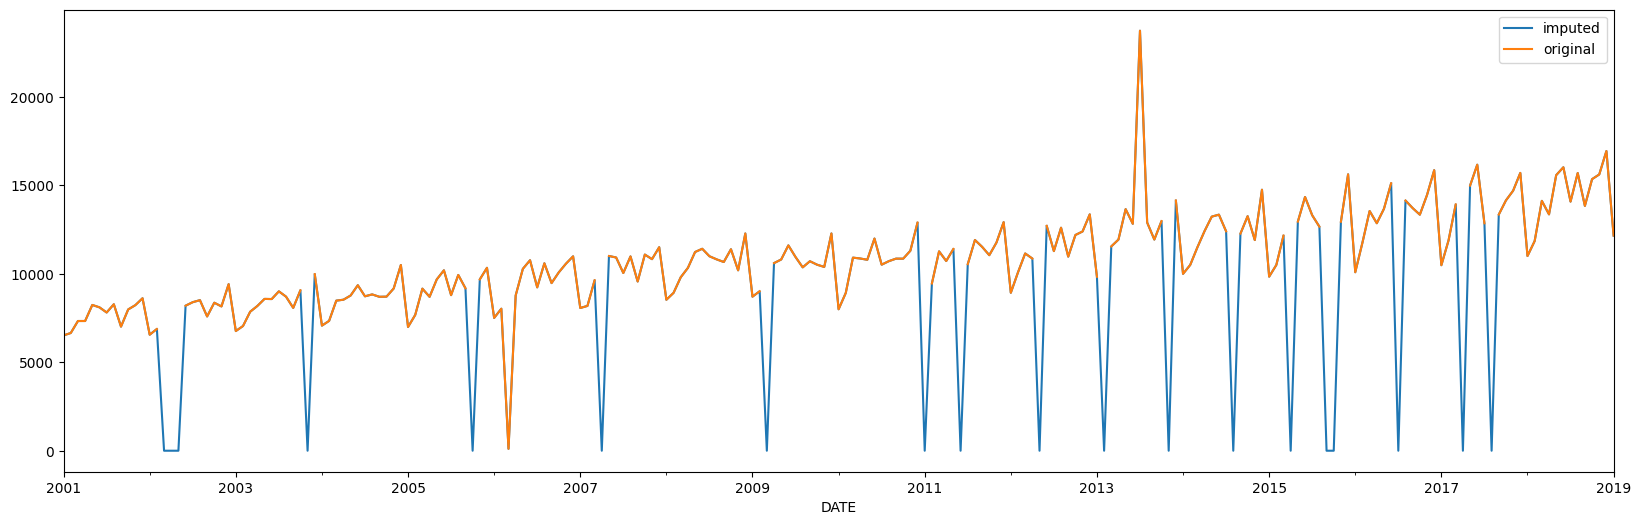

In [ ]:
mobile_sales.Sales.fillna(0).plot(label='imputed')
mobile_sales.Sales.plot(label='original')
plt.legend()

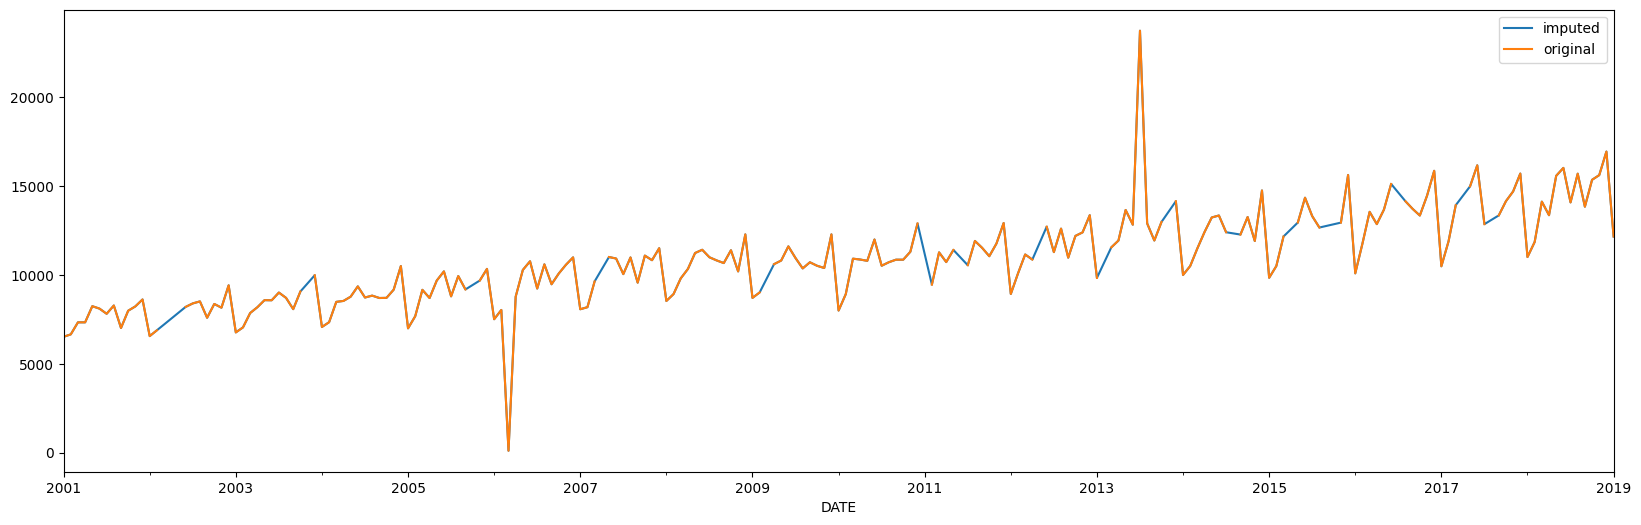

In [ ]:
mobile_sales.Sales.interpolate(method = 'linear').plot(label = 'imputed')
mobile_sales.Sales.plot(label='original')
plt.legend()

In [ ]:
mobile_sales.Sales = mobile_sales.Sales.interpolate(method = 'linear')

[]

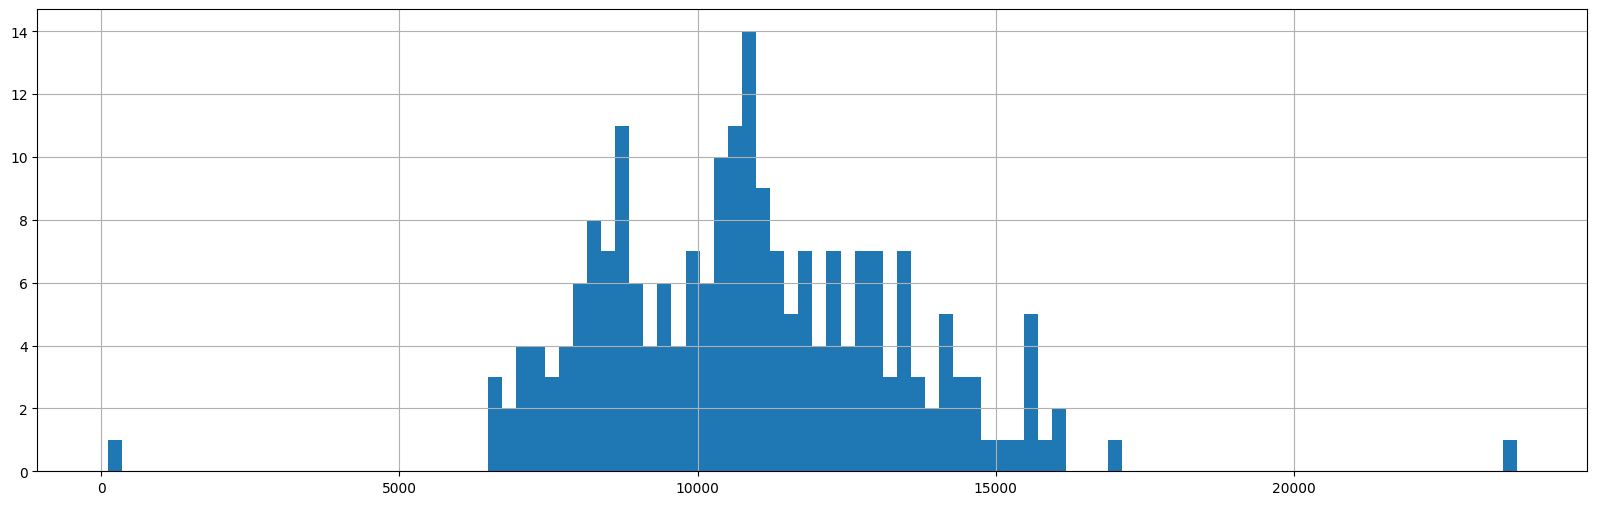

In [ ]:
mobile_sales.Sales.hist(bins=100).plot()

In [ ]:
mobile_sales.Sales.quantile(0.05)

np.float64(7307.8)

In [ ]:
mobile_sales.Sales.quantile(0.95)

np.float64(15164.599999999997)

<Axes: xlabel='DATE'>

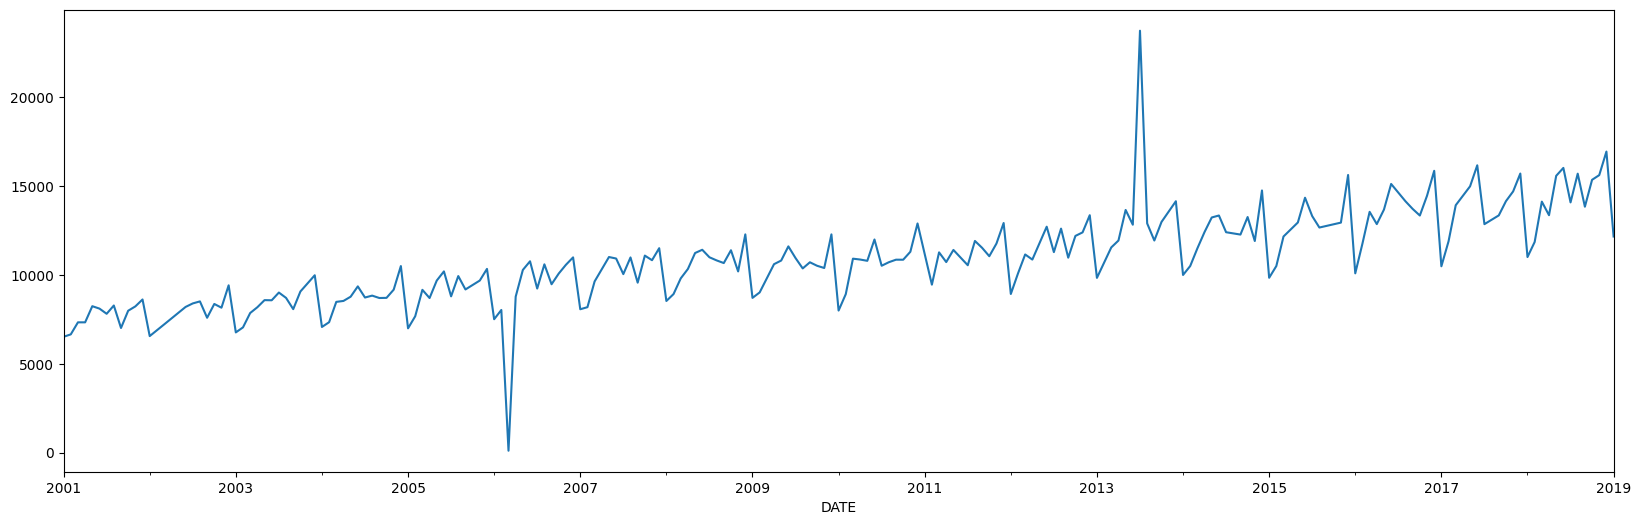

In [ ]:
mobile_sales.Sales.plot()

<Axes: xlabel='DATE'>

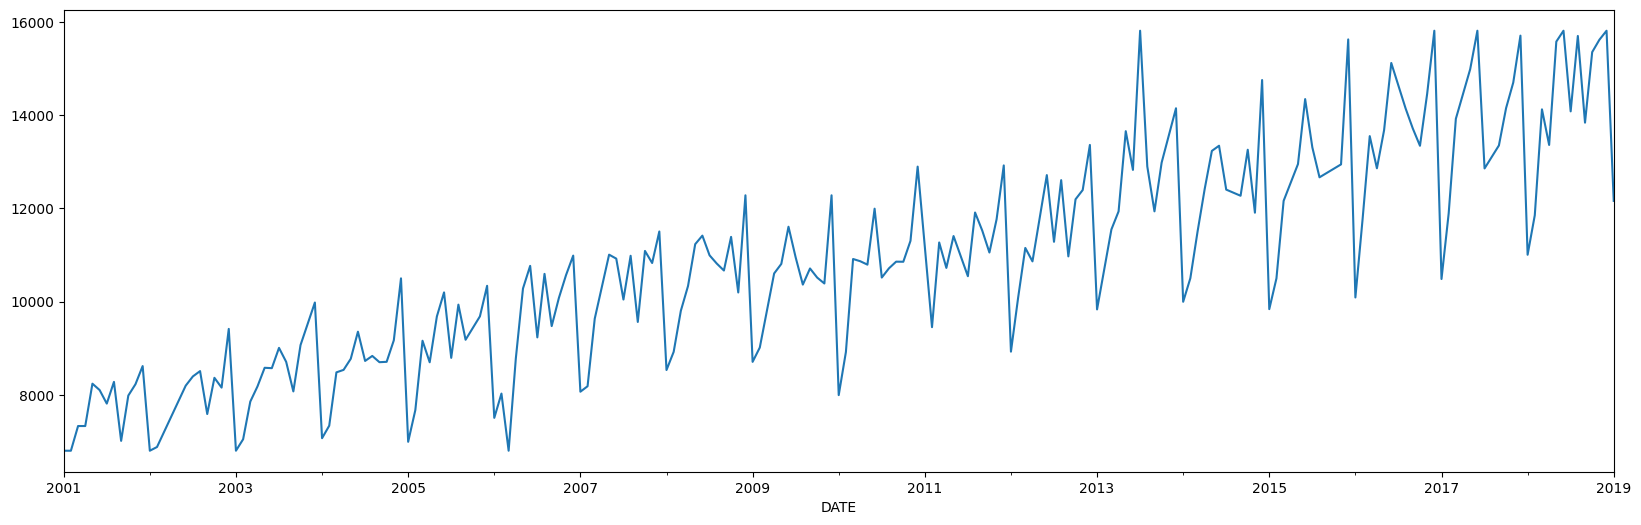

In [ ]:
mobile_sales.Sales.clip(lower = mobile_sales.Sales.quantile(0.02), upper = mobile_sales.Sales.quantile(0.98)).plot()

In [ ]:
mobile_sales.Sales = mobile_sales.Sales.clip(lower = mobile_sales.Sales.quantile(0.02), upper = mobile_sales.Sales.quantile(0.98))

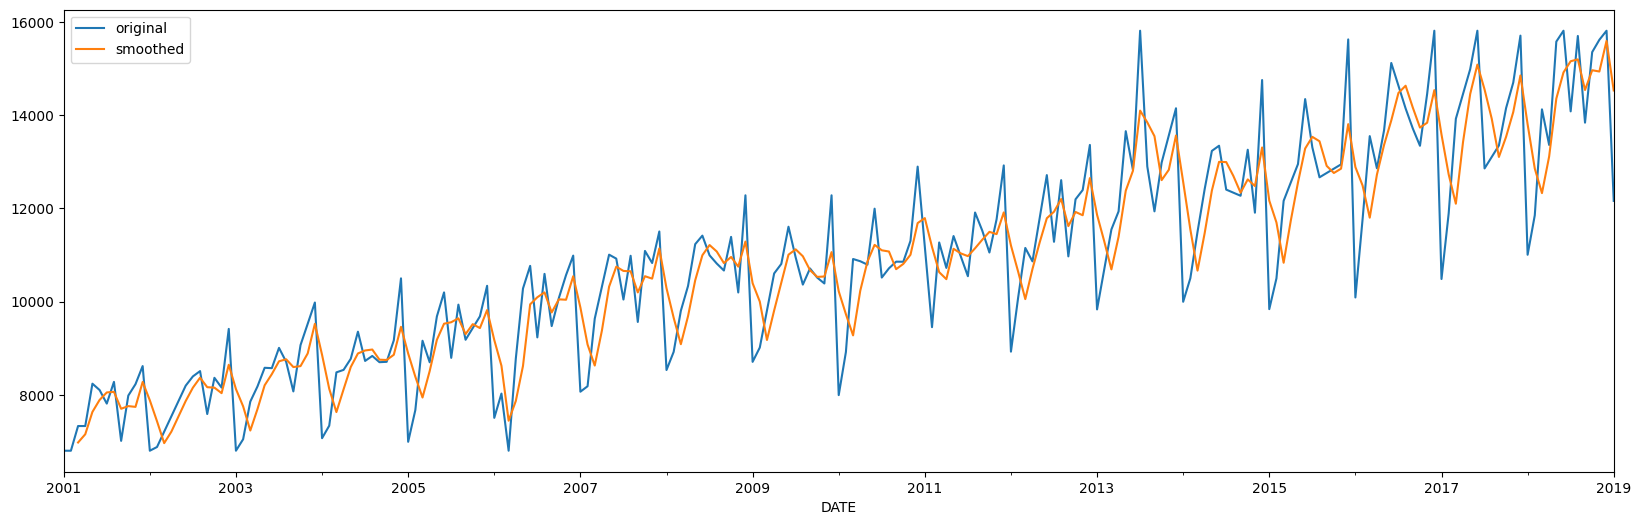

In [ ]:
mobile_sales.Sales.plot(label = 'original')
mobile_sales.Sales.rolling(3, center = False).mean().plot(label = 'smoothed')
plt.legend()

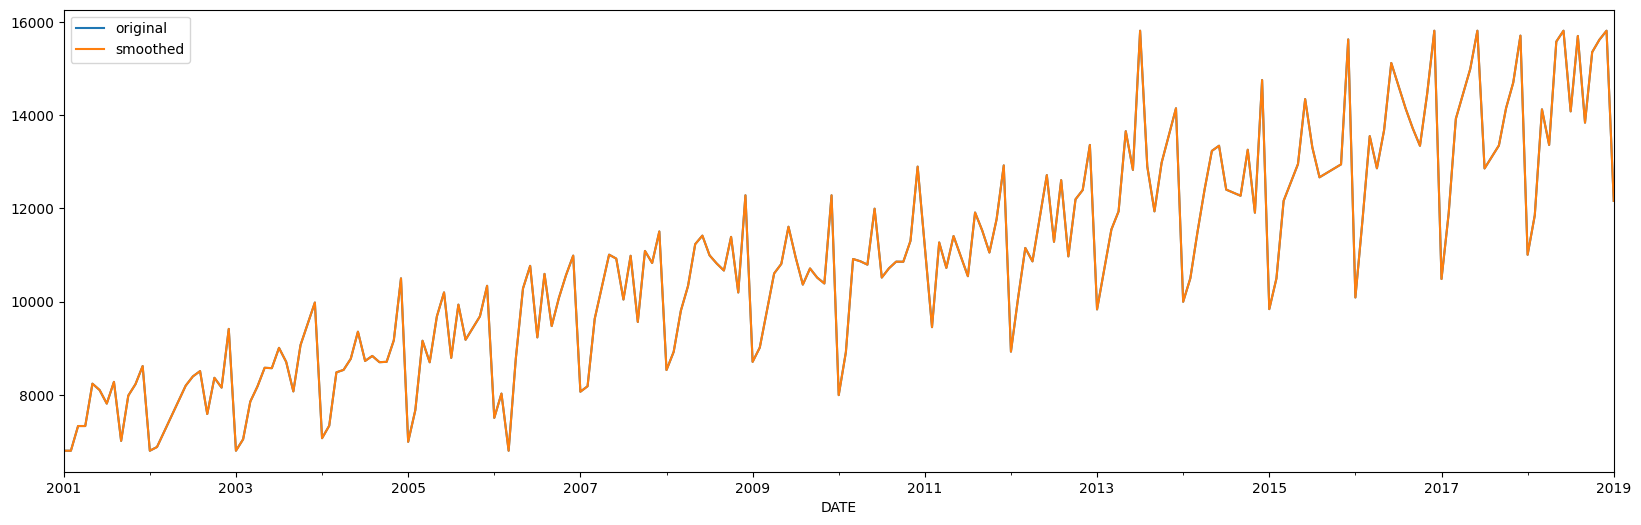

In [ ]:
mobile_sales.Sales.plot(label = 'original')
mobile_sales.Sales.rolling(1, center = False).mean().plot(label = 'smoothed')
plt.legend()

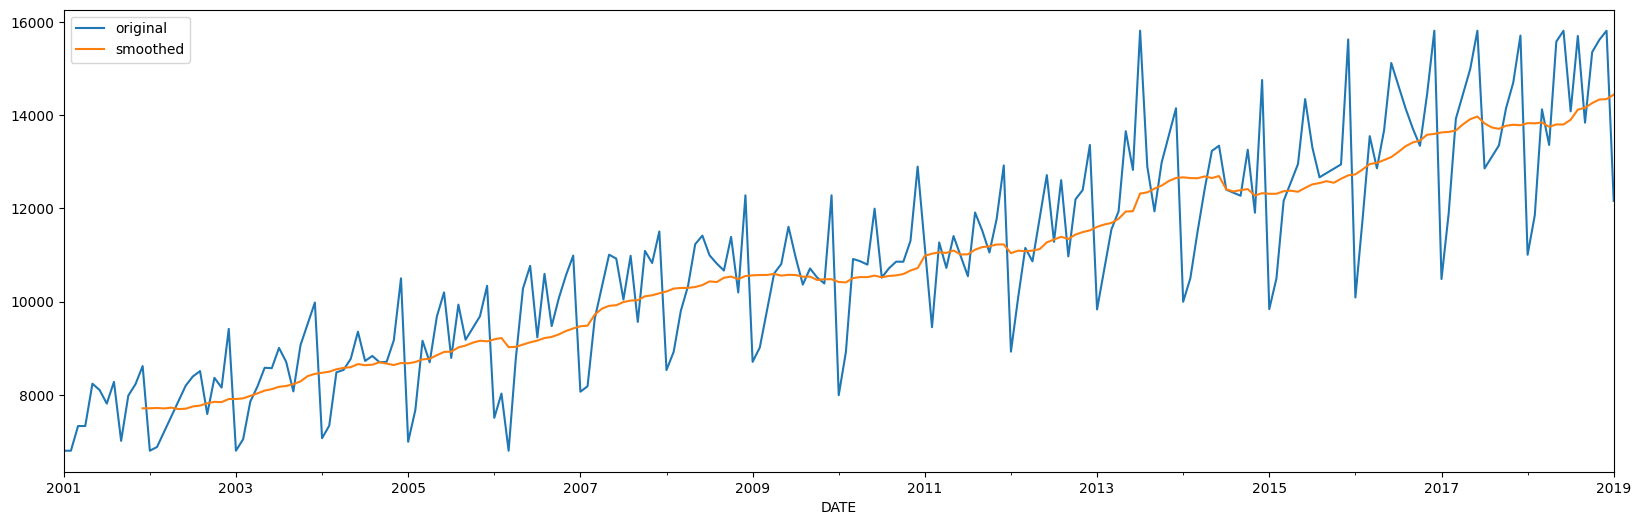

In [ ]:
mobile_sales.Sales.plot(label = 'original')
mobile_sales.Sales.rolling(12, center = False).mean().plot(label = 'smoothed')
plt.legend()

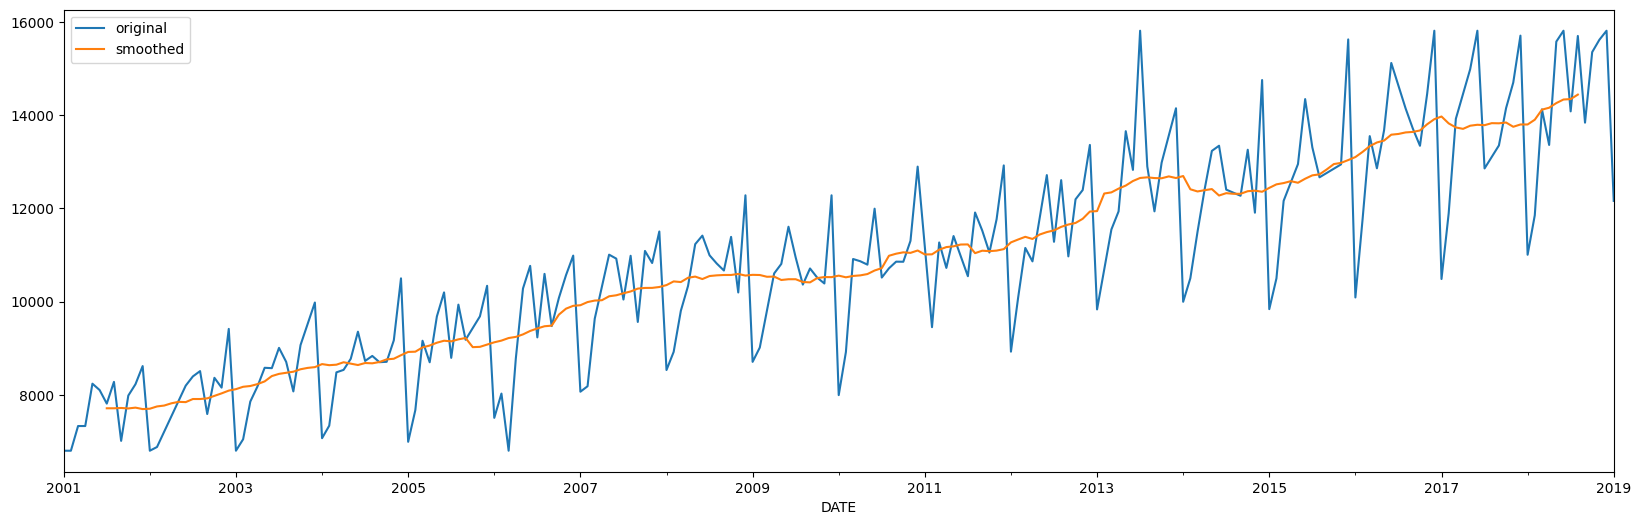

In [ ]:
mobile_sales.Sales.plot(label = 'original')
mobile_sales.Sales.rolling(12, center = True).mean().plot(label = 'smoothed')
plt.legend()

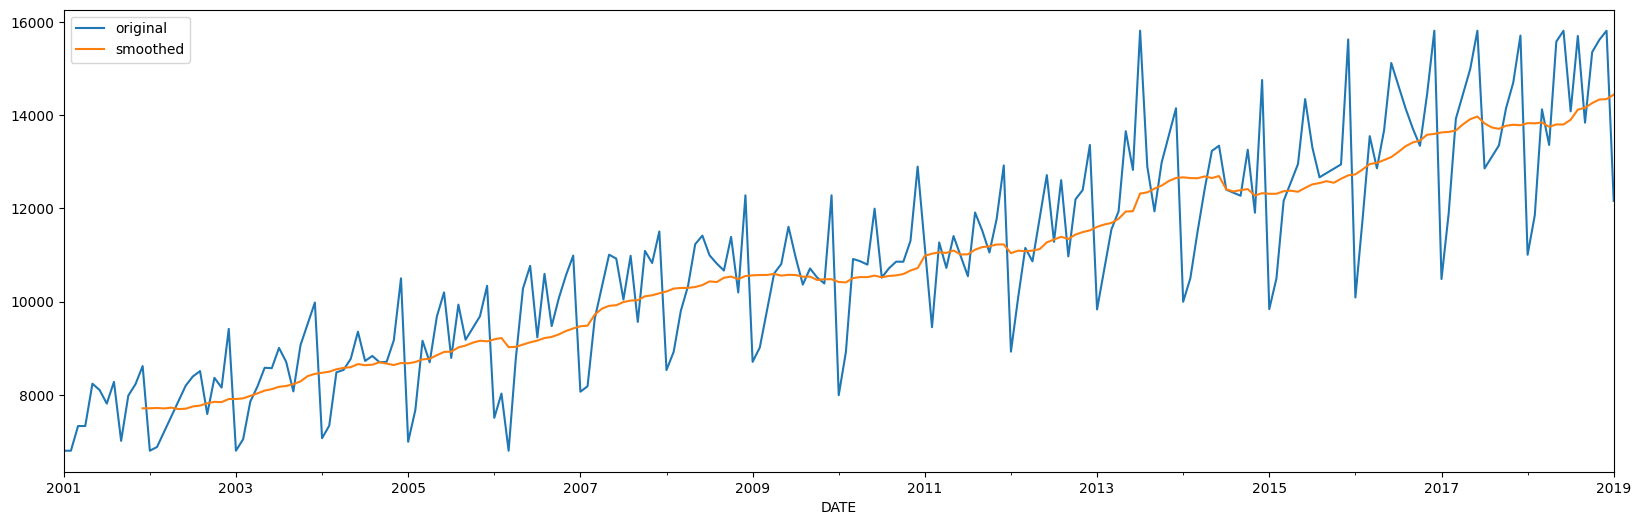

In [ ]:
mobile_sales.Sales.plot(label = 'original')
mobile_sales.Sales.rolling(12, center = False).mean().plot(label = 'smoothed')
plt.legend()

In [ ]:
import statsmodels.api as sm

model = sm.tsa.seasonal_decompose(mobile_sales.Sales, model = 'additive')

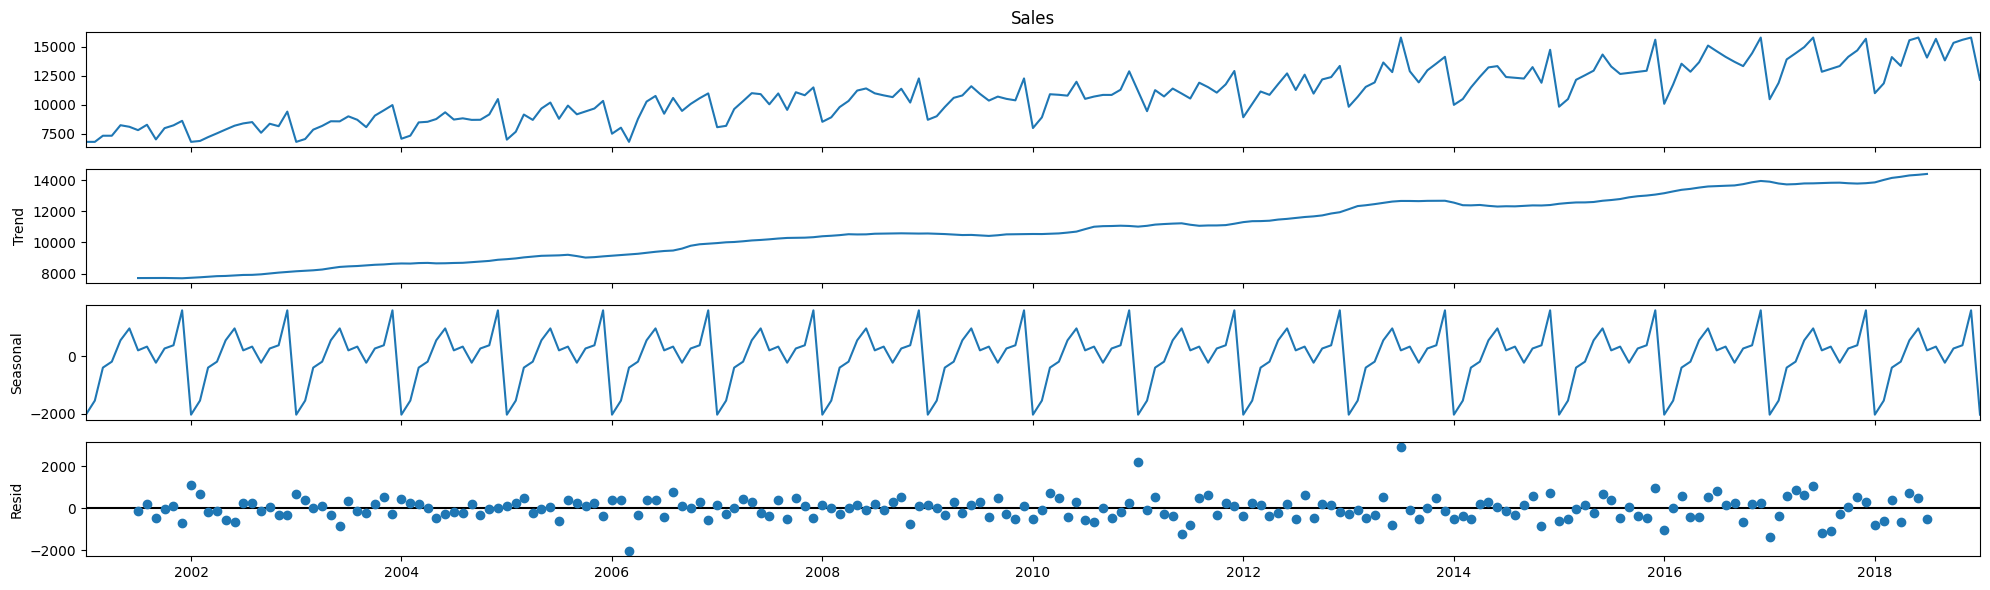

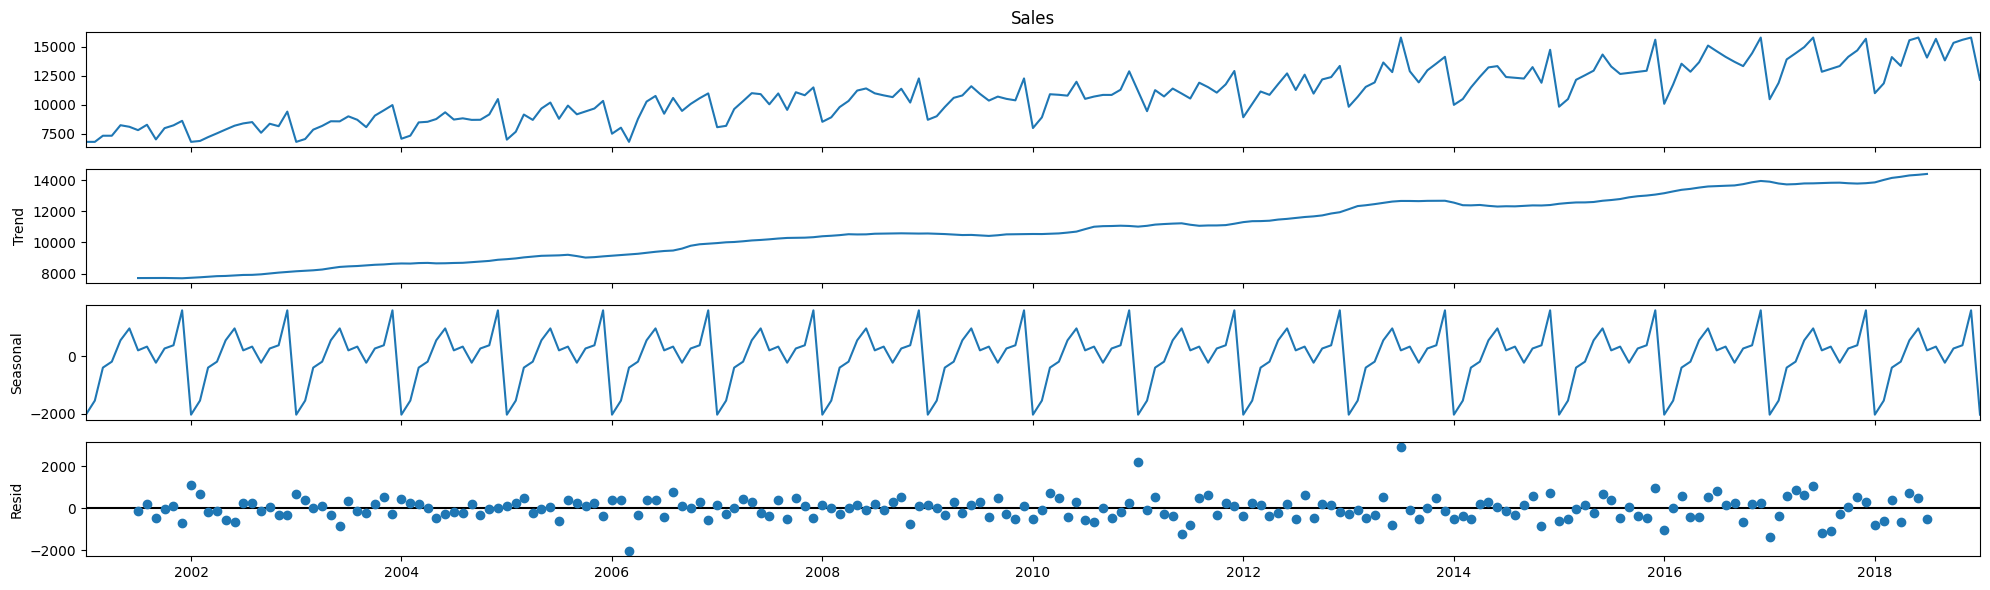

In [ ]:
model.plot()

<Axes: xlabel='DATE'>

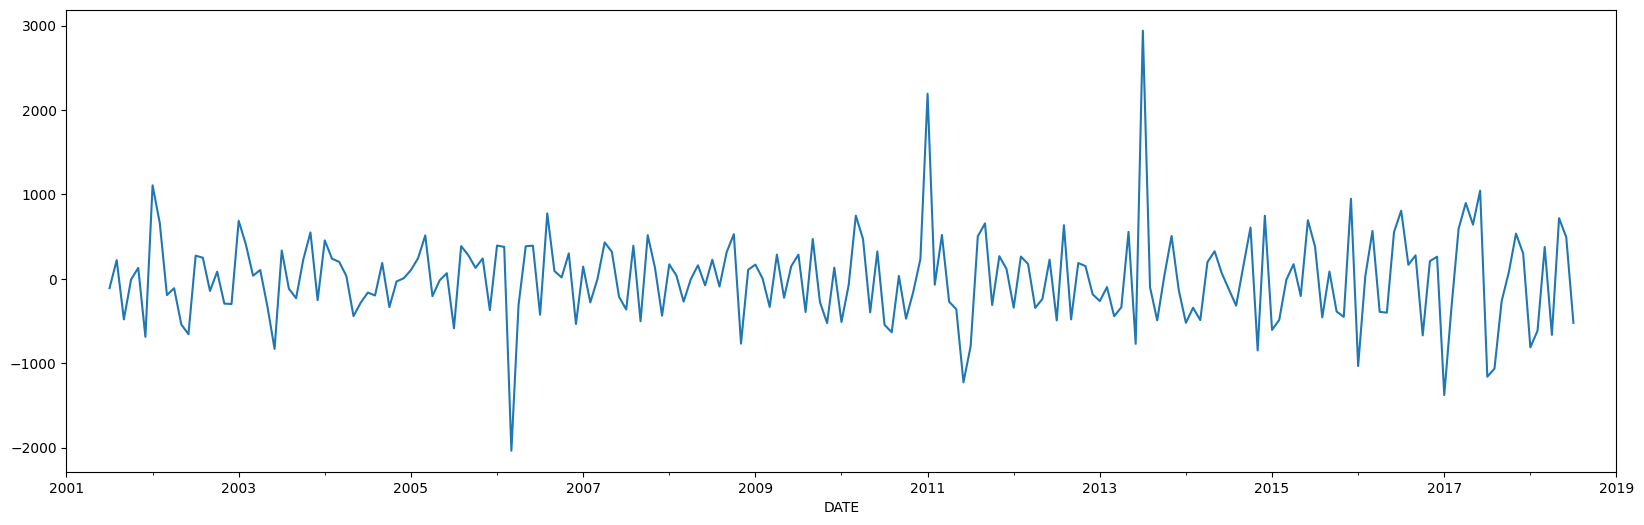

In [ ]:
model.resid.plot()

<Axes: >

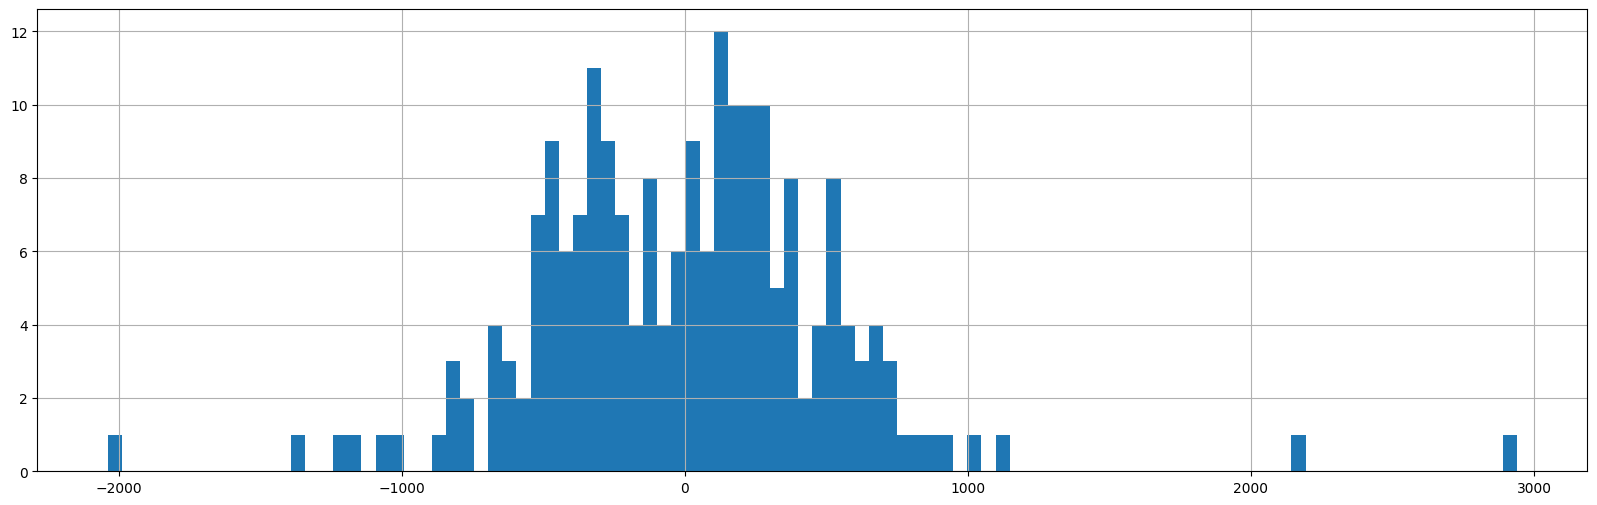

In [ ]:
model.resid.hist(bins = 100)

In [ ]:
model.resid.mean()

np.float64(-3.2316417029771514)

In [ ]:
model = sm.tsa.seasonal_decompose(mobile_sales.Sales, model = 'multiplicative')

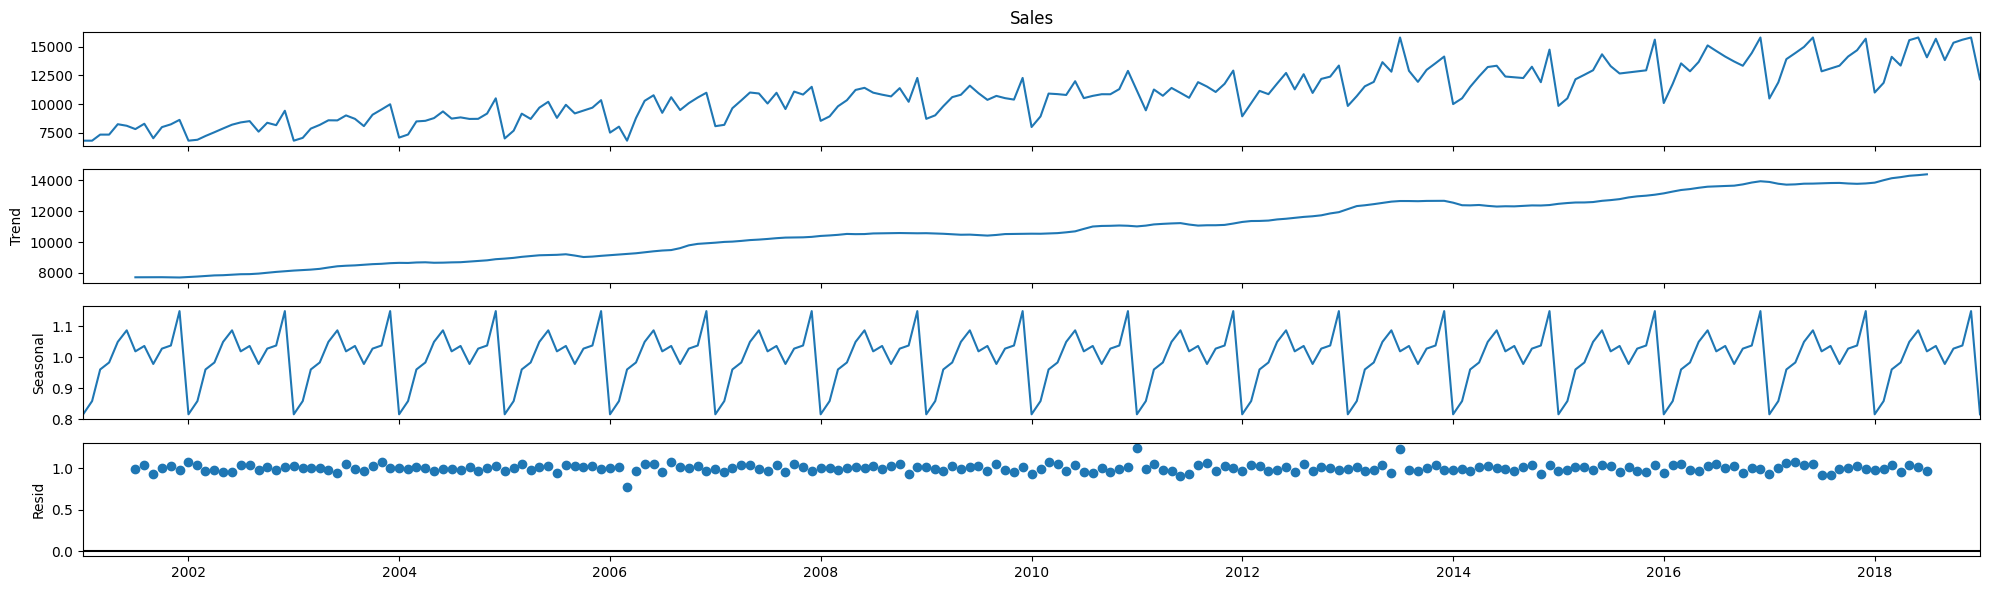

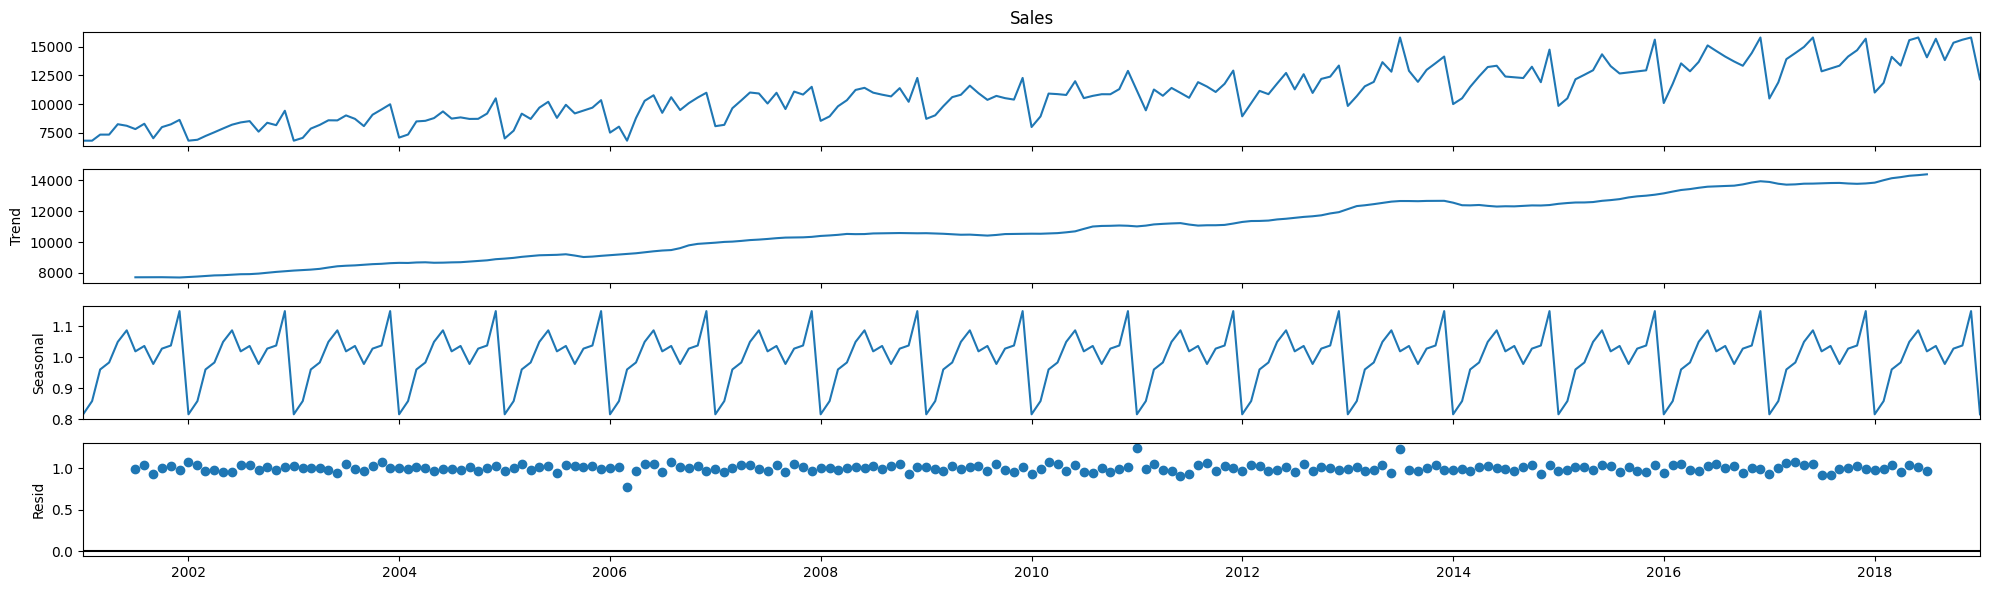

In [ ]:
model.plot()

In [ ]:
model.resid.mean()

np.float64(0.9997150886928324)

In [ ]:
mobile_sales.head()

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00


In [ ]:
train_max = mobile_sales.index[-12]

In [ ]:
train_df = mobile_sales[mobile_sales.index < train_max]
test_df = mobile_sales[mobile_sales.index >= train_max]

In [ ]:
train_df.tail()

,Sales
DATE,
2017-09-01,13349.0
2017-10-01,14150.0
2017-11-01,14698.0
2017-12-01,15704.0
2018-01-01,11005.0


In [ ]:
test_df.tail()

,Sales
DATE,
2018-09-01,13838.0
2018-10-01,15351.0
2018-11-01,15615.0
2018-12-01,15809.4
2019-01-01,12160.0


In [ ]:
train_df.shape, test_df.shape

((205, 1), (12, 1))

In [ ]:
from sklearn.metrics import(
    mean_absolute_error as mae,
    mean_squared_error as mse,
    mean_absolute_percentage_error as mape
)

def performance(actual, predicted):
  print(f'MAE: {round(mae(actual, predicted), 2)}')
  print(f'MSE: {round(mse(actual, predicted), 2)}')
  print(f'MAPE: {round(mape(actual, predicted), 2)}')

In [ ]:
train_df['Sales'].mean()

np.float64(10653.201951219511)

In [ ]:
test_df['pred'] = train_df['Sales'].mean()

/tmp/ipykernel_37430/860781320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred'] = train_df['Sales'].mean()


In [ ]:
test_df

,Sales,pred
DATE,,
2018-02-01,11852.0,10653.201951
2018-03-01,14123.0,10653.201951
2018-04-01,13360.0,10653.201951
2018-05-01,15576.0,10653.201951
2018-06-01,15809.4,10653.201951
2018-07-01,14080.0,10653.201951
2018-08-01,15697.0,10653.201951
2018-09-01,13838.0,10653.201951
2018-10-01,15351.0,10653.201951


<Axes: xlabel='DATE'>

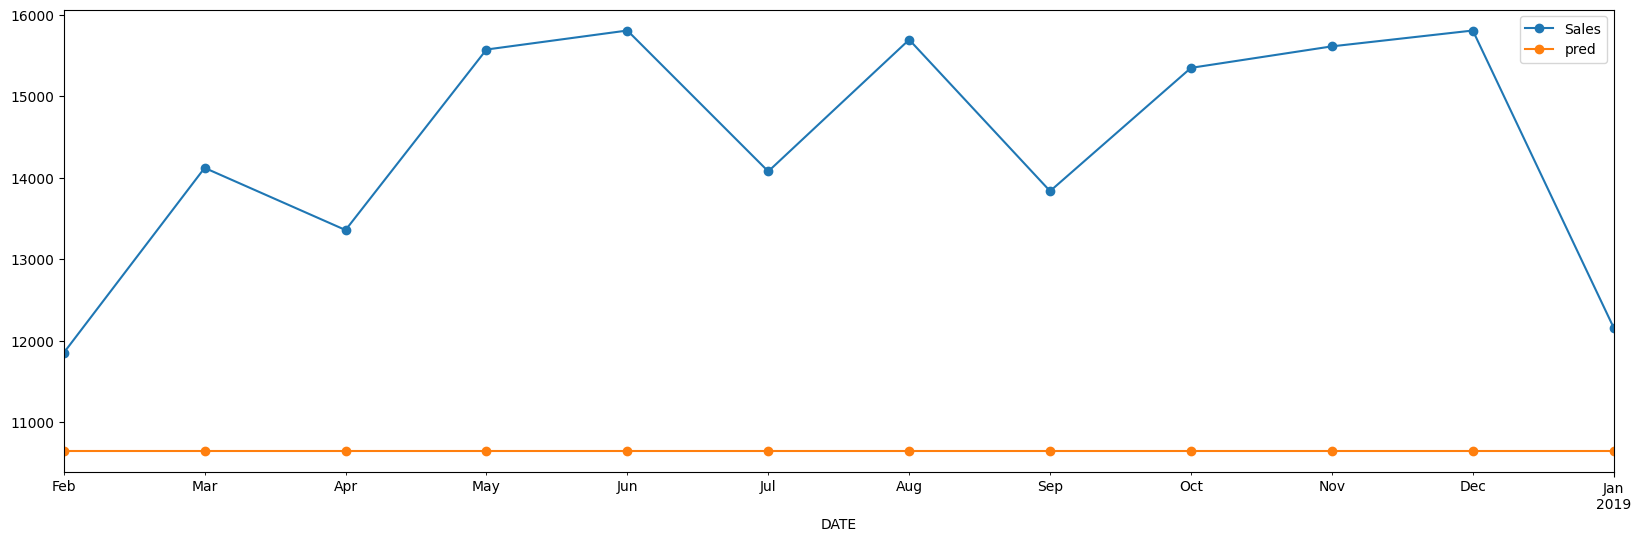

In [ ]:
test_df.plot(style = '-o')

In [ ]:
performance(test_df['Sales'], test_df['pred'])

MAE: 3786.03
MSE: 16207919.77
MAPE: 0.26


In [ ]:
test_df['pred'] = train_df['Sales'][-1]
test_df

/tmp/ipykernel_37430/1121780015.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_df['pred'] = train_df['Sales'][-1]
/tmp/ipykernel_37430/1121780015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred'] = train_df['Sales'][-1]


,Sales,pred
DATE,,
2018-02-01,11852.0,11005.0
2018-03-01,14123.0,11005.0
2018-04-01,13360.0,11005.0
2018-05-01,15576.0,11005.0
2018-06-01,15809.4,11005.0
2018-07-01,14080.0,11005.0
2018-08-01,15697.0,11005.0
2018-09-01,13838.0,11005.0
2018-10-01,15351.0,11005.0


<Axes: xlabel='DATE'>

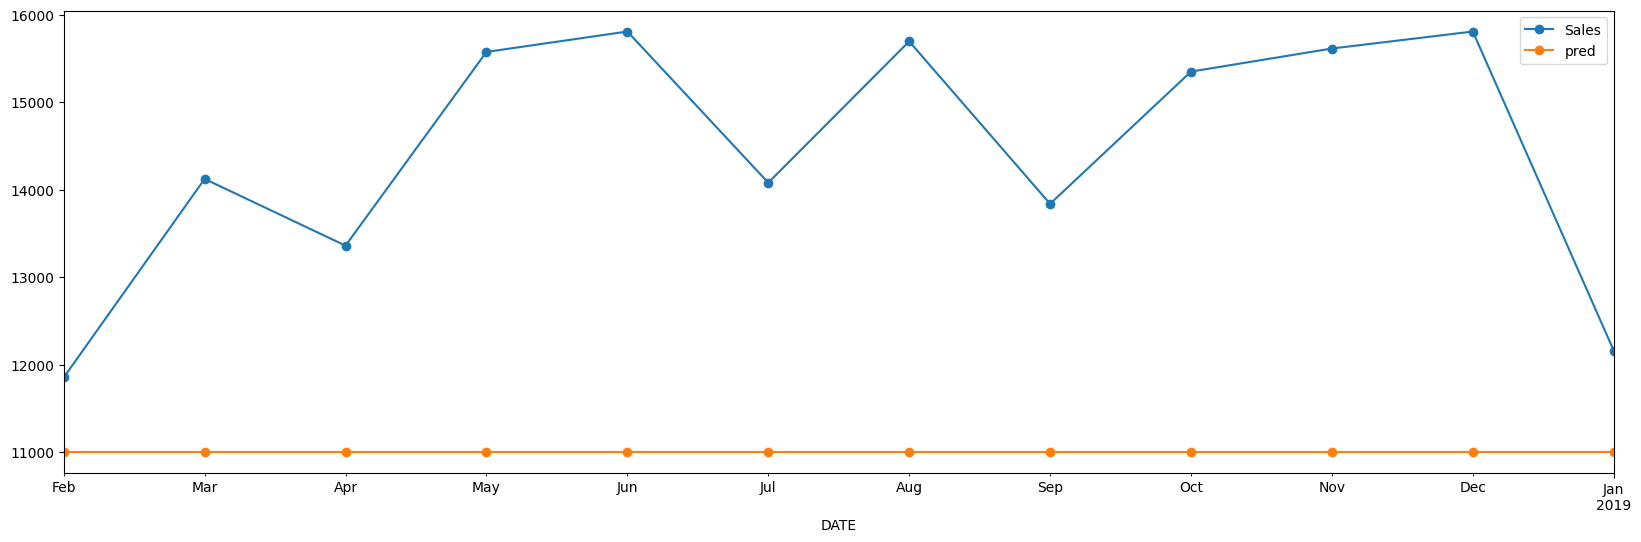

In [ ]:
test_df.plot(style = '-o')

In [ ]:
performance(test_df['Sales'], test_df['pred'])

MAE: 3434.23
MSE: 13667844.73
MAPE: 0.23


In [ ]:
train_df.index[-1]

Timestamp('2018-01-01 00:00:00')

In [ ]:
pred = []

for idx in test_df.index:
  pred.append(train_df.loc[idx - pd.DateOffset(years = 1)]['Sales'])

In [ ]:
test_df['pred'] = pred

/tmp/ipykernel_37430/4236872944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred'] = pred


In [ ]:
test_df

,Sales,pred
DATE,,
2018-02-01,11852.0,11891.0
2018-03-01,14123.0,13921.0
2018-04-01,13360.0,14453.5
2018-05-01,15576.0,14986.0
2018-06-01,15809.4,15809.4
2018-07-01,14080.0,12856.0
2018-08-01,15697.0,13102.5
2018-09-01,13838.0,13349.0
2018-10-01,15351.0,14150.0


<Axes: xlabel='DATE'>

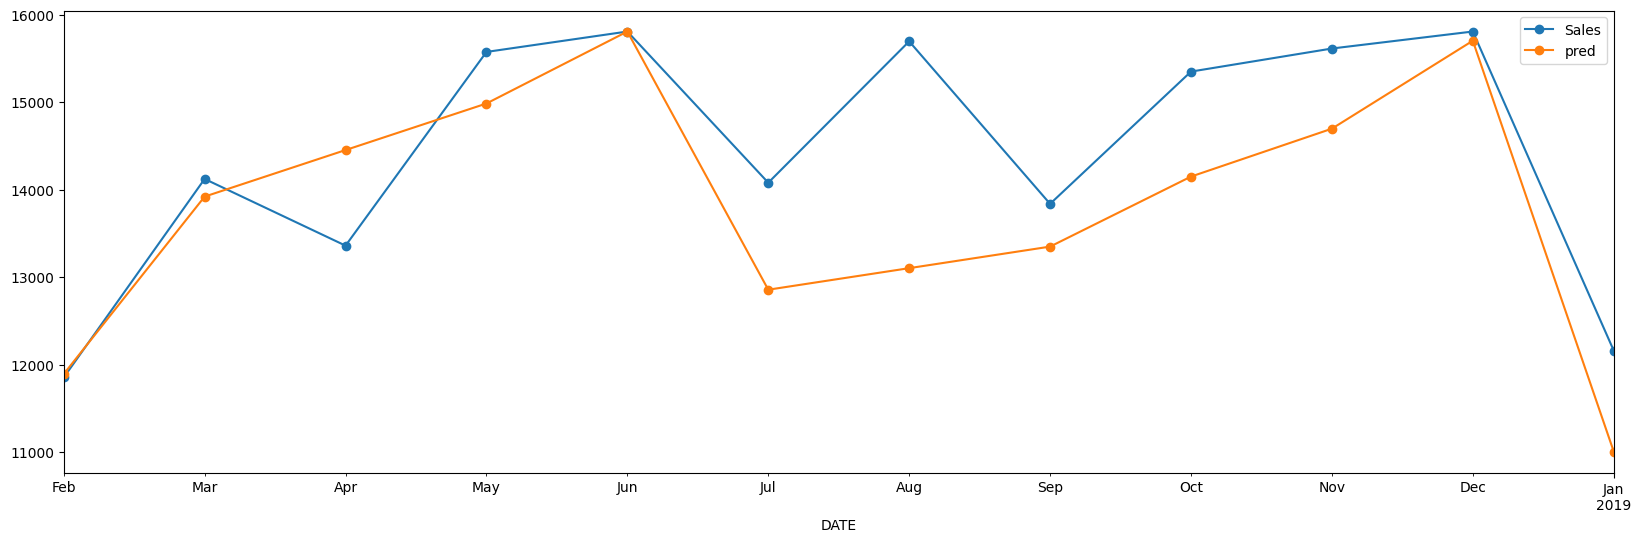

In [ ]:
test_df.plot(style = '-o')

In [ ]:
performance(test_df['Sales'], test_df['pred'])

MAE: 800.87
MSE: 1140276.55
MAPE: 0.06


In [ ]:
y0 = train_df['Sales'][0]
yt = train_df['Sales'][-1]
m = (yt - y0) / len(train_df)

x = np.arange(1, 13)

test_df['pred'] = m * x + yt
test_df

/tmp/ipykernel_37430/2053195656.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y0 = train_df['Sales'][0]
/tmp/ipykernel_37430/2053195656.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  yt = train_df['Sales'][-1]
/tmp/ipykernel_37430/2053195656.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred'] = m * x + yt


,Sales,pred
DATE,,
2018-02-01,11852.0,11025.500293
2018-03-01,14123.0,11046.000585
2018-04-01,13360.0,11066.500878
2018-05-01,15576.0,11087.001171
2018-06-01,15809.4,11107.501463
2018-07-01,14080.0,11128.001756
2018-08-01,15697.0,11148.502049
2018-09-01,13838.0,11169.002341
2018-10-01,15351.0,11189.502634


<Axes: xlabel='DATE'>

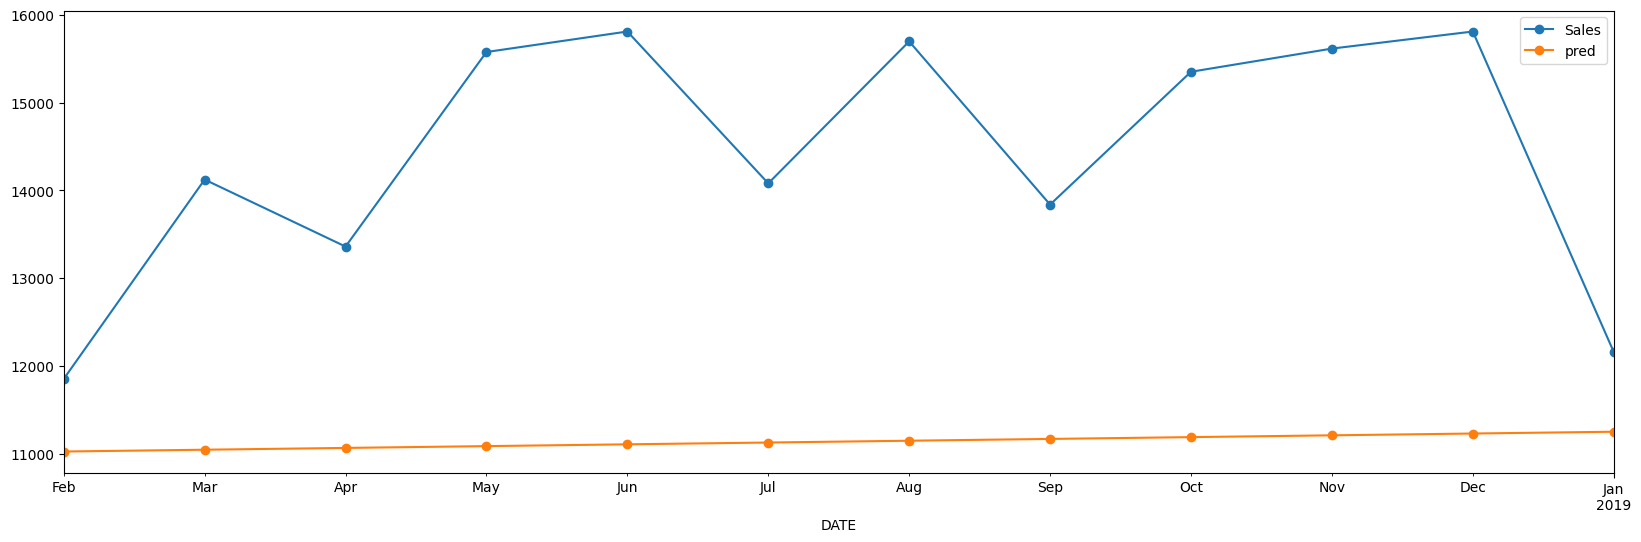

In [ ]:
test_df.plot(style = '-o')

In [ ]:
performance(test_df['Sales'], test_df['pred'])

MAE: 3300.98
MSE: 12725952.61
MAPE: 0.22


In [ ]:
pred_ = train_df.Sales.copy().values

In [ ]:
len(pred_)

205

In [ ]:
type(pred_)

numpy.ndarray

In [ ]:
pred_[-1:-13:-1].mean()

np.float64(13827.116666666667)

In [ ]:
for i in range(12):
  pred_ = np.append(pred_, pred_[-1:-13:-1].mean())

In [ ]:
len(pred_)

217

In [ ]:
pred_

array([ 6802.44      ,  6802.44      ,  7332.        ,  7332.        ,
        8240.        ,  8104.        ,  7813.        ,  8279.        ,
        7014.        ,  7985.        ,  8229.        ,  8618.        ,
        6802.44      ,  6882.        ,  7211.        ,  7540.        ,
        7869.        ,  8198.        ,  8396.        ,  8510.        ,
        7589.        ,  8366.        ,  8156.        ,  9415.        ,
        6802.44      ,  7048.        ,  7856.        ,  8181.        ,
        8581.        ,  8573.        ,  9008.        ,  8708.        ,
        8074.        ,  9068.        ,  9524.5       ,  9981.        ,
        7071.        ,  7339.        ,  8483.        ,  8536.        ,
        8774.        ,  9355.        ,  8728.        ,  8835.        ,
        8701.        ,  8709.        ,  9170.        , 10499.        ,
        6994.        ,  7675.        ,  9161.        ,  8699.        ,
        9682.        , 10198.        ,  8794.        ,  9935.        ,
      

In [ ]:
test_df['pred'] = pred_[-12:]

/tmp/ipykernel_37430/1653536980.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred'] = pred_[-12:]


In [ ]:
test_df['pred']

,pred
DATE,
2018-02-01,13827.116667
2018-03-01,13988.459722
2018-04-01,13994.081366
2018-05-01,13955.796480
2018-06-01,13869.946186
2018-07-01,13708.325035
2018-08-01,13779.352121
2018-09-01,13835.756465
2018-10-01,13876.319503


<Axes: xlabel='DATE'>

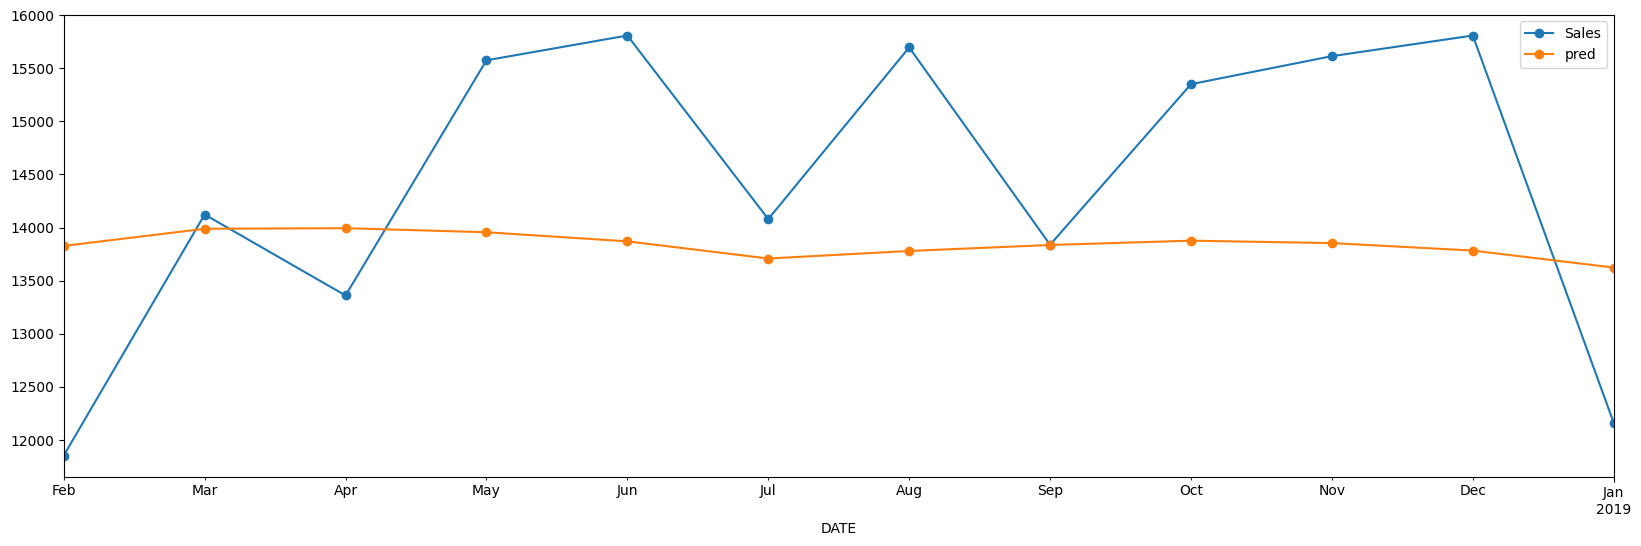

In [ ]:
test_df.plot(style = '-o')

<Axes: xlabel='DATE'>

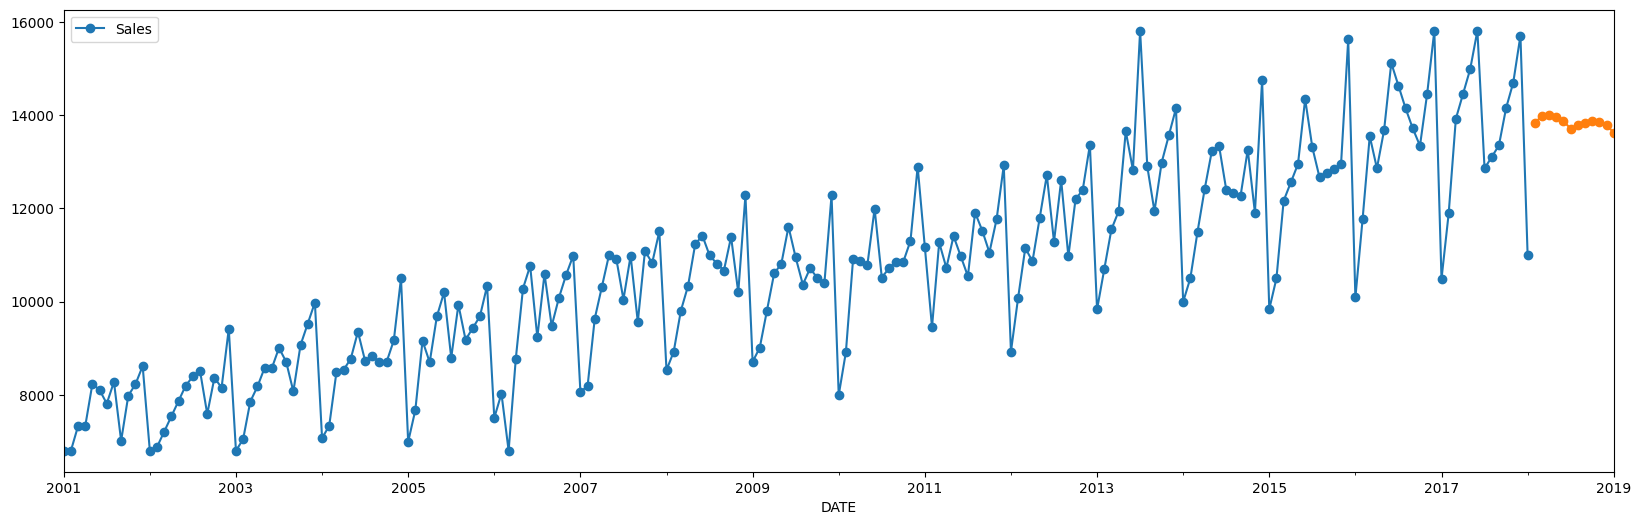

In [ ]:
train_df.plot(style = '-o')
test_df['pred'].plot(style = '-o')

In [ ]:
performance(test_df['Sales'], test_df['pred'])

MAE: 1276.7
MSE: 2170593.89
MAPE: 0.09


In [ ]:
mobile_sales.head()

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00


In [ ]:
mobile_sales.tail()

,Sales
DATE,
2018-09-01,13838.0
2018-10-01,15351.0
2018-11-01,15615.0
2018-12-01,15809.4
2019-01-01,12160.0


In [ ]:
import statsmodels.api as sm

model = sm.tsa.ExponentialSmoothing(mobile_sales.Sales).fit(smoothing_level = 0.2)
pred = model.forecast(12)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
pred

,0
2019-02-01,14422.172237
2019-03-01,14422.172237
2019-04-01,14422.172237
2019-05-01,14422.172237
2019-06-01,14422.172237
2019-07-01,14422.172237
2019-08-01,14422.172237
2019-09-01,14422.172237
2019-10-01,14422.172237
2019-11-01,14422.172237


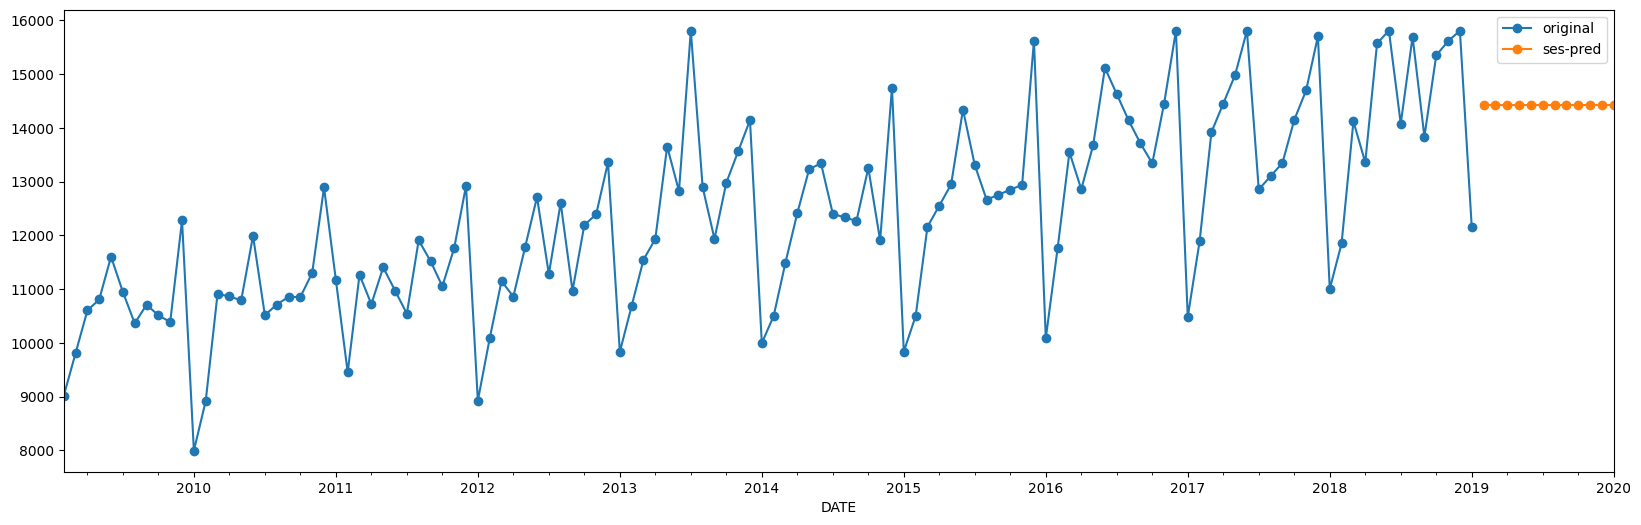

In [ ]:
mobile_sales.Sales[-120:].plot(label = 'original', style = '-o')
pred.plot(label = 'ses-pred', style = '-o')
plt.legend()

In [ ]:
model = sm.tsa.ExponentialSmoothing(mobile_sales.Sales, trend = 'add').fit(smoothing_trend = 0.02)
pred = model.forecast(12)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
pred

,0
2019-02-01,14576.014762
2019-03-01,14610.924827
2019-04-01,14645.834892
2019-05-01,14680.744957
2019-06-01,14715.655022
2019-07-01,14750.565087
2019-08-01,14785.475152
2019-09-01,14820.385217
2019-10-01,14855.295282
2019-11-01,14890.205347


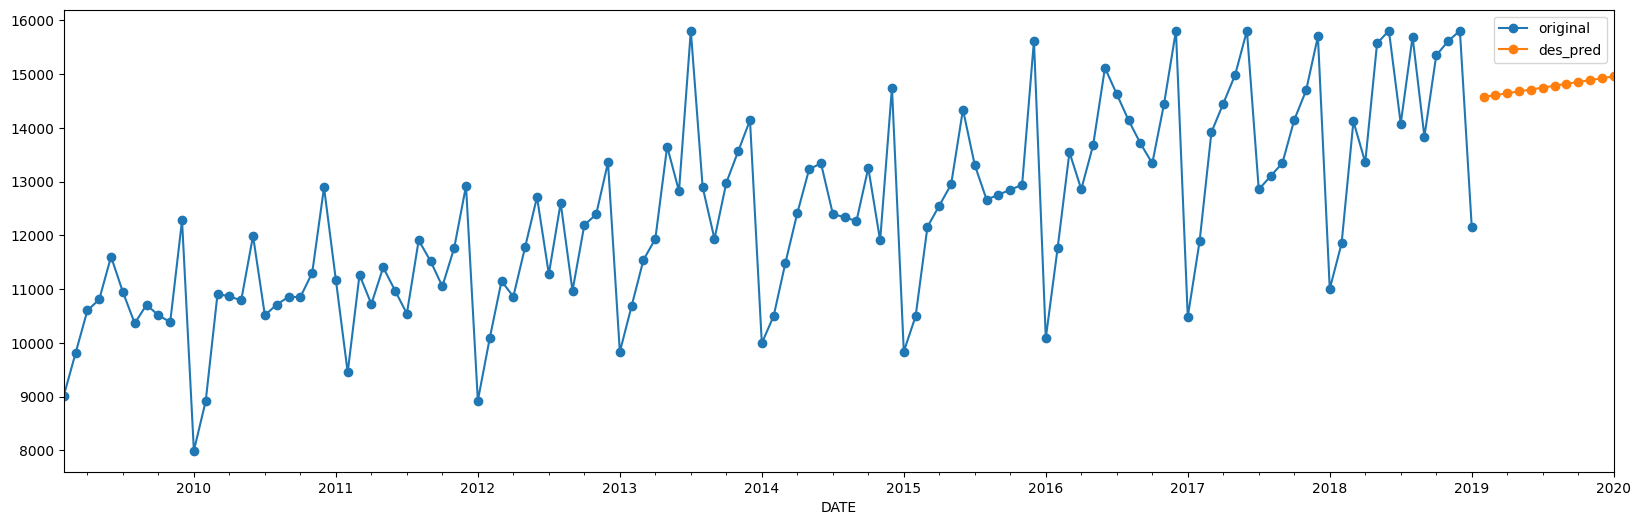

In [ ]:
mobile_sales.Sales[-120:].plot(label = 'original', style = '-o')
pred.plot(label = 'des_pred', style = '-o')
plt.legend()

In [ ]:
test_df['pred'] = pred.values

/tmp/ipykernel_37430/1208231605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred'] = pred.values


<Axes: xlabel='DATE'>

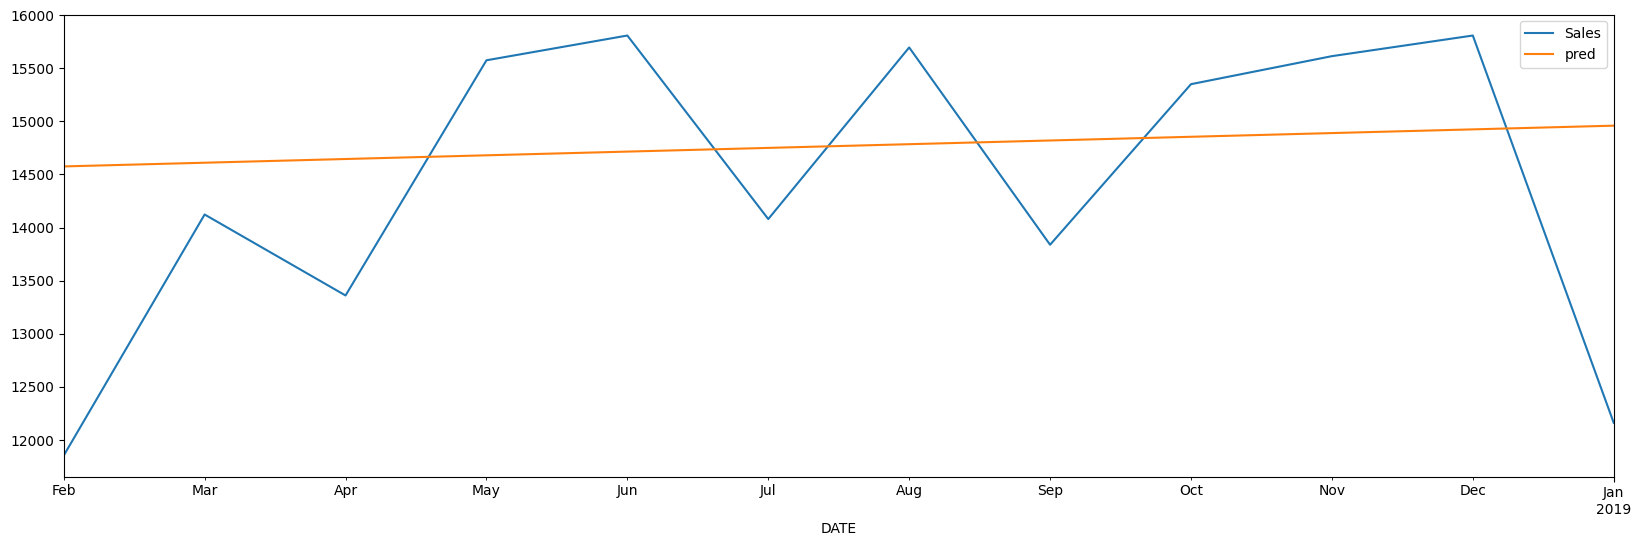

In [ ]:
test_df.plot()

In [ ]:
performance(test_df['Sales'], test_df['pred'])

MAE: 1163.0
MSE: 1912352.19
MAPE: 0.09


In [ ]:
model = sm.tsa.ExponentialSmoothing(mobile_sales.Sales, trend = 'add', seasonal = 'add').fit(smoothing_level = 0.3, smoothing_trend = 0.1, smoothing_seasonal = 0.2)
pred = model.forecast(12)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


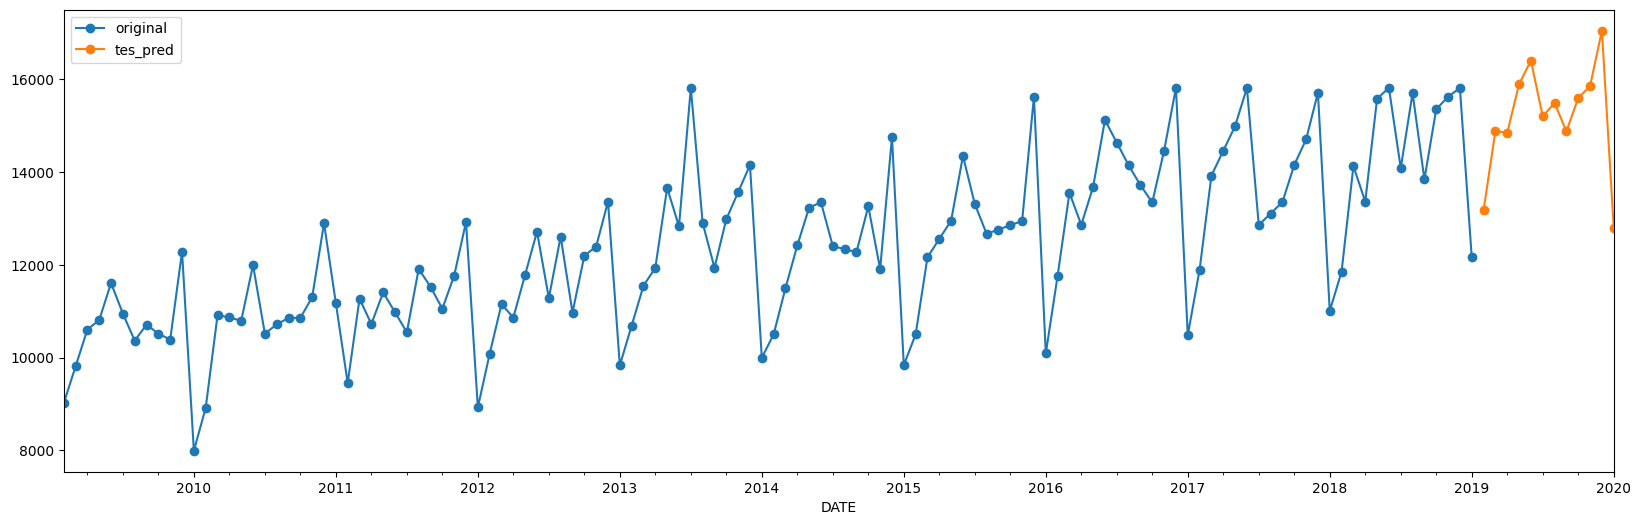

In [ ]:
mobile_sales.Sales[-120:].plot(label = 'original', style = '-o')
pred.plot(label = 'tes_pred', style = '-o')
plt.legend()

In [ ]:
test_df['pred'] = pred.values

/tmp/ipykernel_37430/1208231605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred'] = pred.values


MAE: 763.61
MSE: 778961.05
MAPE: 0.06


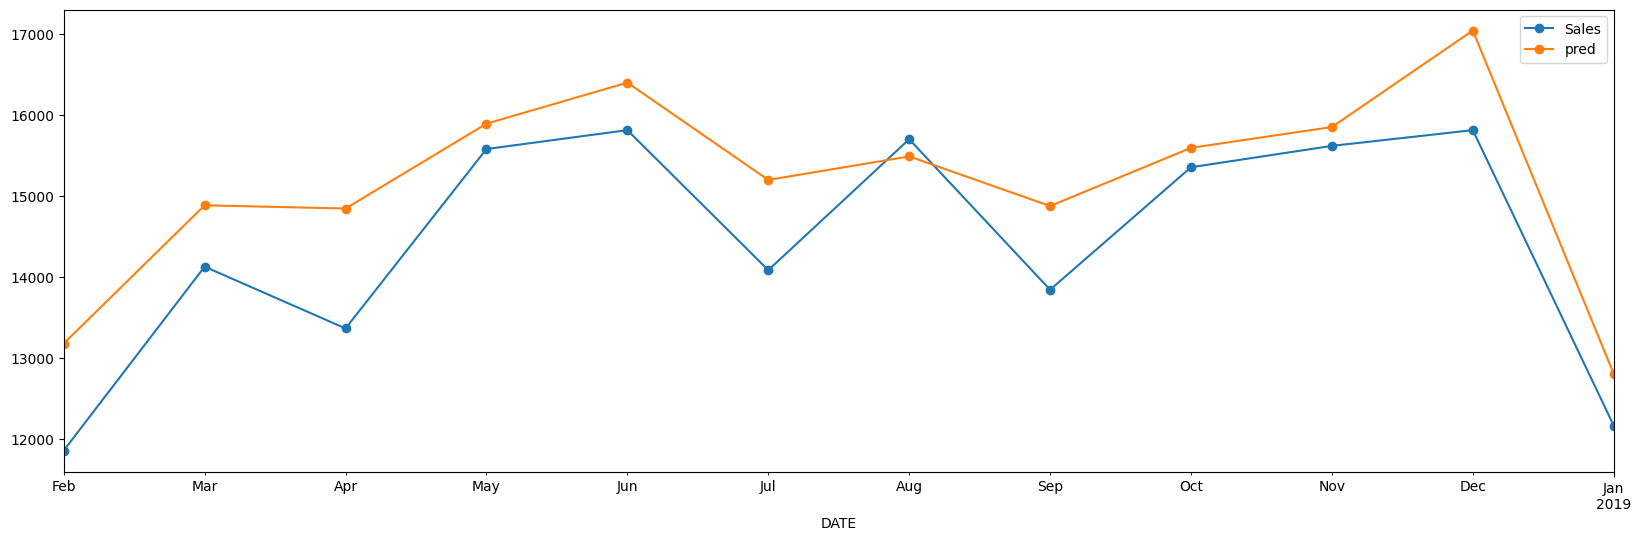

In [ ]:
test_df.plot(style = '-o')
performance(test_df['Sales'], test_df['pred'])

<Axes: xlabel='DATE'>

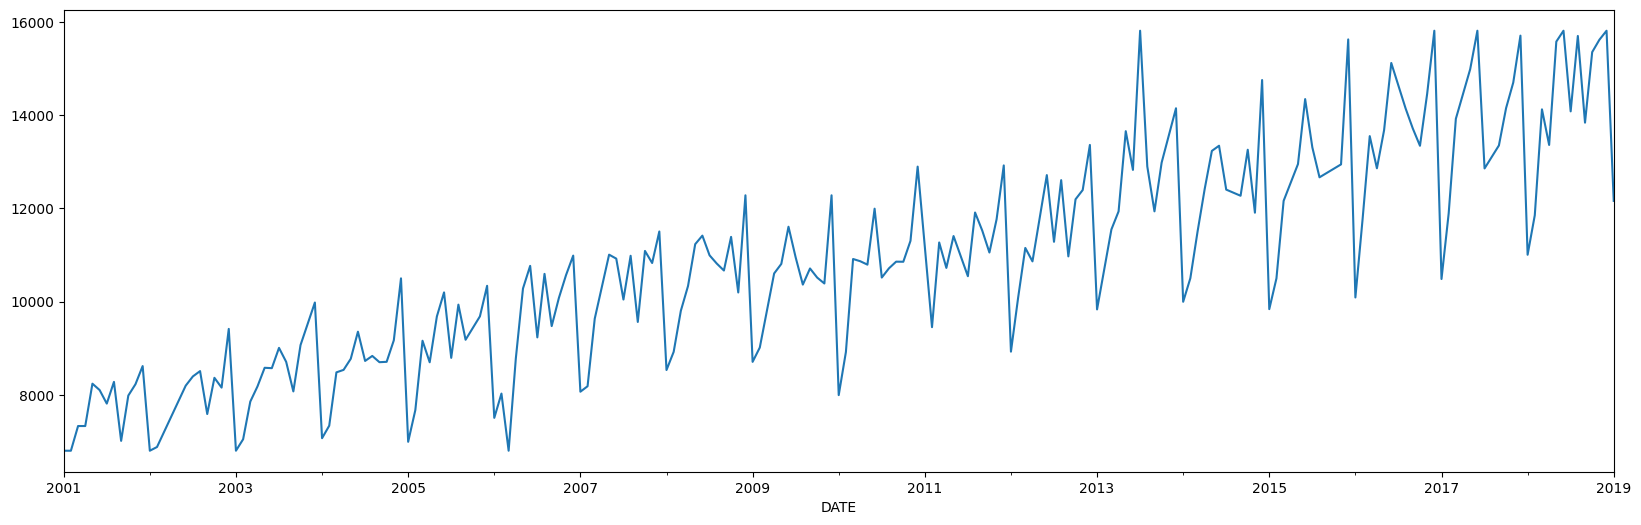

In [ ]:
mobile_sales.Sales.plot()

In [ ]:
def adf_test(data, significance_level = 0.05):
  pvalue = sm.tsa.stattools.adfuller(data)[1]
  if pvalue <= significance_level:
    print('Sequence is stationary')
  else:
    print('Sequence is not stationary')

In [ ]:
adf_test(mobile_sales.Sales)

Sequence is not stationary


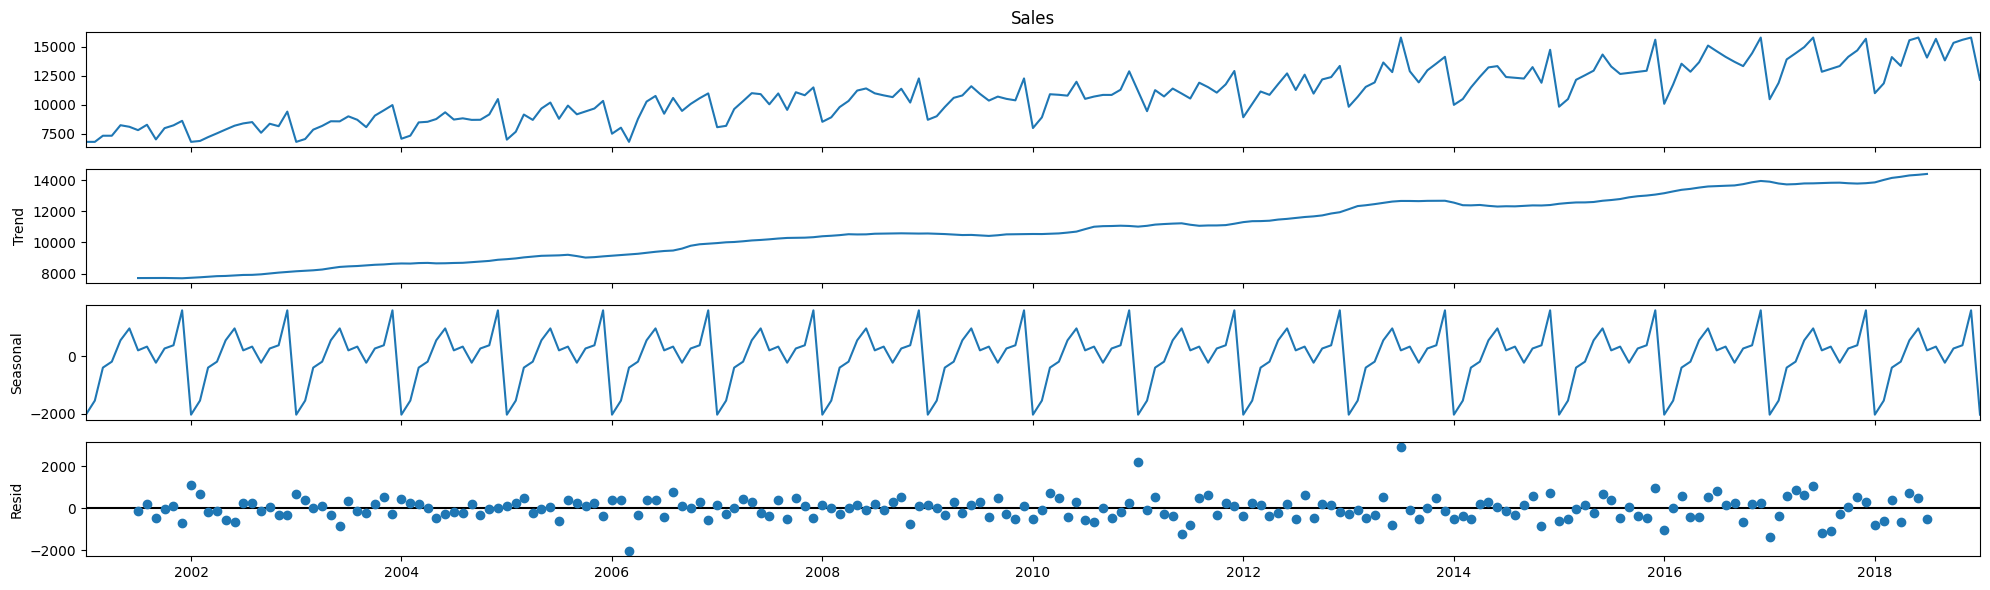

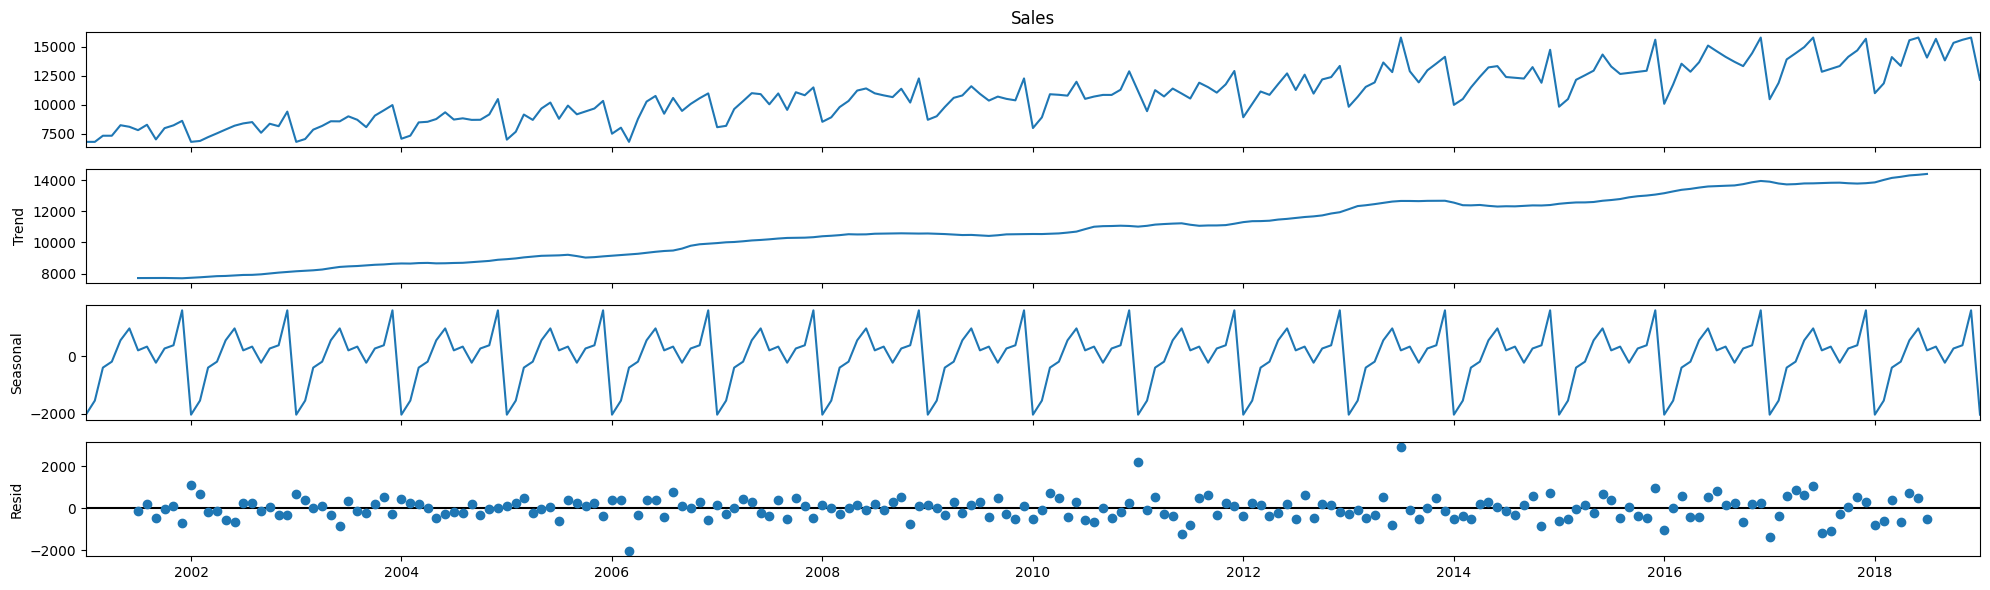

In [ ]:
model = sm.tsa.seasonal_decompose(mobile_sales.Sales)
model.plot()

<Axes: xlabel='DATE'>

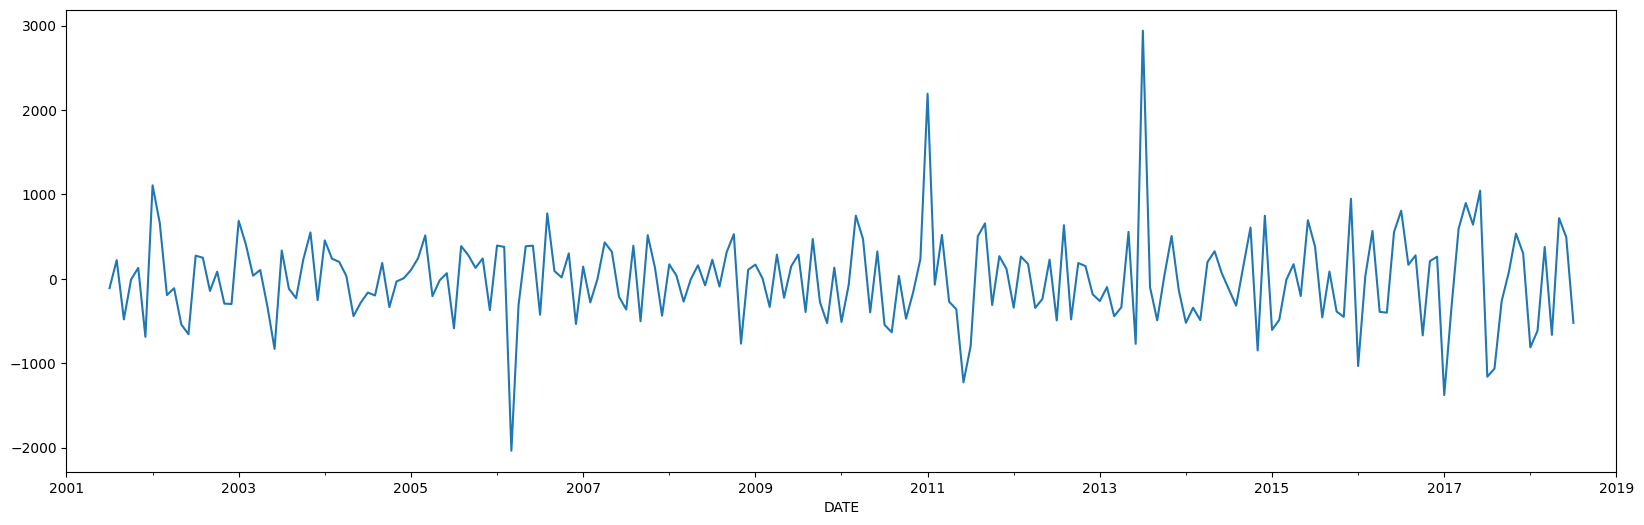

In [ ]:
model.resid.plot()

In [ ]:
adf_test(model.resid.dropna())

Sequence is stationary


<Axes: xlabel='DATE'>

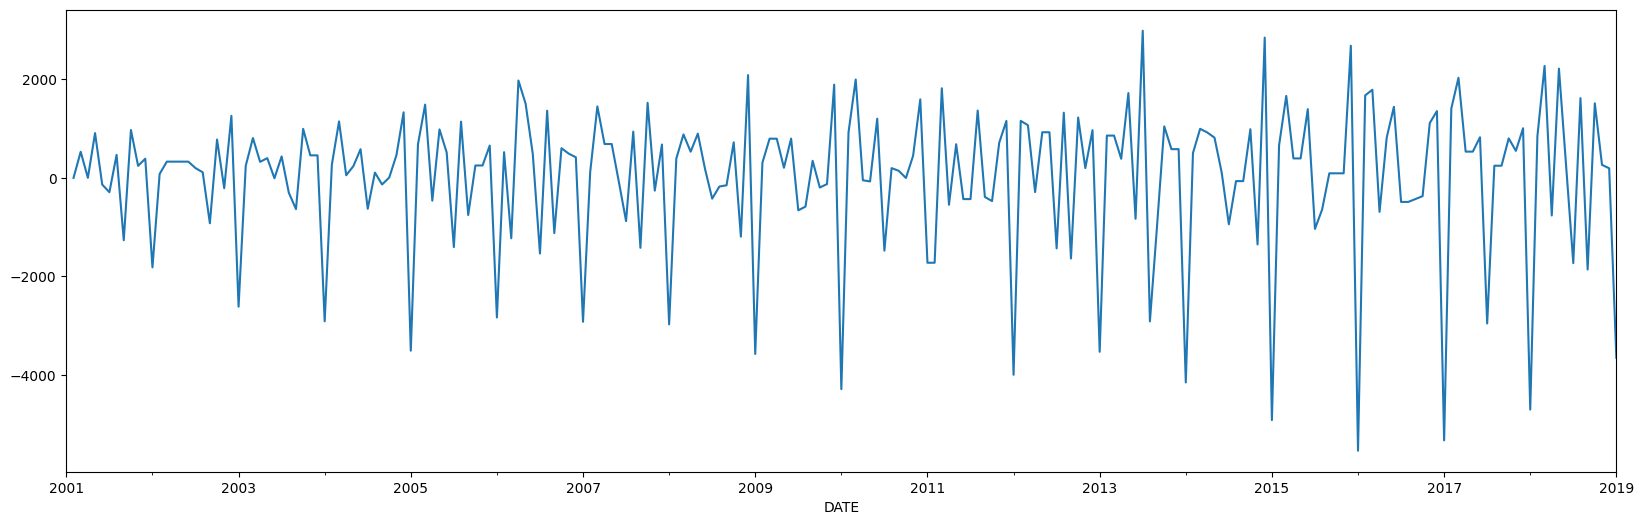

In [ ]:
detrend = mobile_sales.Sales.diff()
detrend.plot()

In [ ]:
adf_test(detrend.dropna())

Sequence is stationary


<Axes: xlabel='DATE'>

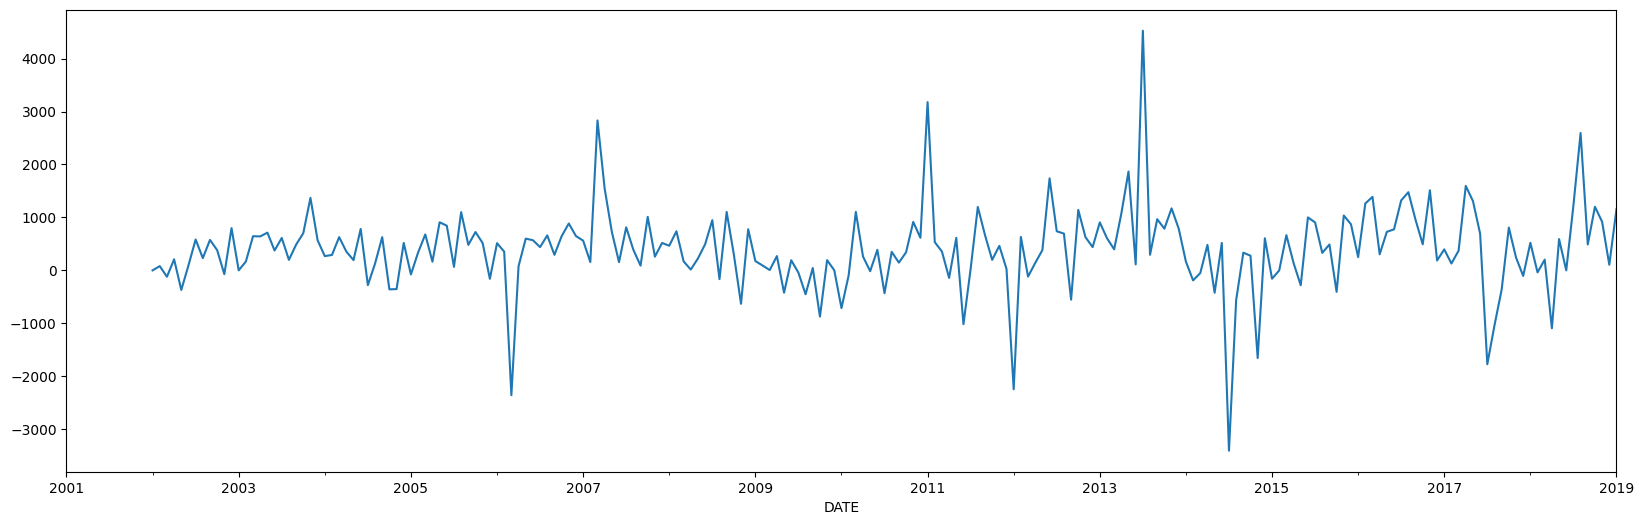

In [ ]:
deseas = mobile_sales.Sales.diff(12)
deseas.plot()

<Axes: xlabel='DATE'>

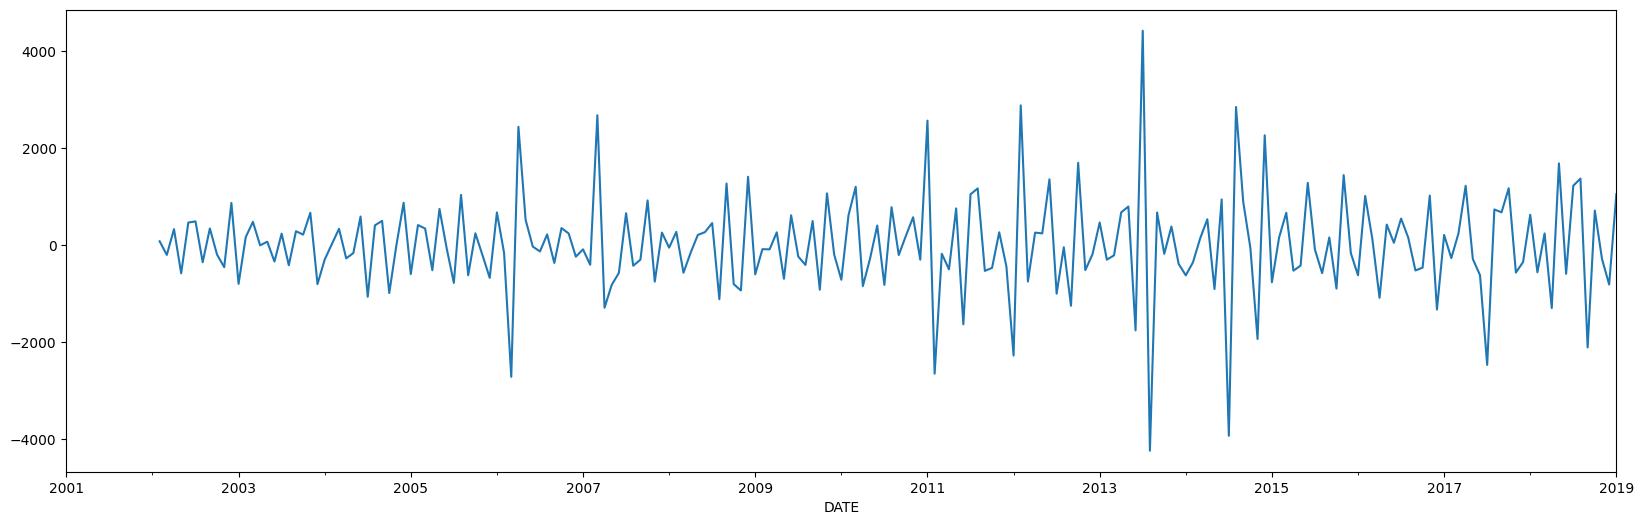

In [ ]:
stationary = mobile_sales.Sales.diff().diff(12)
stationary.plot()

In [ ]:
mobile_sales.Sales.head()

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00


In [ ]:
mobile_sales.Sales.shift(1).head()

,Sales
DATE,
2001-01-01,NaN
2001-02-01,6802.44
2001-03-01,6802.44
2001-04-01,7332.00
2001-05-01,7332.00


In [ ]:
lag = 1
np.corrcoef(mobile_sales.Sales[lag:], mobile_sales.Sales.shift(lag)[lag:])[0][1]

np.float64(0.8002851477229684)

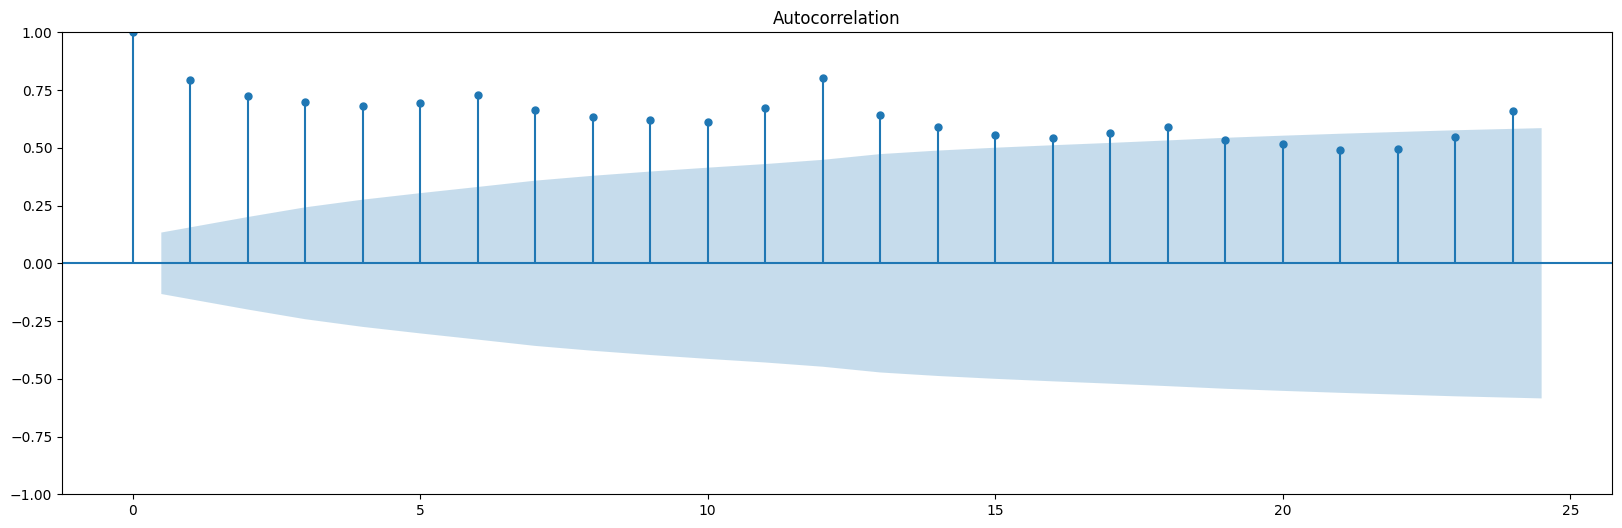

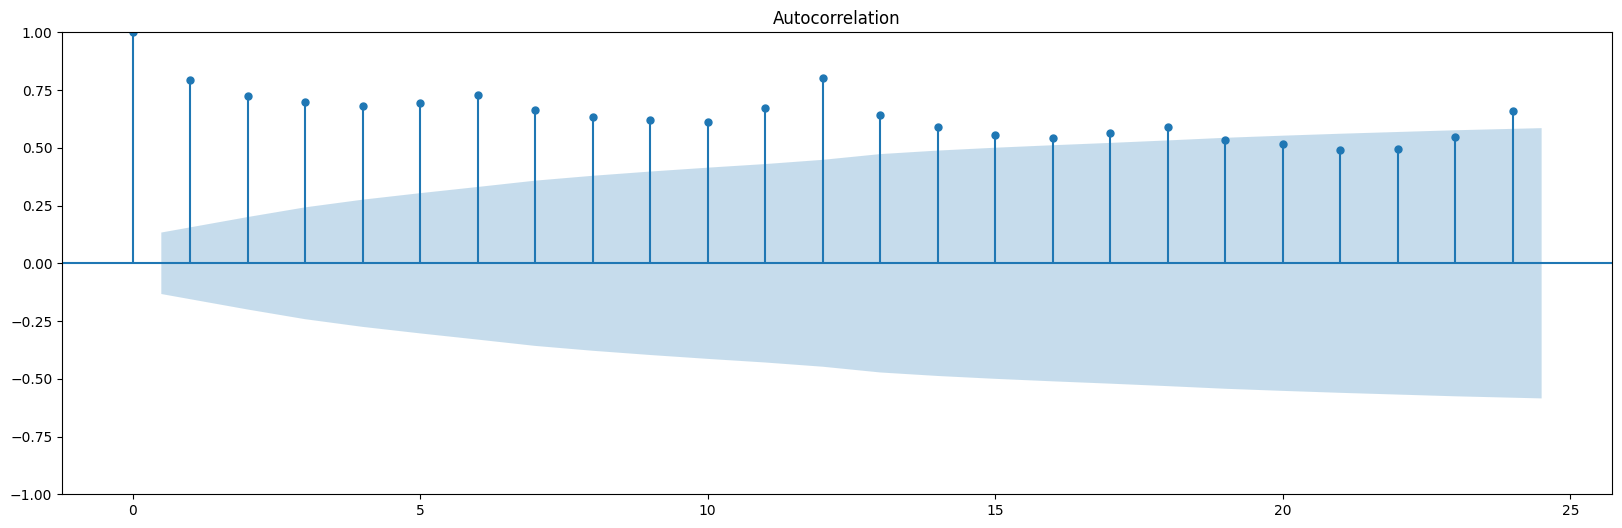

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(mobile_sales.Sales)

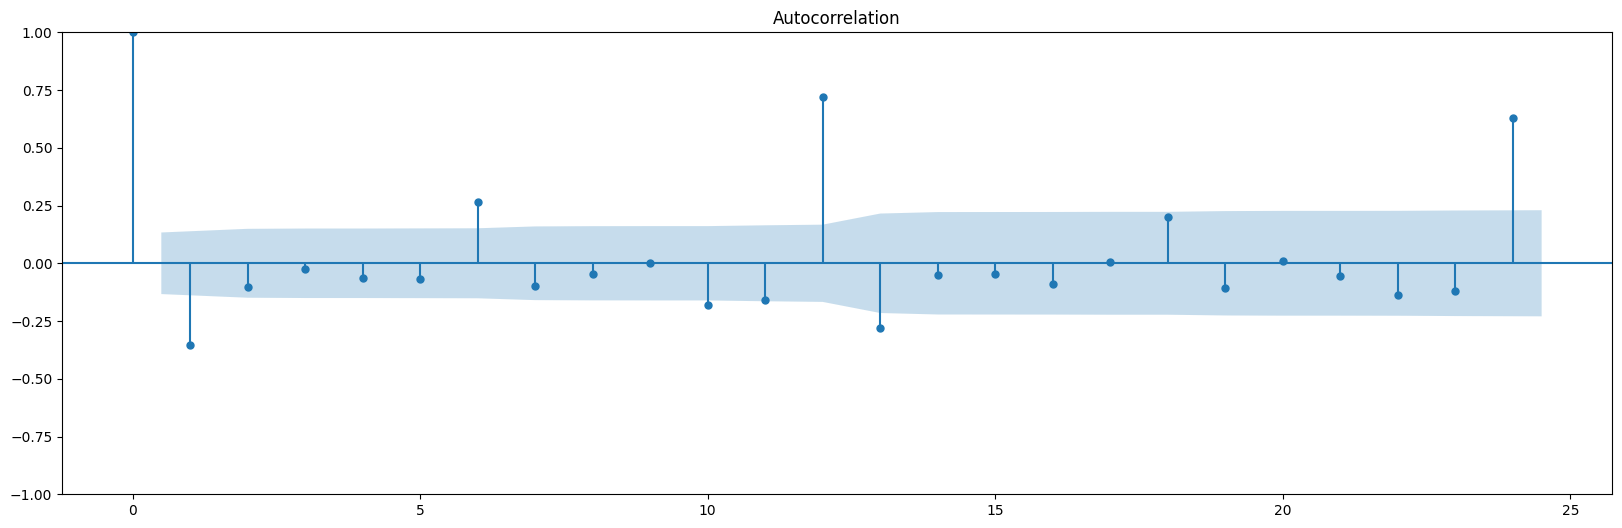

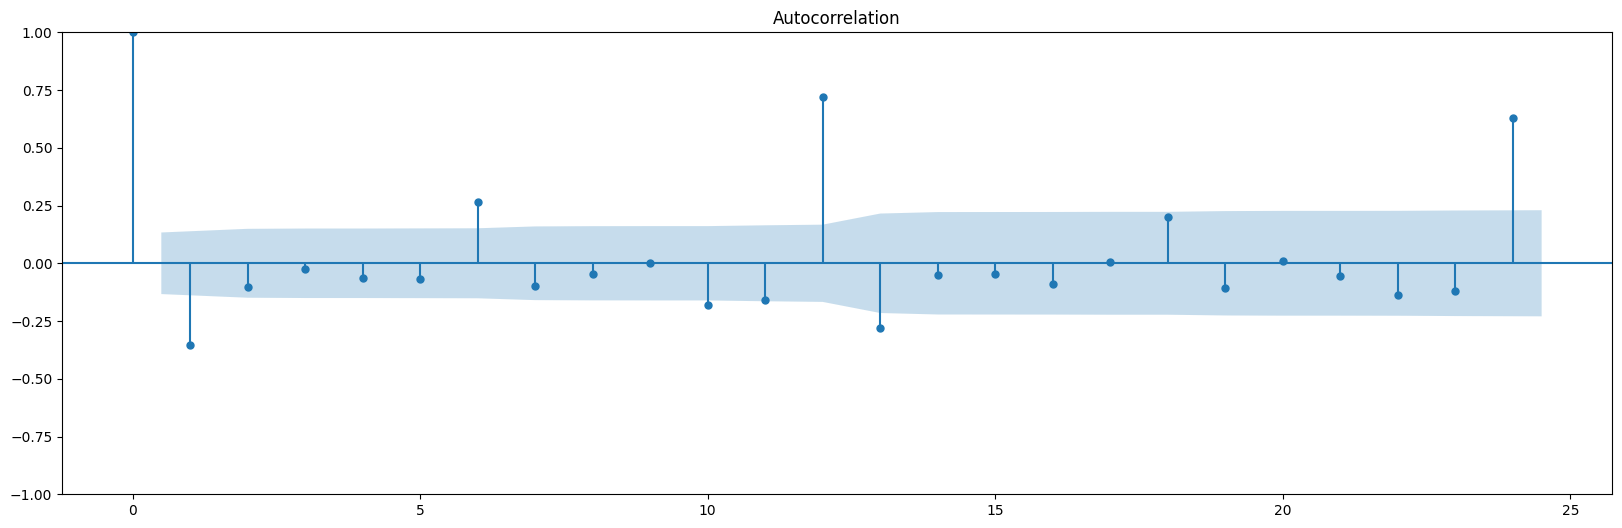

In [ ]:
plot_acf(mobile_sales.Sales.diff().dropna())

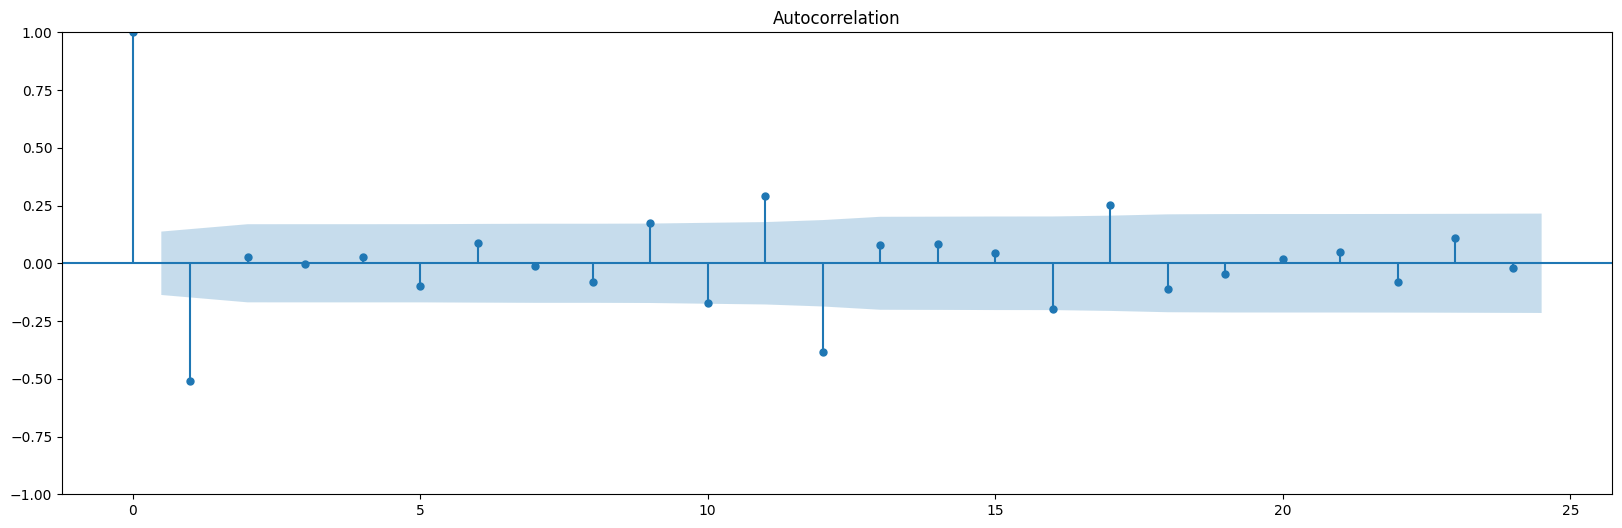

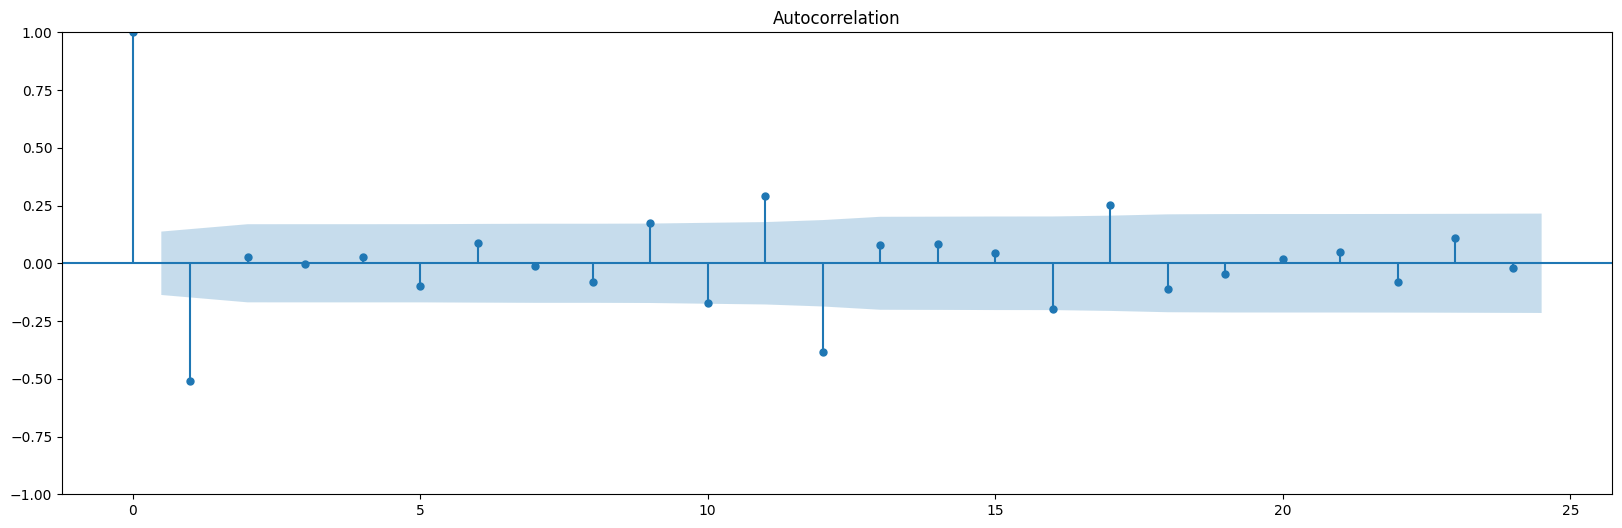

In [ ]:
plot_acf(mobile_sales.Sales.diff().diff(12).dropna())

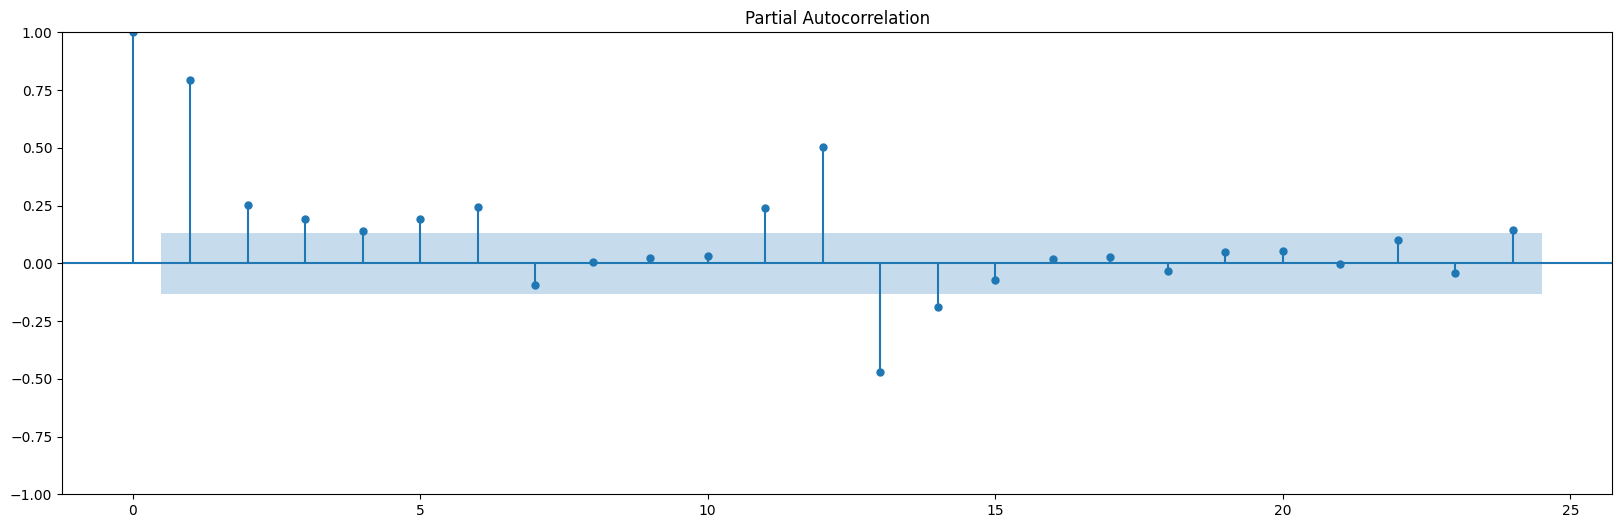

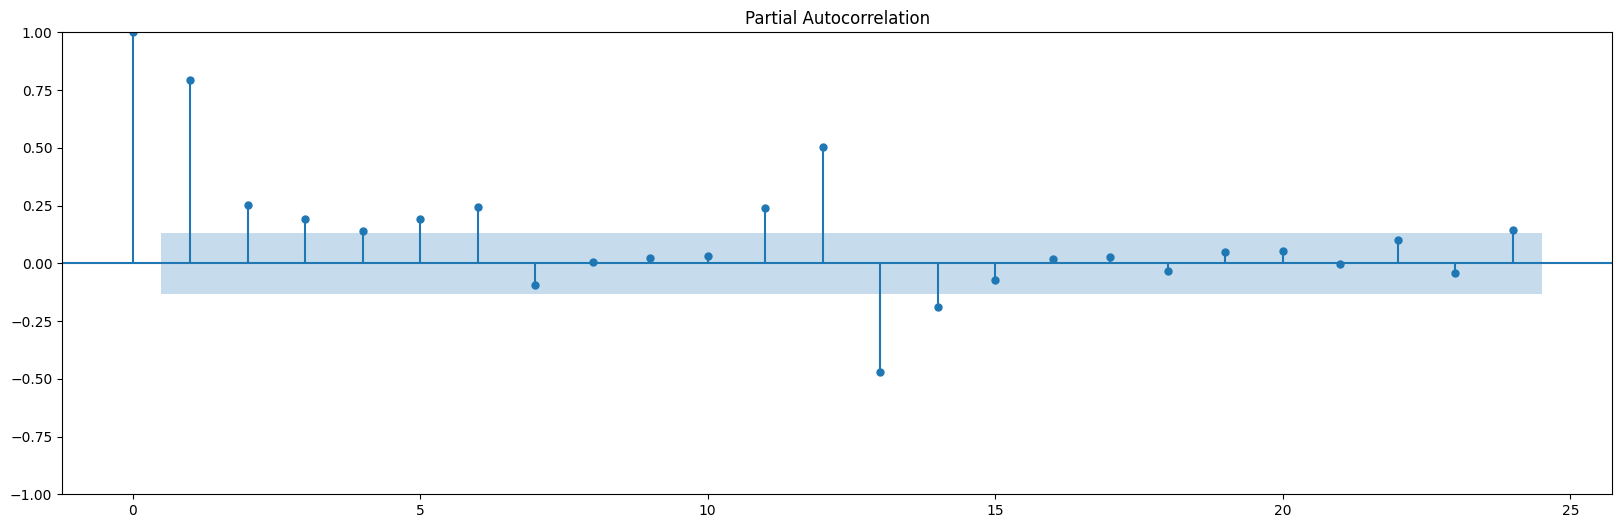

In [ ]:
plot_pacf(mobile_sales.Sales)

In [ ]:
adf_test(train_df.Sales)

Sequence is not stationary


In [ ]:
train_df_st = train_df.copy()
train_df_st.Sales = train_df_st.Sales.diff(1)
train_df_st.dropna(inplace = True)
adf_test(train_df_st.Sales)

Sequence is stationary


In [ ]:
import statsmodels as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model = SARIMAX(train_df_st.Sales, order = (1, 0, 0))
model = model.fit(disp = True)
test_df['pred'] = model.forecast(steps = 12)
test_df['pred'].head(20)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_37430/4132765488.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred'] = model.forecast(steps = 12)


,pred
DATE,
2018-02-01,1728.700558
2018-03-01,-635.966295
2018-04-01,233.963671
2018-05-01,-86.072170
2018-06-01,31.664824
2018-07-01,-11.649074
2018-08-01,4.285542
2018-09-01,-1.576595
2018-10-01,0.580009


In [ ]:
test_df['pred'] = test_df['pred'].cumsum() + test_df.Sales[-1]

/tmp/ipykernel_37430/1539289975.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_df['pred'] = test_df['pred'].cumsum() + test_df.Sales[-1]
/tmp/ipykernel_37430/1539289975.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred'] = test_df['pred'].cumsum() + test_df.Sales[-1]


MAE: 1558.33
MSE: 3073083.5
MAPE: 0.11


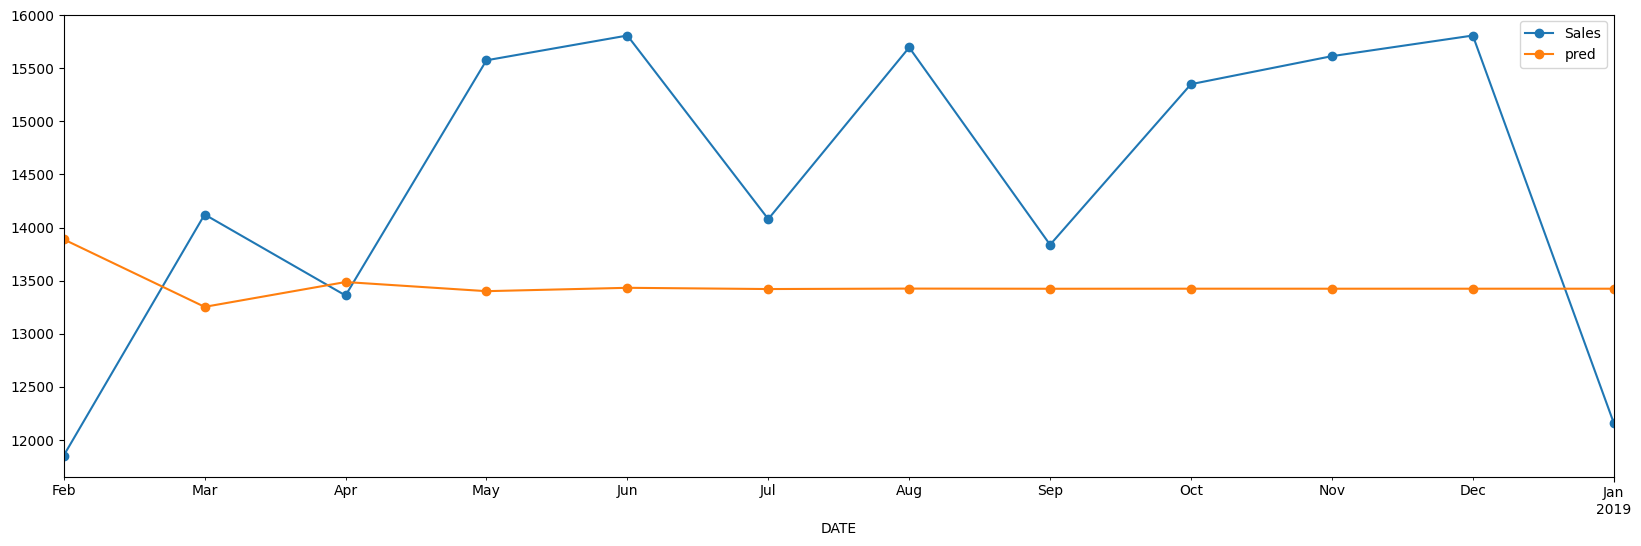

In [ ]:
test_df.plot(style = '-o')
performance(test_df['Sales'], test_df['pred'])

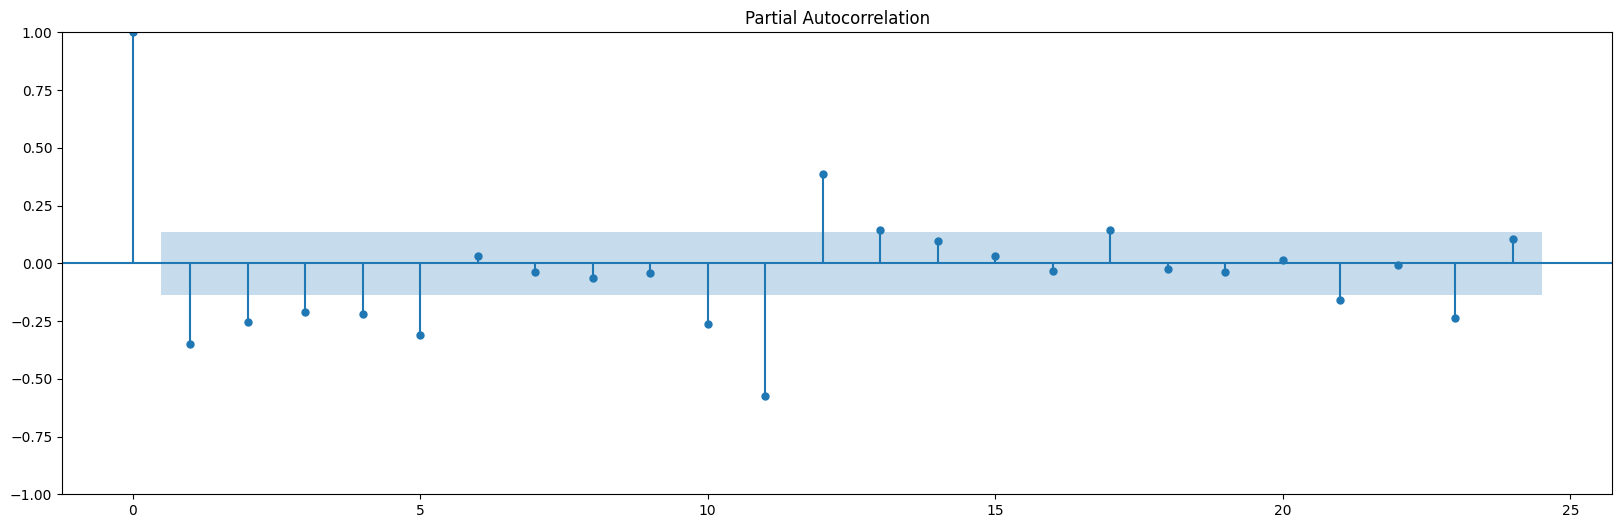

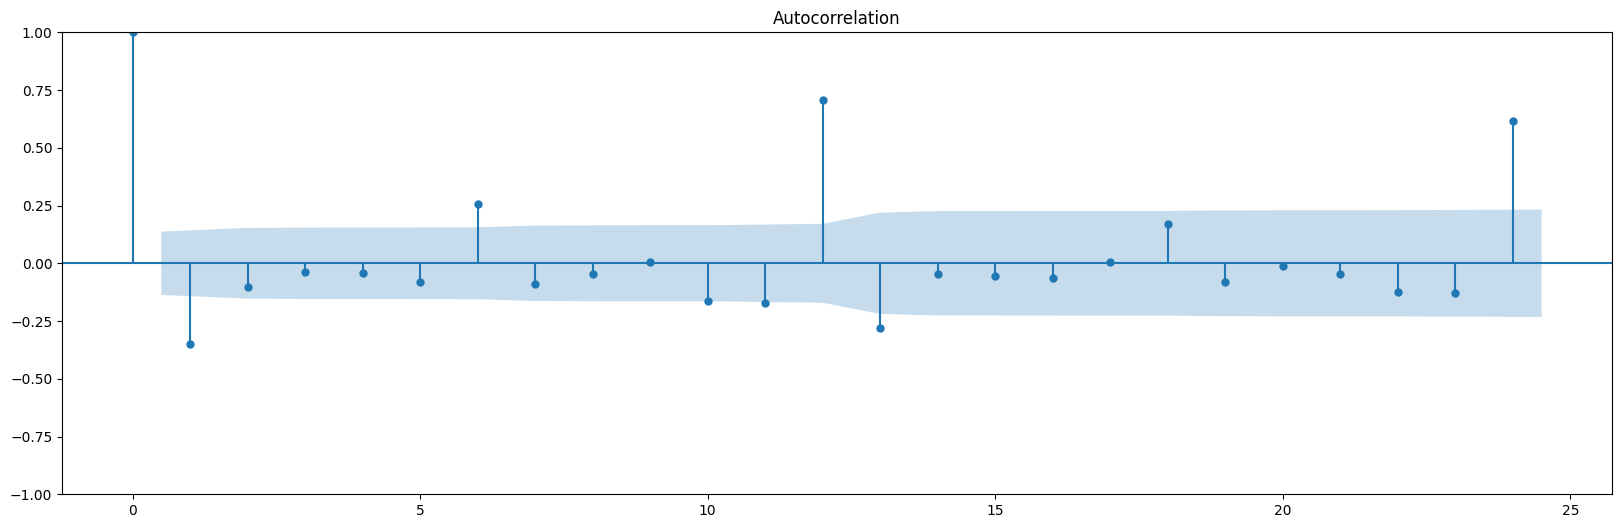

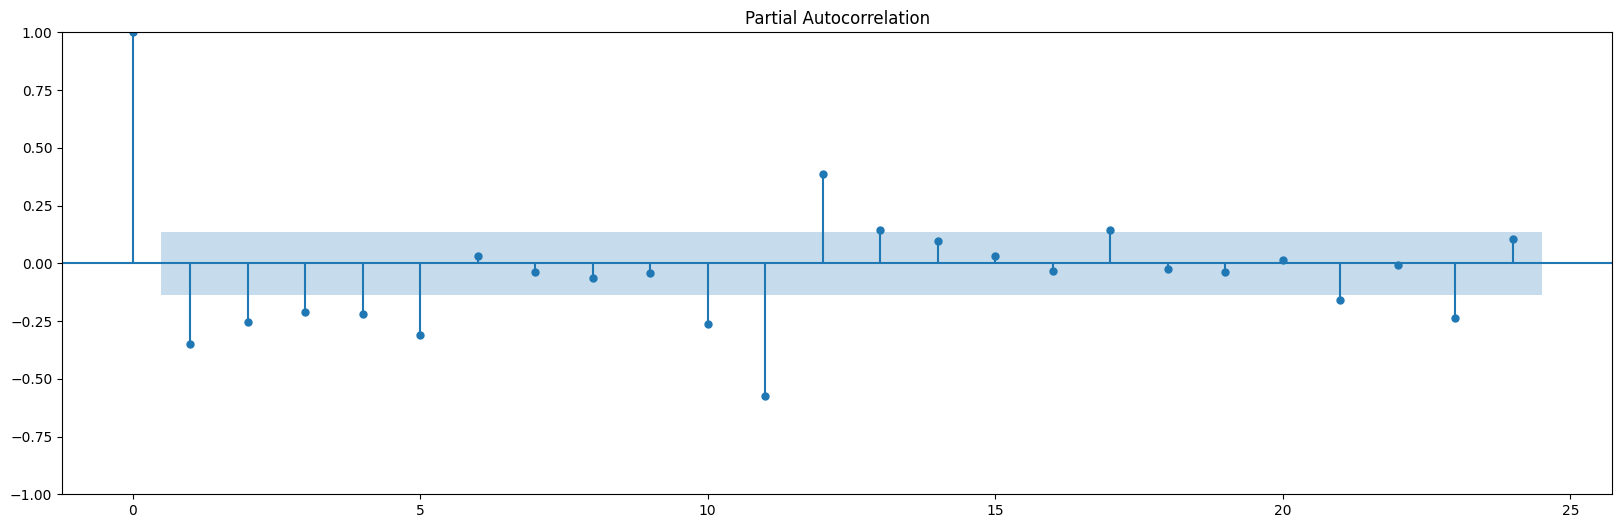

In [ ]:
plot_acf(train_df_st.Sales)
plot_pacf(train_df_st.Sales)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_37430/3760575142.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred'] = model.forecast(steps = 12)
/tmp/ipykernel_37430/3760575142.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To

MAE: 1647.06
MSE: 3572111.37
MAPE: 0.11


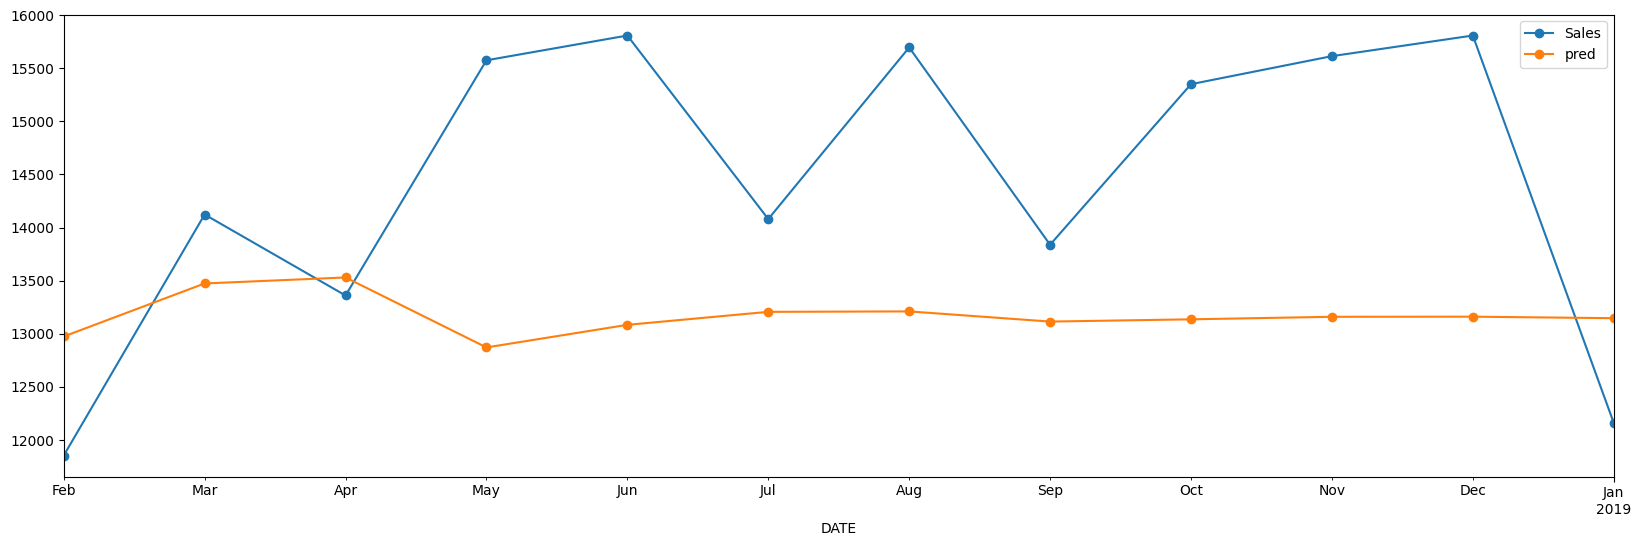

In [ ]:
model = SARIMAX(train_df_st.Sales, order = (3, 0, 0))
model = model.fit(disp = False)
test_df['pred'] = model.forecast(steps = 12)

test_df['pred'] = test_df['pred'].cumsum() + train_df.Sales[-1]

test_df.plot(style = '-o')
performance(test_df['Sales'], test_df['pred'])

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: display. After release 0.14, this will raise.
  warnings.warn(
/tmp/ipykernel_37430/2677941291.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

MAE: 1362.95
MSE: 2427411.95
MAPE: 0.09


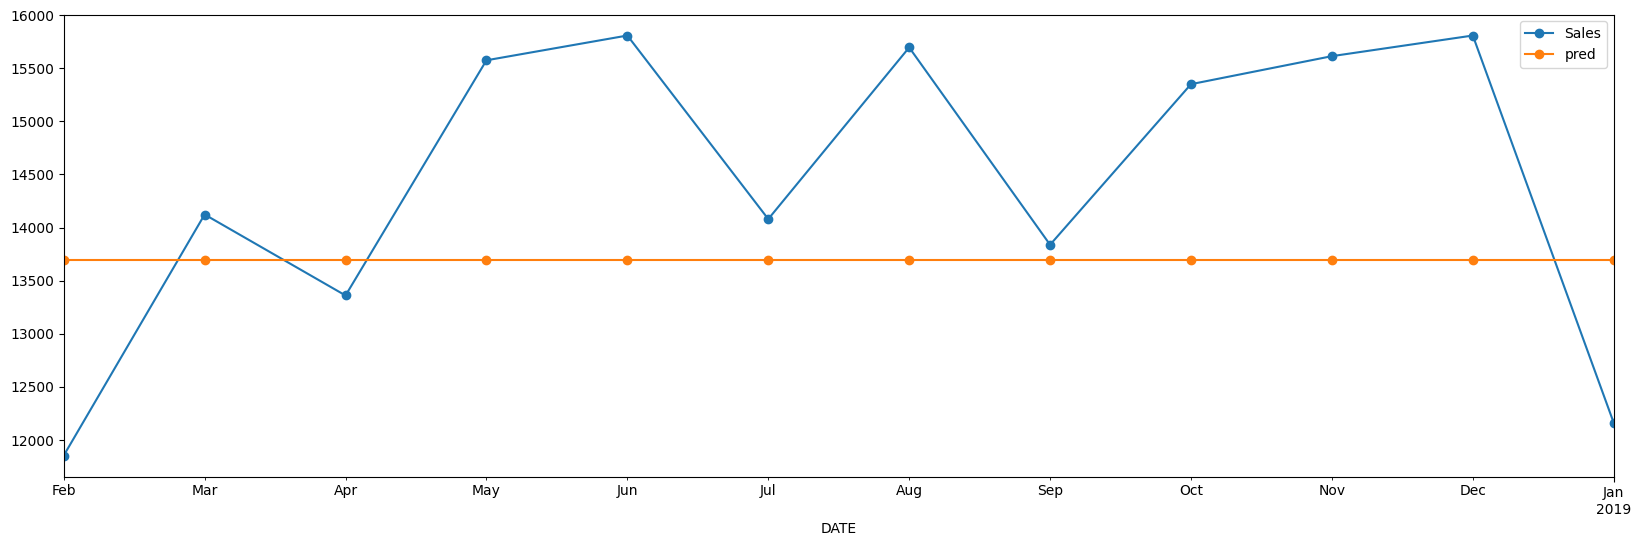

In [ ]:
model = SARIMAX(train_df_st.Sales, order = (0, 0, 1))
model = model.fit(display = False)
test_df['pred'] = model.forecast(steps = 12)

test_df['pred'] = test_df['pred'].cumsum() + train_df.Sales[-1]

test_df.plot(style = '-o')
performance(test_df['Sales'], test_df['pred'])

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: display. After release 0.14, this will raise.
  warnings.warn(
/tmp/ipykernel_37430/547135150.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

MAE: 1359.18
MSE: 2421036.15
MAPE: 0.09


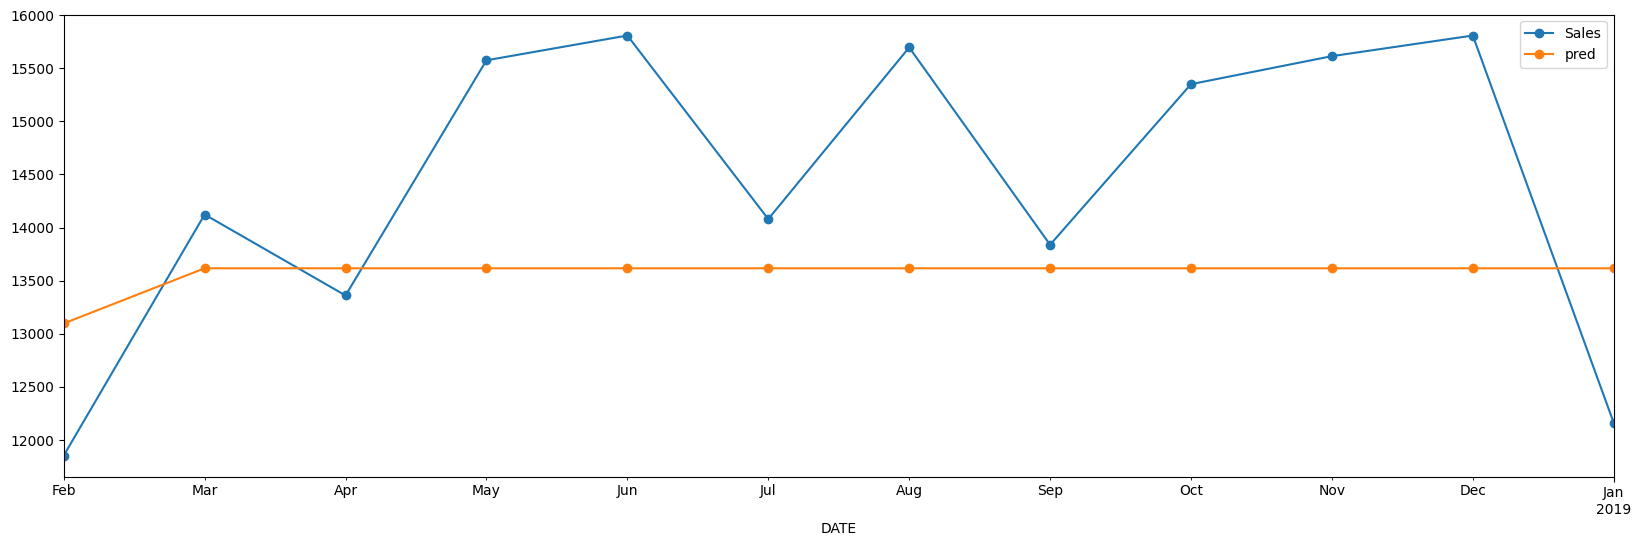

In [ ]:
model = SARIMAX(train_df_st.Sales, order = (0, 0, 2))
model = model.fit(display = False)
test_df['pred'] = model.forecast(steps = 12)

test_df['pred'] = test_df['pred'].cumsum() + train_df.Sales[-1]

test_df.plot(style = '-o')
performance(test_df['Sales'], test_df['pred'])

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.13/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: di

MAE: 1294.29
MSE: 2181558.11
MAPE: 0.09


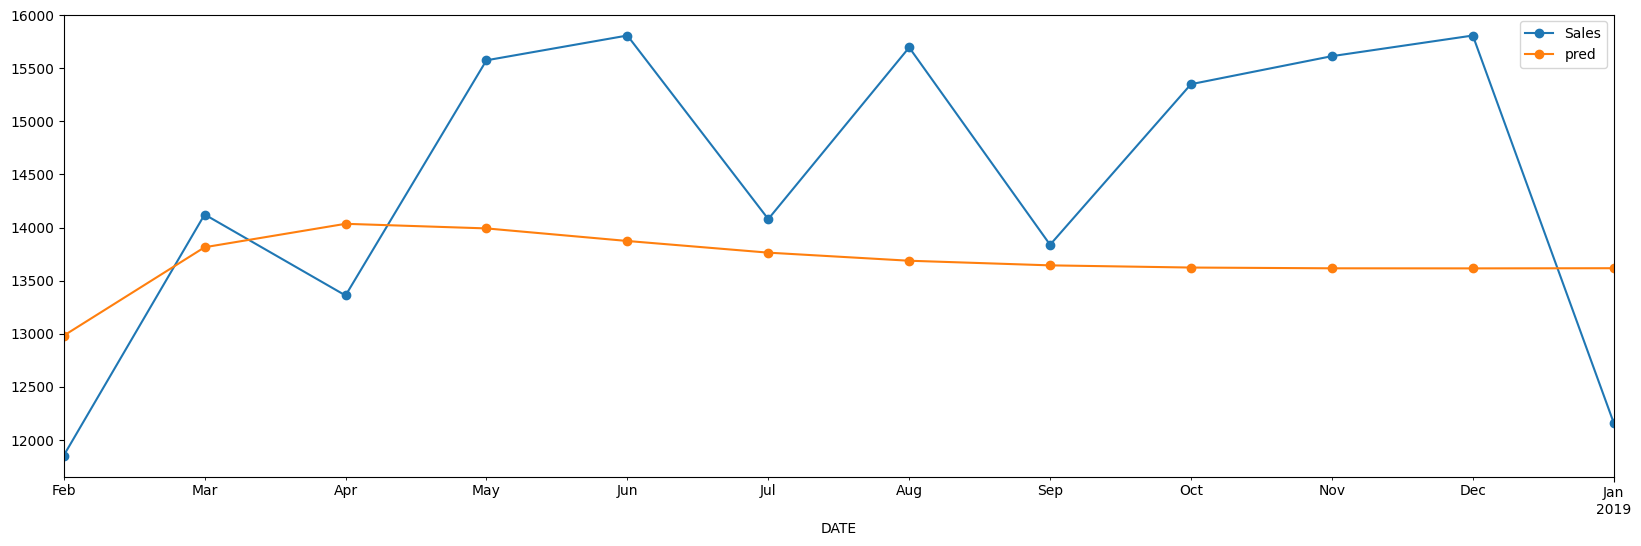

In [ ]:
model = SARIMAX(train_df_st.Sales, order = (2, 0, 2))
model = model.fit(display = False)
test_df['pred'] = model.forecast(steps = 12)

test_df['pred'] = test_df['pred'].cumsum() + train_df.Sales[-1]

test_df.plot(style = '-o')
performance(test_df['Sales'], test_df['pred'])

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: display. After release 0.14, this will raise.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

MAE: 1307.14
MSE: 2337484.46
MAPE: 0.09


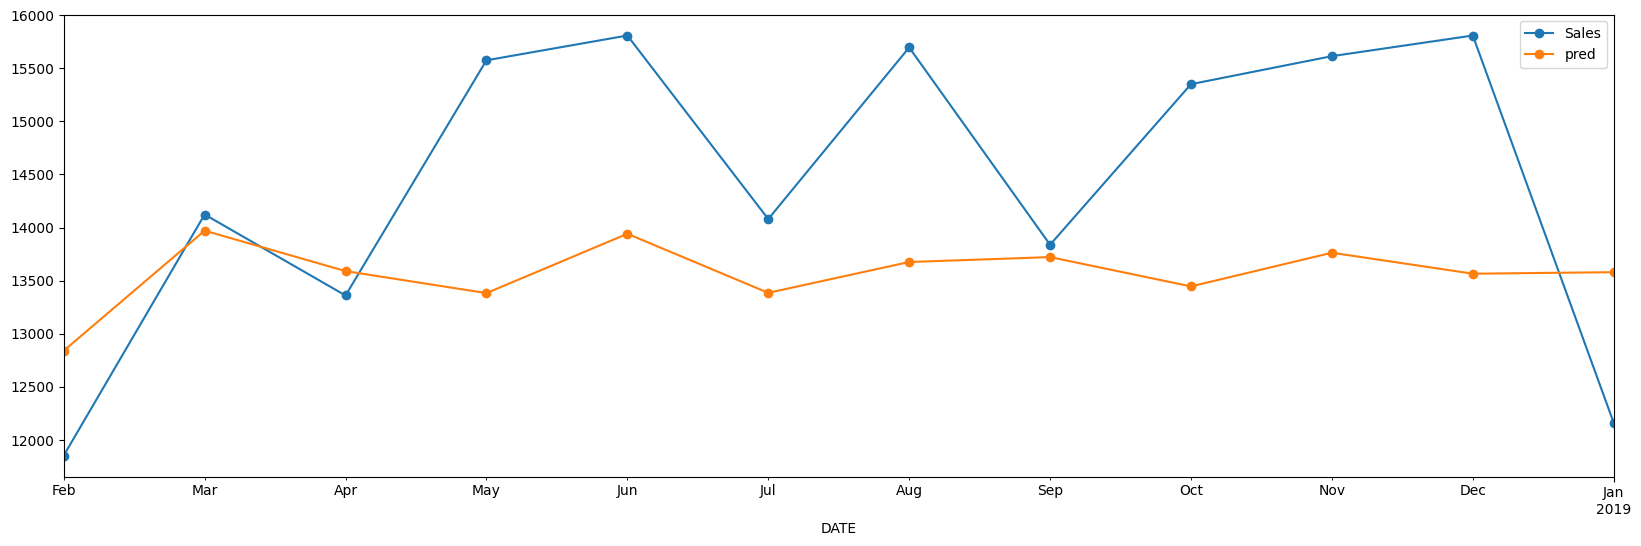

In [ ]:
model = SARIMAX(train_df.Sales, order = (3, 1, 3))
model = model.fit(display = False)
test_df['pred'] = model.forecast(steps = 12)
test_df.plot(style = '-o')
performance(test_df['Sales'], test_df['pred'])

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.13/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: di

MAE: 1918.52
MSE: 4682134.21
MAPE: 0.13


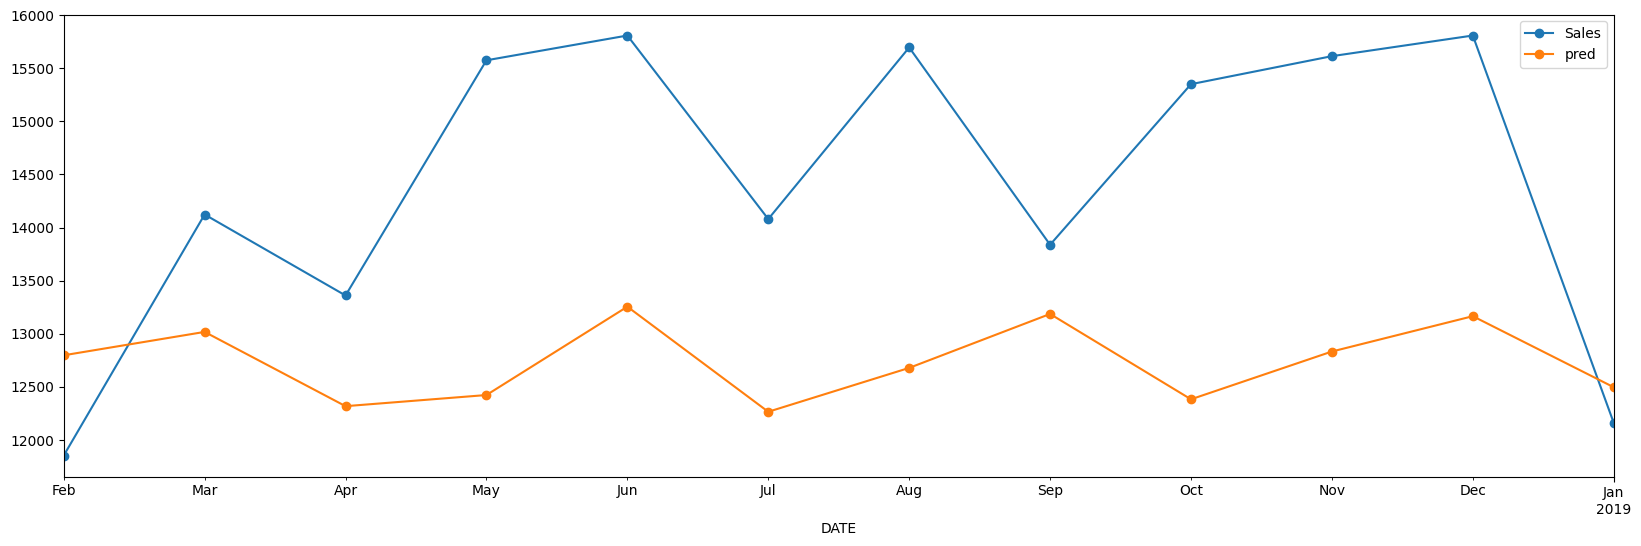

In [ ]:
model = SARIMAX(train_df.Sales, order = (3, 2, 3))
model = model.fit(display = False)
test_df['pred'] = model.forecast(steps = 12)
test_df.plot(style = '-o')
performance(test_df['Sales'], test_df['pred'])

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.13/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: di

MAE: 622.32
MSE: 514512.3
MAPE: 0.04


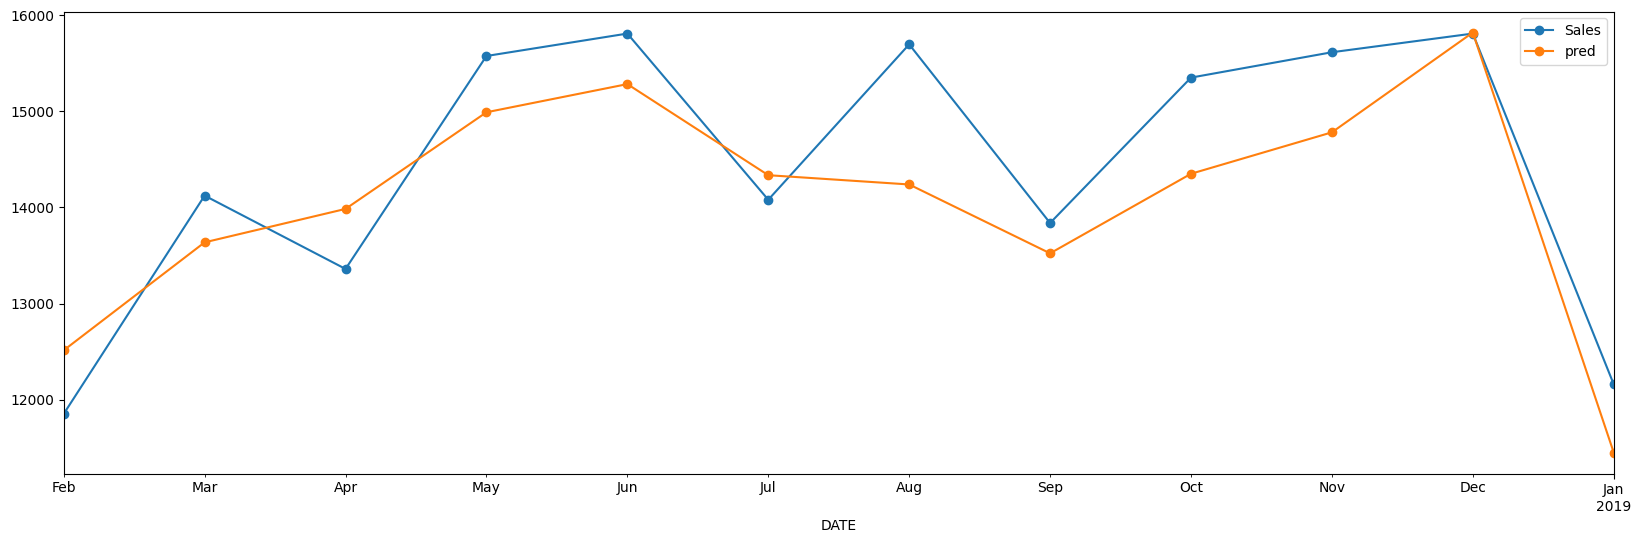

In [ ]:
model = SARIMAX(train_df.Sales, order = (3, 2, 3), seasonal_order = (1, 1, 1, 12))
model = model.fit(display = False)
test_df['pred'] = model.forecast(steps = 12)
test_df.plot(style = '-o')
performance(test_df['Sales'], test_df['pred'])

In [ ]:
plt.rcParams['figure.figsize'] = (20,8)

In [ ]:
model = SARIMAX(train_df.Sales, order = (3, 2, 3), seasonal_order = (1, 1, 1, 12))
model = model.fit(display = False)
test_df[['lower', 'upper']] = model.get_forecast(12).conf_int(0.05).values
test_df.head()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.13/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: di

,Sales,pred,lower,upper
DATE,,,,
2018-02-01,11852.0,12513.416584,10774.074587,14252.758581
2018-03-01,14123.0,13636.804754,11647.017000,15626.592508
2018-04-01,13360.0,13984.683397,11634.034308,16335.332487
2018-05-01,15576.0,14990.440253,12341.089178,17639.791329
2018-06-01,15809.4,15283.544255,12368.330468,18198.758042


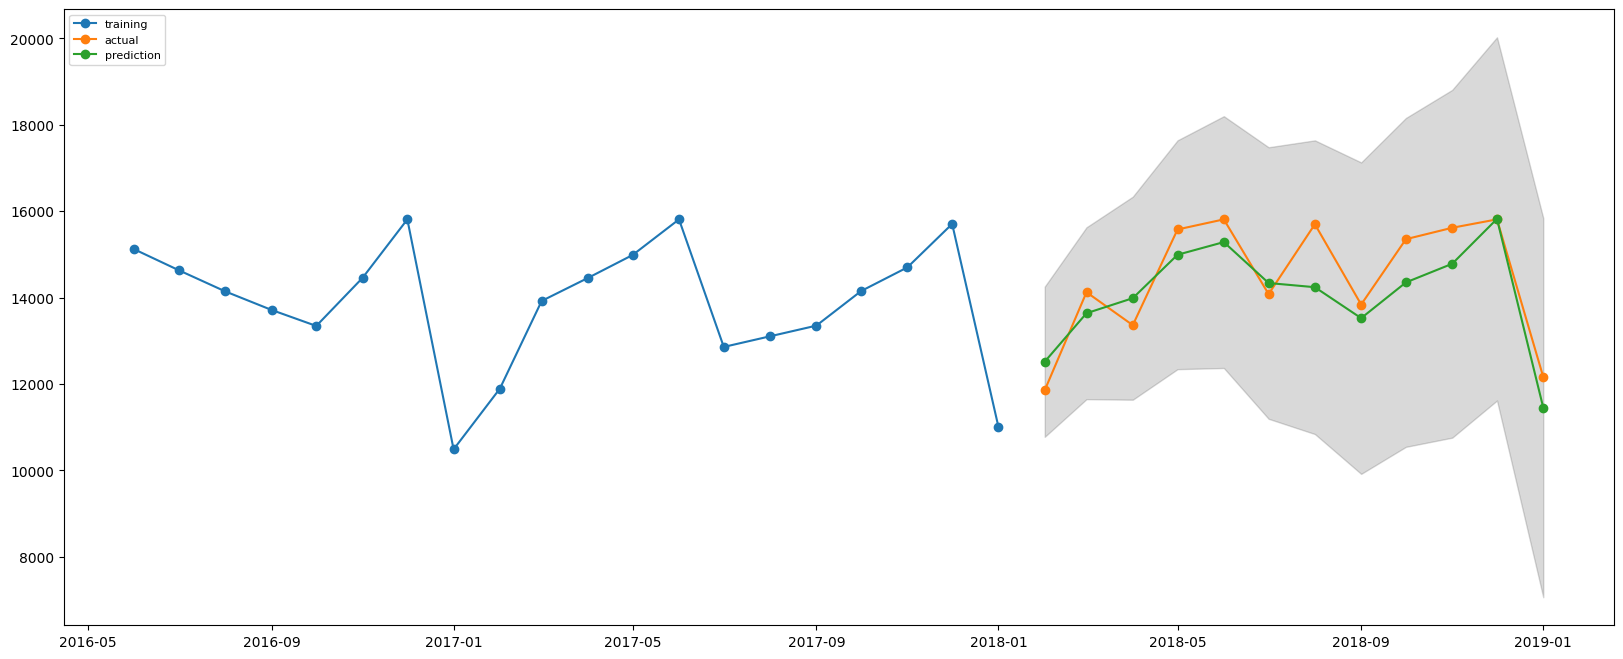

In [ ]:
plt.plot(train_df['Sales'][-20:], '-o', label='training')


plt.plot(test_df['Sales'], '-o', label='actual')
plt.plot(test_df['pred'], '-o', label='prediction')

plt.fill_between(test_df.index, test_df['lower'], test_df['upper'],
                 color='k', alpha=.15)

plt.legend(loc='upper left', fontsize=8)
plt.show()

In [ ]:
from IPython.display import Image
Image(url='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/007/752/original/illustration_of_change_point_detectopn_via_sliding-window.gif?1658421673')

In [ ]:
#Restaurant Visits

!gdown 16TAoRZ3S8ebgIq3dPQmWIXPw_1dZy3ta

Downloading...
From: https://drive.google.com/uc?id=16TAoRZ3S8ebgIq3dPQmWIXPw_1dZy3ta
To: /content/rest_vis.csv
100% 13.1k/13.1k [00:00<00:00, 22.5MB/s]


In [ ]:
df = pd.read_csv('/content/rest_vis.csv')
df.head()

,date,weekday,holiday,total
0,1/1/2016,Friday,1,296.0
1,1/2/2016,Saturday,0,191.0
2,1/3/2016,Sunday,0,202.0
3,1/4/2016,Monday,0,105.0
4,1/5/2016,Tuesday,0,98.0


In [ ]:
df['holiday'].value_counts()

,count
holiday,
0,482
1,35


In [ ]:
pd.set_option('display.max_rows',None)
df

,date,weekday,holiday,total
0,1/1/2016,Friday,1,296.0
1,1/2/2016,Saturday,0,191.0
2,1/3/2016,Sunday,0,202.0
3,1/4/2016,Monday,0,105.0
4,1/5/2016,Tuesday,0,98.0
5,1/6/2016,Wednesday,0,83.0
6,1/7/2016,Thursday,0,69.0
7,1/8/2016,Friday,0,149.0
8,1/9/2016,Saturday,0,234.0
9,1/10/2016,Sunday,0,212.0


In [ ]:
df.isna().sum()

,0
date,0
weekday,0
holiday,0
total,39


In [ ]:
df.shape

(517, 4)

In [ ]:
df.dropna(inplace = True)

In [ ]:
df.shape

(478, 4)

In [ ]:
df.dtypes

,0
date,object
weekday,object
holiday,int64
total,float64


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace = True)

df.head(5)

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0


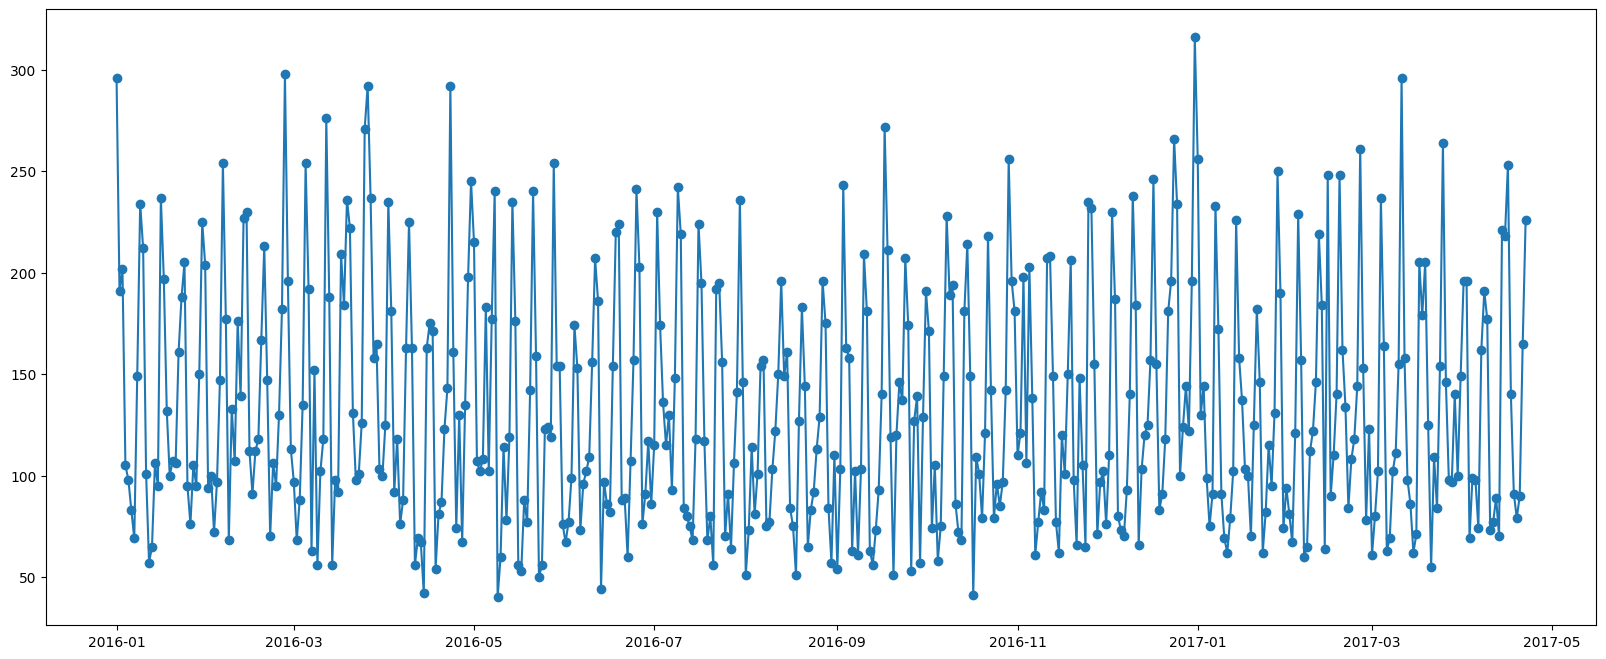

In [ ]:
plt.plot(df.index, df['total'], '-o')
plt.show()

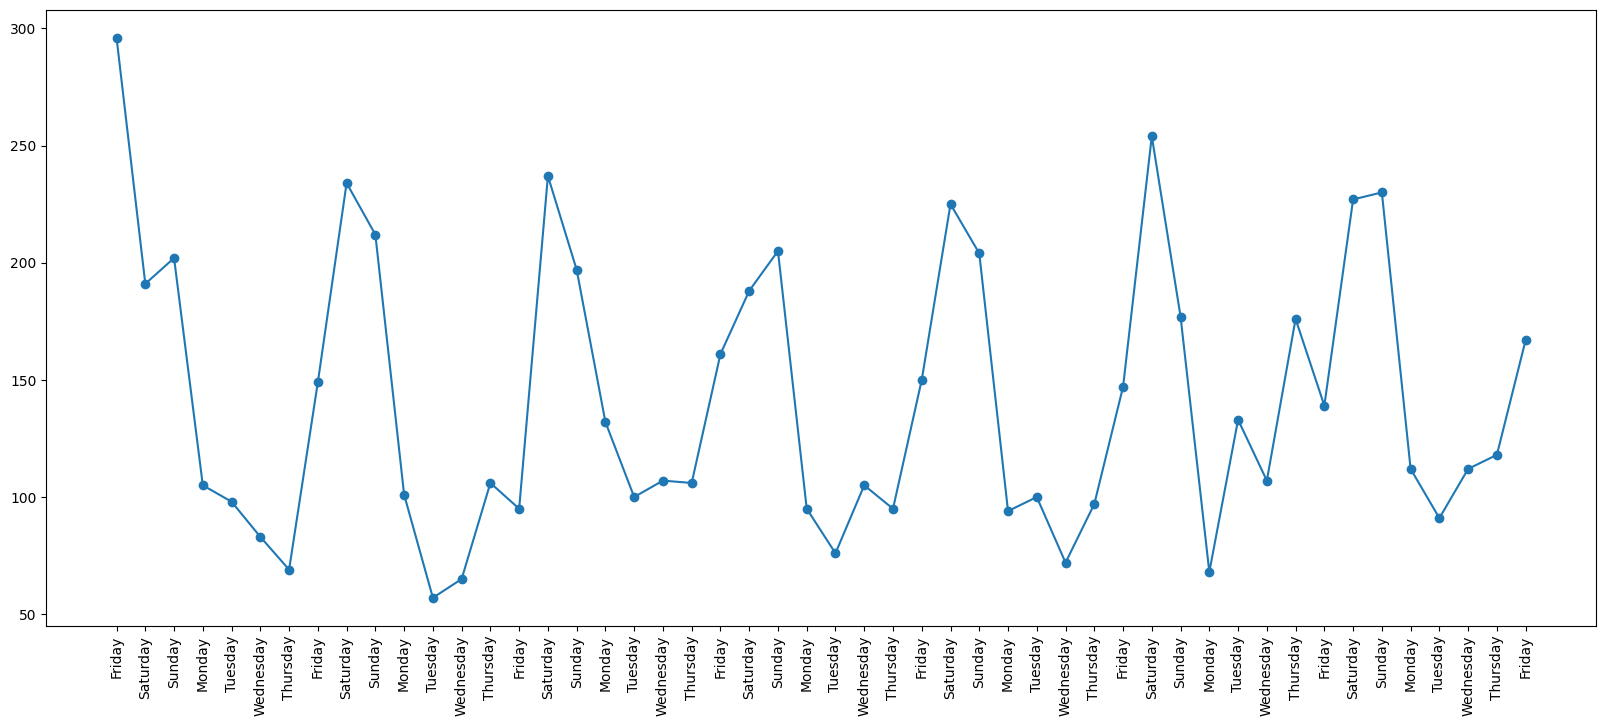

In [ ]:
plt.plot(range(50),df['total'][:50], '-o')
plt.xticks(range(0,50), df['weekday'][:50],rotation = 90)
plt.show()

/usr/local/lib/python3.13/dist-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


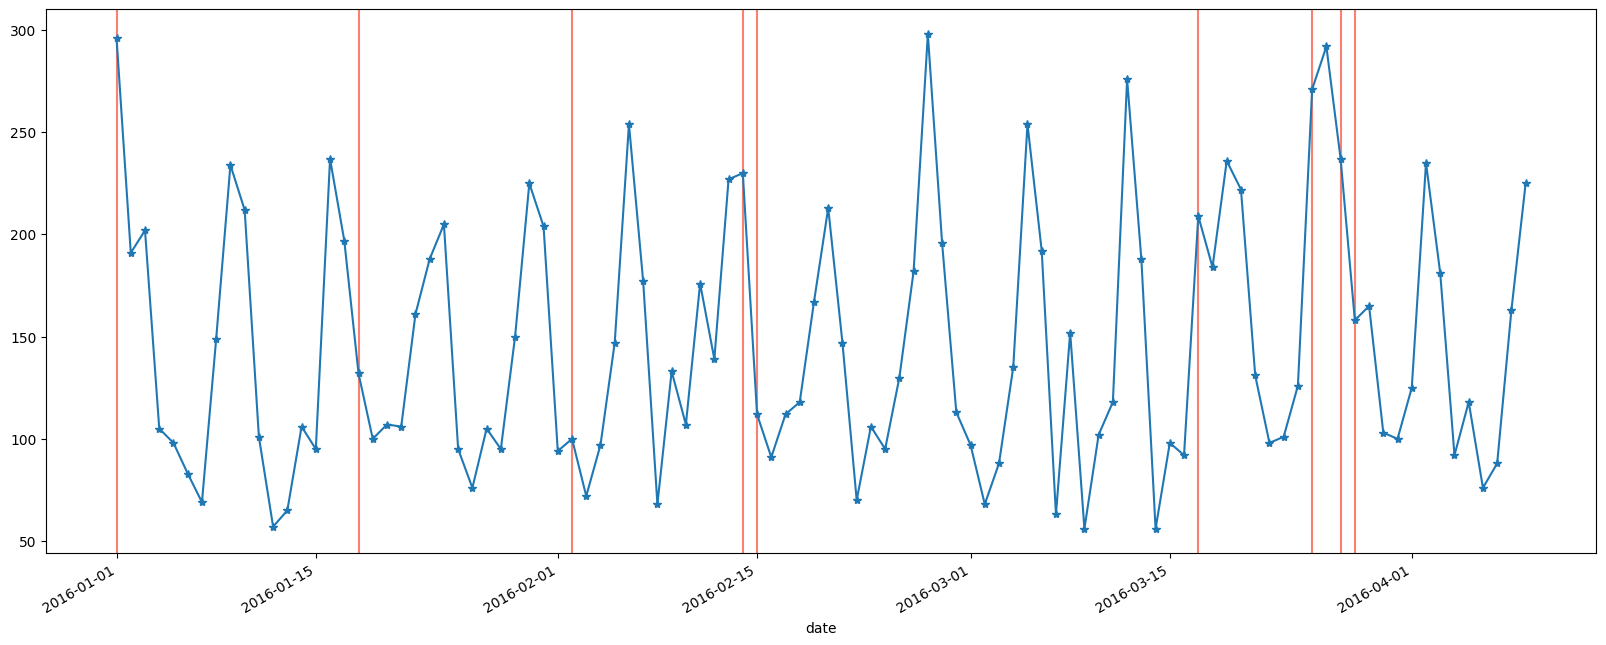

In [ ]:
holidays = df[:100].loc[df.holiday==1].index
for hday in holidays:
    plt.axvline(x=hday, color='#FA8072')

df.total[:100].plot(style='-*')

plt.show()

In [ ]:
train = df.iloc[:436]
test = df.iloc[436:]

In [ ]:
train.head()

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0


In [ ]:
model = SARIMAX(train.total, order=(1,0,1), seasonal_order=(1,0,1,7))
results = model.fit(display = False)
predictions = results.forecast(42)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: display. After release 0.14, this will raise.
  warnings.warn(


MAE: 24.67
MSE: 999.17
MAPE: 0.2


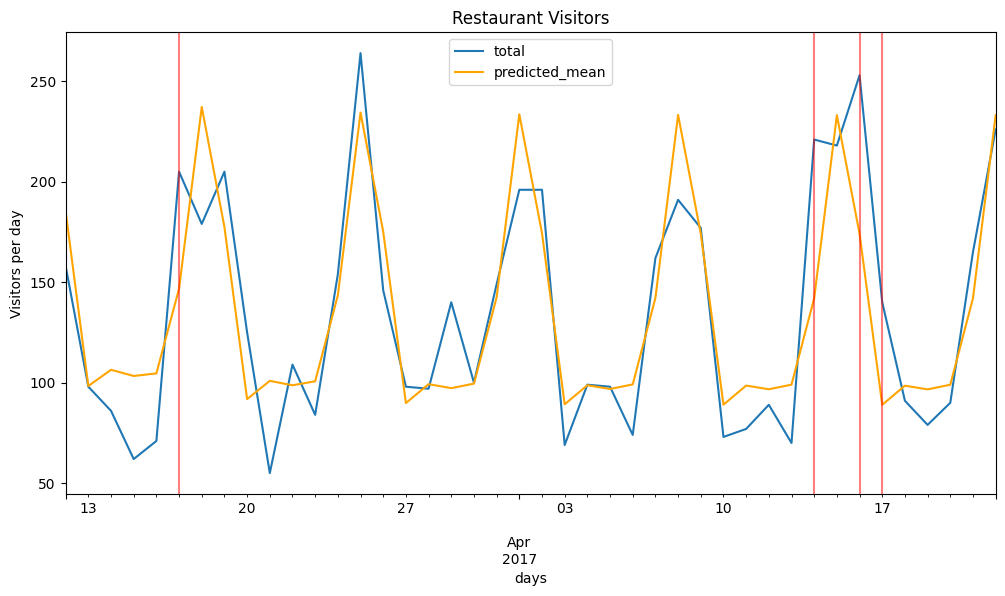

In [ ]:
performance(test['total'], predictions)

# Plot predictions against known values

title='Restaurant Visitors'
ylabel='Visitors per day'
xlabel='days'
ax = test['total'].plot(legend=True,figsize=(12,6),title=title)
predictions.plot(legend=True,color = 'orange')


ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for x in test.query('holiday==1').index:
    ax.axvline(x=x, color='red', alpha = 0.5)

In [ ]:
#With EXOG
model=SARIMAX(train.total,exog=train[['holiday']],order=(1,0,1),seasonal_order=(1,0,1,7))
results = model.fit(disp=False)
predictions = results.forecast(42,exog=test[['holiday']])

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 18.45
MSE: 526.85
MAPE: 0.16


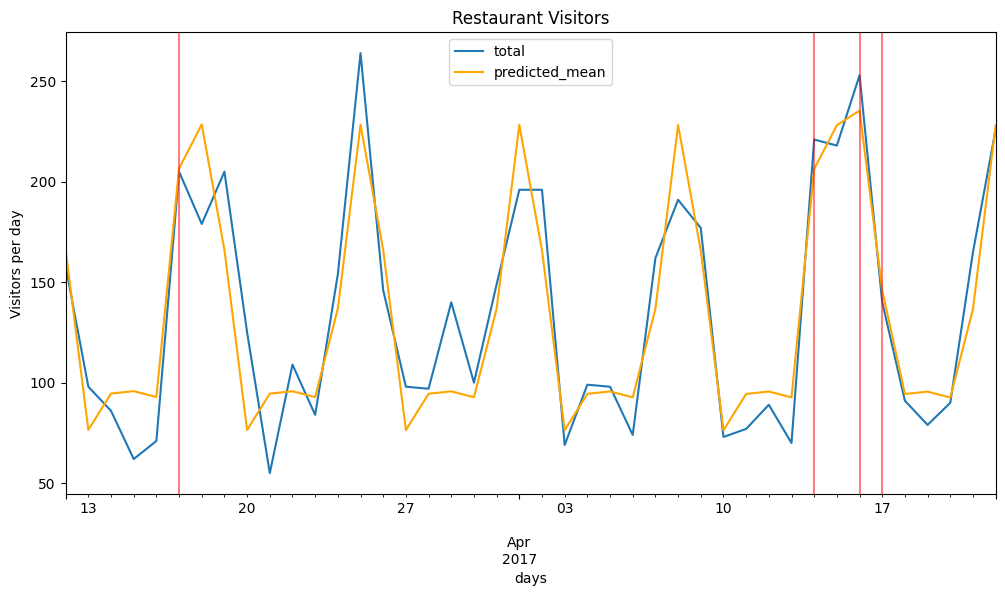

In [ ]:
performance(test['total'], predictions)

# Plot predictions against known values

title='Restaurant Visitors'
ylabel='Visitors per day'
xlabel='days'
ax = test['total'].plot(legend=True,figsize=(12,6),title=title)
predictions.plot(legend=True,color = 'orange')


ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for x in test.query('holiday==1').index:
    ax.axvline(x=x, color='red', alpha = 0.5)

In [ ]:
train.head()

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0


In [ ]:
test.head()

,weekday,holiday,total
date,,,
2017-03-12,Sunday,0,158.0
2017-03-13,Monday,0,98.0
2017-03-14,Tuesday,0,86.0
2017-03-15,Wednesday,0,62.0
2017-03-16,Thursday,0,71.0


In [ ]:
model = SARIMAX(train.total, order=(1,0,1), seasonal_order=(1,0,1,7))
results = model.fit(display = False)
predictions = results.forecast(42)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: display. After release 0.14, this will raise.
  warnings.warn(


MAE: 24.67
MSE: 999.17
MAPE: 0.2


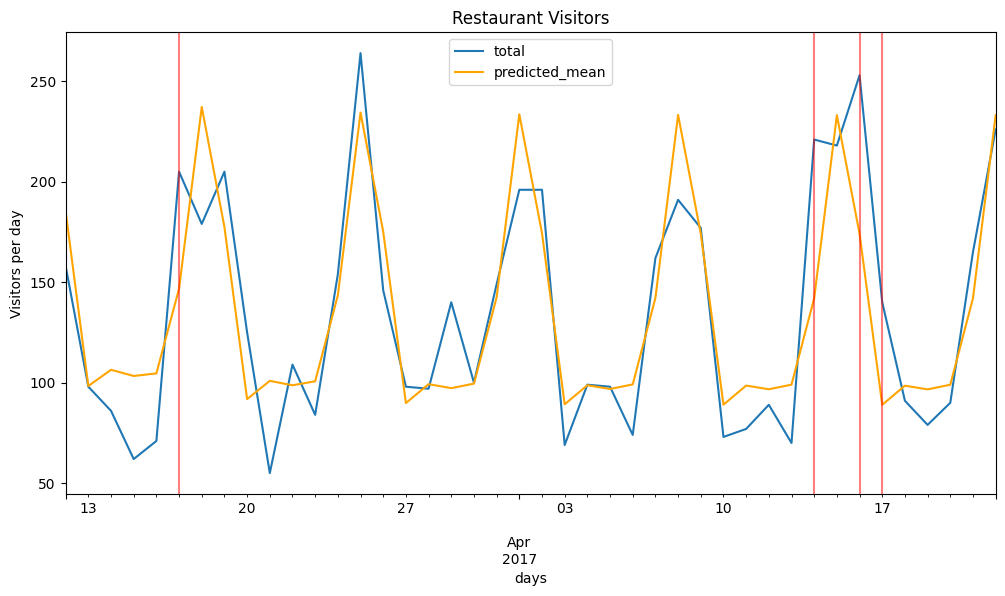

In [ ]:
performance(test['total'], predictions)

# Plot predictions against known values

title='Restaurant Visitors'
ylabel='Visitors per day'
xlabel='days'
ax = test['total'].plot(legend=True,figsize=(12,6),title=title)
predictions.plot(legend=True,color = 'orange')


ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for x in test.query('holiday==1').index:
    ax.axvline(x=x, color='red', alpha = 0.5)

/tmp/ipykernel_37430/3216802353.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[['lower', 'upper']] = results.get_forecast(steps = 42).conf_int(0.5).values
/tmp/ipykernel_37430/3216802353.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[['lower', 'upper']] = results.get_forecast(steps = 42).conf_int(0.5).values


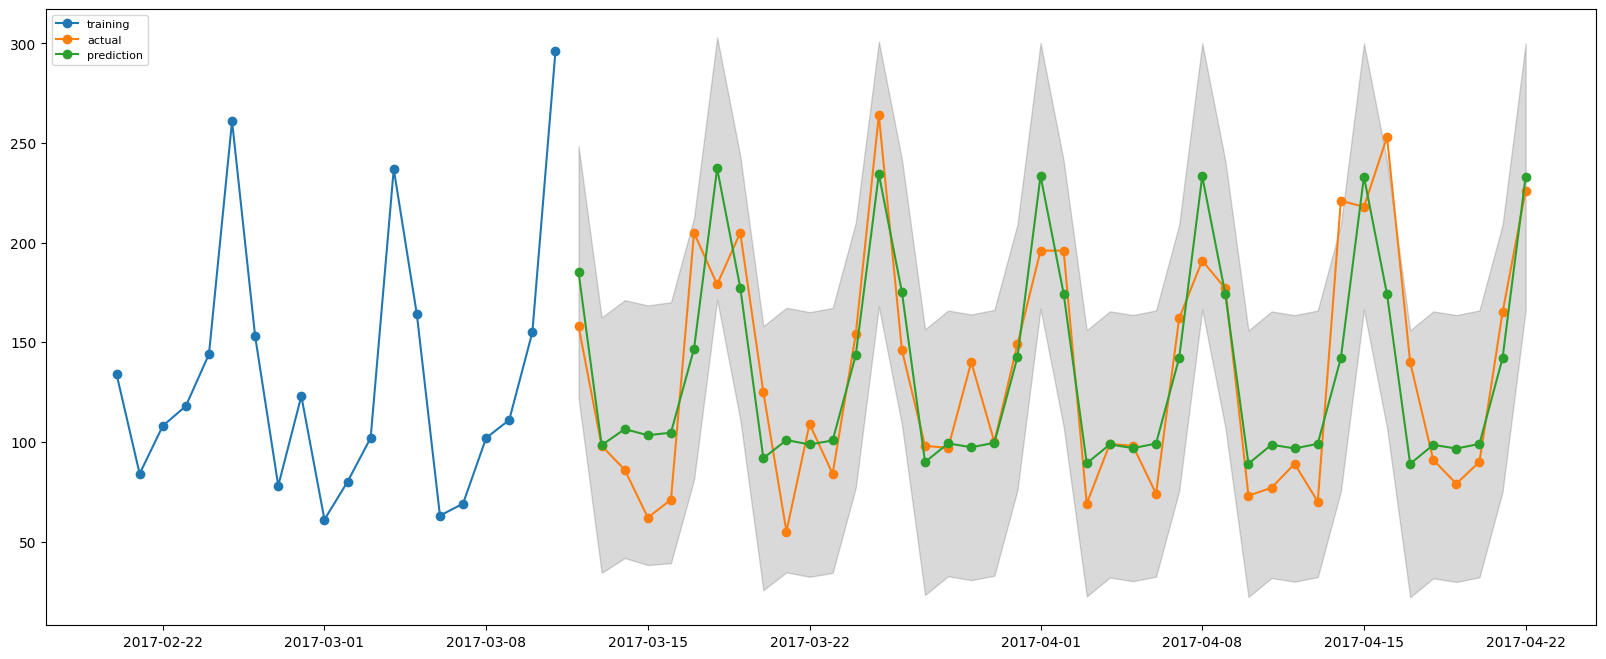

In [ ]:
test[['lower', 'upper']] = results.get_forecast(steps = 42).conf_int(0.5).values
plt.plot(train['total'][-20:], '-o', label='training')
plt.plot(test['total'], '-o', label='actual')
plt.plot(predictions, '-o', label='prediction')
plt.fill_between(test.index, test['lower'], test['upper'],
                 color='k', alpha=.15)
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [ ]:
a = results.get_forecast(steps=1).conf_int(0.05).values
a

array([[122.02500493, 248.41281056]])

In [ ]:
from IPython.display import Image
Image(url='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/007/752/original/illustration_of_change_point_detectopn_via_sliding-window.gif?1658421673')

In [ ]:
# No need to explain this
def plot_changepoints(signal, changepoints):
  for cp in changepoints:
    plt.axvline(x=cp, color='#FA8072')
  plt.plot(signal, '-*', label='signal')

  start = 0
  trends = np.array([])
  for i in changepoints:
    x = np.arange(start, i)
    y = signal[start:i]
    l1 = np.polyfit(x, y, deg=1)
    trend = x*l1[0] + l1[1]
    trends = np.append(trends, trend)
    start = i

  plt.plot(trends, label='trend')
  plt.legend()
  plt.show()

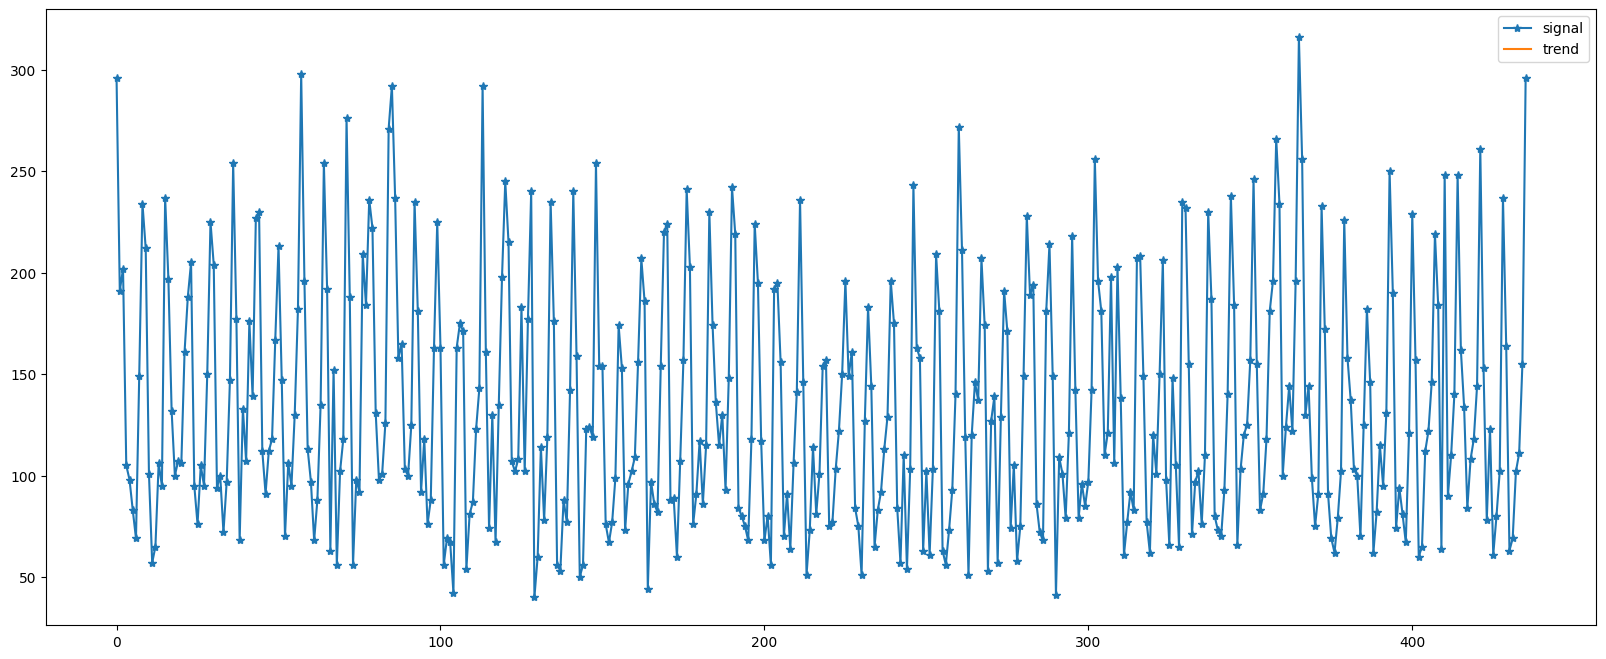

In [ ]:
signal = train.total # Stationarise for mean as cost function
window=60
def get_slope(y):
  return np.polyfit(np.arange(len(y)), y, deg=1)[0]

changepoints = signal.loc[abs(signal.rolling(window, center=True).apply(get_slope).diff()) > 7.5].index
# converting to index from dates
temp = signal.reset_index()
changepoints = temp.loc[temp['date'].isin(changepoints)].index.tolist()

plot_changepoints(signal.values, changepoints)

In [ ]:
df1 = df.copy()

In [ ]:
df1.head()

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0


In [ ]:
df1["weekday"] = np.where(((df1["weekday"] == "Friday") | (df1["weekday"] == "Thursday") | (df1["weekday"] == "Wednesday") | (df1["weekday"] == "Tuesday") | (df1["weekday"] == "Monday")), "working_day", "weekend")
intmdt = pd.get_dummies(df1['weekday'])
df1 = pd.concat([df1, intmdt],axis =1 )
df1.head()

,weekday,holiday,total,weekend,working_day
date,,,,,
2016-01-01,working_day,1,296.0,False,True
2016-01-02,weekend,0,191.0,True,False
2016-01-03,weekend,0,202.0,True,False
2016-01-04,working_day,0,105.0,False,True
2016-01-05,working_day,0,98.0,False,True


In [ ]:
df1 = df1.reset_index()

In [ ]:
df1.head()

,date,weekday,holiday,total,weekend,working_day
0,2016-01-01,working_day,1,296.0,False,True
1,2016-01-02,weekend,0,191.0,True,False
2,2016-01-03,weekend,0,202.0,True,False
3,2016-01-04,working_day,0,105.0,False,True
4,2016-01-05,working_day,0,98.0,False,True


In [ ]:
for i in range(1,32):
  df1["Lag_{}".format(i)] = df1['total'].shift(i)

In [ ]:
lis = ['Lag_{}'.format(i) for i in range(1,32)]
df1.dropna(inplace = True)    # Drop because some Lags will be NaN.
df1['last_month_avg_level'] = df1.loc[:,lis].sum(axis=1)/31
df1.head()

,date,weekday,holiday,total,weekend,working_day,Lag_1,Lag_2,Lag_3,Lag_4,...,Lag_23,Lag_24,Lag_25,Lag_26,Lag_27,Lag_28,Lag_29,Lag_30,Lag_31,last_month_avg_level
31,2016-02-01,working_day,0,94.0,False,True,204.0,225.0,150.0,95.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355
32,2016-02-02,working_day,1,100.0,False,True,94.0,204.0,225.0,150.0,...,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226
33,2016-02-03,working_day,0,72.0,False,True,100.0,94.0,204.0,225.0,...,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742
34,2016-02-04,working_day,0,97.0,False,True,72.0,100.0,94.0,204.0,...,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,129.774194
35,2016-02-05,working_day,0,147.0,False,True,97.0,72.0,100.0,94.0,...,65.0,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,129.516129


In [ ]:
lis = ['Lag_{}'.format(i) for i in range(1,8)]
df1['last_week_avg_level'] = df1.loc[:,lis].sum(axis=1)/7
df1.head(3)

,date,weekday,holiday,total,weekend,working_day,Lag_1,Lag_2,Lag_3,Lag_4,...,Lag_24,Lag_25,Lag_26,Lag_27,Lag_28,Lag_29,Lag_30,Lag_31,last_month_avg_level,last_week_avg_level
31,2016-02-01,working_day,0,94.0,False,True,204.0,225.0,150.0,95.0,...,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355,135.714286
32,2016-02-02,working_day,1,100.0,False,True,94.0,204.0,225.0,150.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226,135.571429
33,2016-02-03,working_day,0,72.0,False,True,100.0,94.0,204.0,225.0,...,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742,139.000000


In [ ]:
lis = ["Lag_{}".format(i) for i in range(1,15)]
df1['last_2week_avg_level'] = df1.loc[:,lis].sum(axis = 1)/14
df1.head(3)

,date,weekday,holiday,total,weekend,working_day,Lag_1,Lag_2,Lag_3,Lag_4,...,Lag_25,Lag_26,Lag_27,Lag_28,Lag_29,Lag_30,Lag_31,last_month_avg_level,last_week_avg_level,last_2week_avg_level
31,2016-02-01,working_day,0,94.0,False,True,204.0,225.0,150.0,95.0,...,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355,135.714286,139.214286
32,2016-02-02,working_day,1,100.0,False,True,94.0,204.0,225.0,150.0,...,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226,135.571429,136.500000
33,2016-02-03,working_day,0,72.0,False,True,100.0,94.0,204.0,225.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742,139.000000,136.500000


In [ ]:
df1['dayofweek'] = df1['date'].dt.dayofweek
df1['sale_wrt_dow'] = df1.groupby('dayofweek')['total'].transform('mean')
df1[['sale_wrt_dow', 'dayofweek']].drop_duplicates()

,sale_wrt_dow,dayofweek
31,89.593750,0
32,94.531250,1
33,94.687500,2
34,99.015625,3
35,147.171875,4
36,229.125000,5
37,178.460317,6


In [ ]:
df1.head()

,date,weekday,holiday,total,weekend,working_day,Lag_1,Lag_2,Lag_3,Lag_4,...,Lag_27,Lag_28,Lag_29,Lag_30,Lag_31,last_month_avg_level,last_week_avg_level,last_2week_avg_level,dayofweek,sale_wrt_dow
31,2016-02-01,working_day,0,94.0,False,True,204.0,225.0,150.0,95.0,...,98.0,105.0,202.0,191.0,296.0,143.419355,135.714286,139.214286,0,89.593750
32,2016-02-02,working_day,1,100.0,False,True,94.0,204.0,225.0,150.0,...,83.0,98.0,105.0,202.0,191.0,136.903226,135.571429,136.500000,1,94.531250
33,2016-02-03,working_day,0,72.0,False,True,100.0,94.0,204.0,225.0,...,69.0,83.0,98.0,105.0,202.0,133.967742,139.000000,136.500000,2,94.687500
34,2016-02-04,working_day,0,97.0,False,True,72.0,100.0,94.0,204.0,...,149.0,69.0,83.0,98.0,105.0,129.774194,134.285714,134.000000,3,99.015625
35,2016-02-05,working_day,0,147.0,False,True,97.0,72.0,100.0,94.0,...,234.0,149.0,69.0,83.0,98.0,129.516129,134.571429,133.357143,4,147.171875


In [ ]:
import copy             #dfo has the data with all the columns
dfo = df1.copy()
df1 = dfo.copy()

In [ ]:
df1 = df1[['total', 'Lag_1', 'last_month_avg_level', 'last_week_avg_level',
          'last_2week_avg_level', 'sale_wrt_dow', 'holiday']]
df1.head()

,total,Lag_1,last_month_avg_level,last_week_avg_level,last_2week_avg_level,sale_wrt_dow,holiday
31,94.0,204.0,143.419355,135.714286,139.214286,89.593750,0
32,100.0,94.0,136.903226,135.571429,136.500000,94.531250,1
33,72.0,100.0,133.967742,139.000000,136.500000,94.687500,0
34,97.0,72.0,129.774194,134.285714,134.000000,99.015625,0
35,147.0,97.0,129.516129,134.571429,133.357143,147.171875,0


In [ ]:
train = df1.iloc[:df1.shape[0]-42].dropna()
test = df1.iloc[df1.shape[0]-42:]


train_X = train.drop(["total"],axis =1)
train_y = train['total']
test_X = test.drop(["total"],axis =1)
test_y = test['total']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as mape

# Train and pred
model = LinearRegression()
model.fit(train_X, train_y)
y_pred = pd.Series(model.predict(test_X), index=test.index)
mape(test['total'],y_pred)

0.1550950649148067

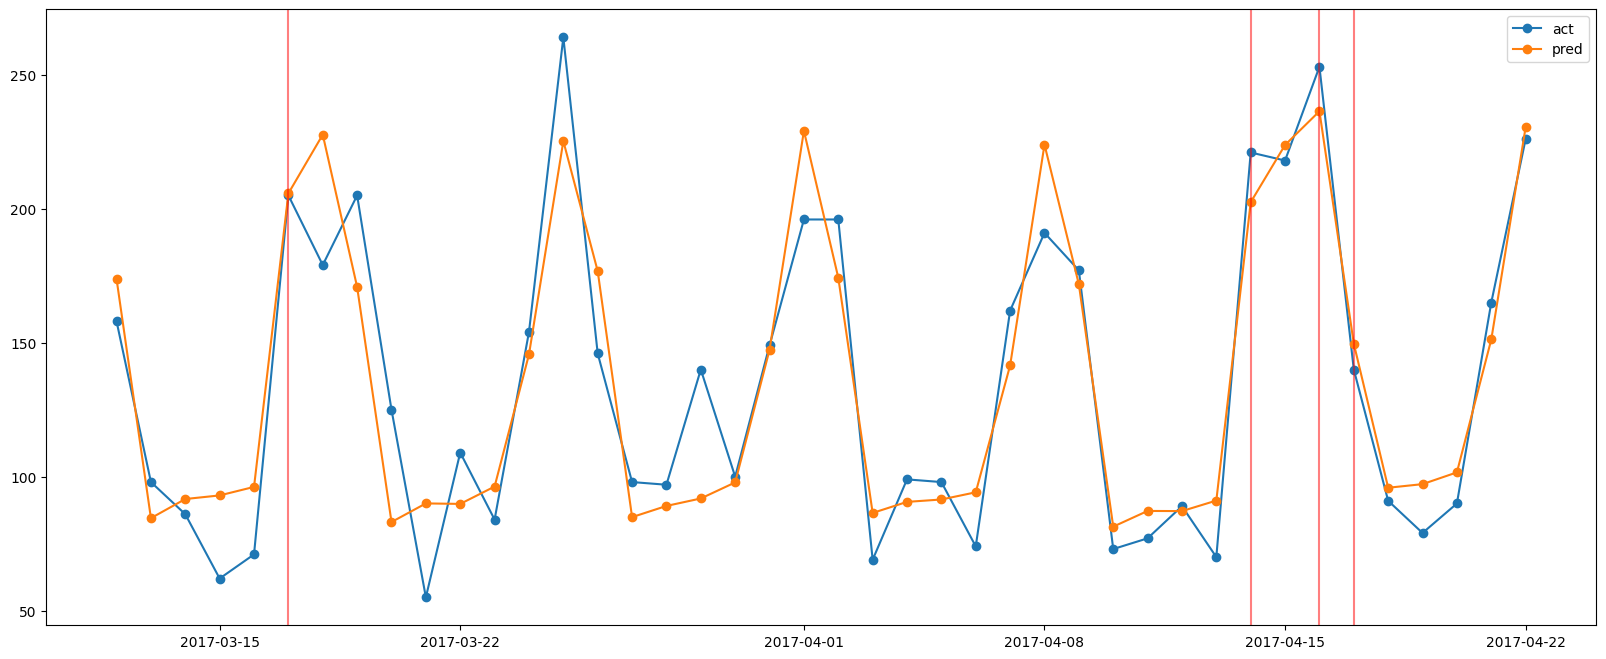

In [ ]:
plt.plot(dfo.tail(42)['date'], test_y, '-o', label='act')
plt.plot(dfo.tail(42)['date'], y_pred, '-o', label='pred')
for x in dfo[-42:].query('holiday==1')['date']:
    plt.axvline(x=x, color='red', alpha = 0.5)
plt.legend()

In [ ]:
!pip install pystan~=2.14
!pip install fbprophet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.2/16.2 MB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pystan
  Running setup.py clean for pystan
Failed to build pystan
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pystan)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 44.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1

In [ ]:
df2 = df.copy()

In [ ]:
df2.head()

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0


In [ ]:
df2.reset_index(inplace = True)

In [ ]:
df2.head()

,date,weekday,holiday,total
0,2016-01-01,Friday,1,296.0
1,2016-01-02,Saturday,0,191.0
2,2016-01-03,Sunday,0,202.0
3,2016-01-04,Monday,0,105.0
4,2016-01-05,Tuesday,0,98.0


In [ ]:
df2['ds'] = pd.to_datetime(df2['date'])
df2['y'] = df2['total']
df2 = df2[['ds', 'y', 'holiday']]
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   ds       478 non-null    datetime64[ns]
 1   y        478 non-null    float64       
 2   holiday  478 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 11.3 KB


In [ ]:
df2.head()

,ds,y,holiday
0,2016-01-01,296.0,1
1,2016-01-02,191.0,0
2,2016-01-03,202.0,0
3,2016-01-04,105.0,0
4,2016-01-05,98.0,0


In [ ]:
!pip install prophet

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


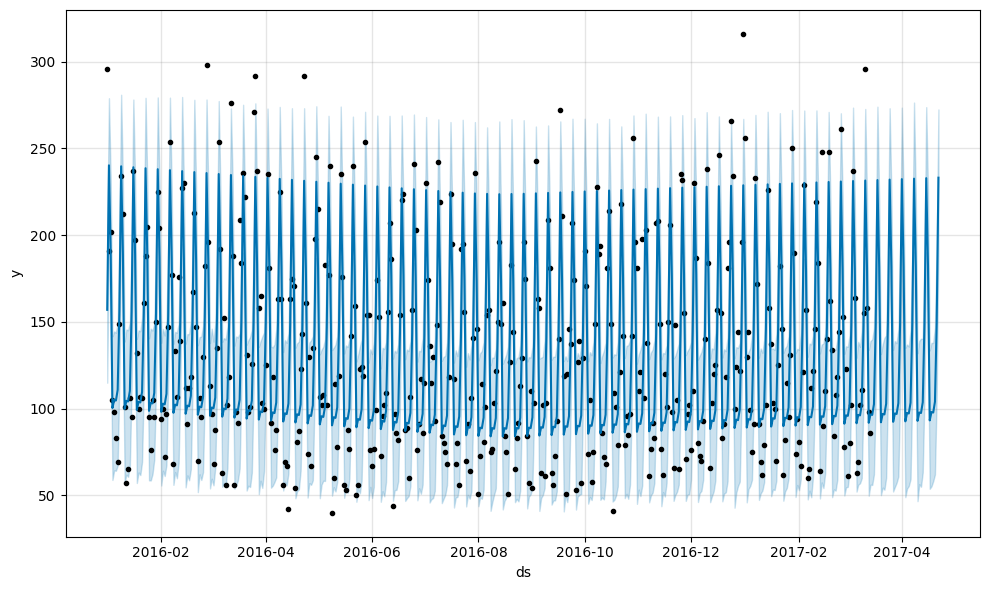

In [ ]:
from prophet import Prophet
m = Prophet()
m.fit(df2[['ds', 'y']][:-39]) #here we are leaving last 39 observations because we will predict it in 'future'
future = m.make_future_dataframe(periods=39,freq="D")
forecast = m.predict(future)
fig = m.plot(forecast)

In [ ]:
forecast.tail(4)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
474,2017-04-19,136.918765,58.219607,137.915380,136.704129,137.135528,-39.142391,-39.142391,-39.142391,-39.142391,-39.142391,-39.142391,0.0,0.0,0.0,97.776374
475,2017-04-20,136.957875,62.125850,146.749258,136.731801,137.184298,-32.977311,-32.977311,-32.977311,-32.977311,-32.977311,-32.977311,0.0,0.0,0.0,103.980563
476,2017-04-21,136.996984,107.533176,193.156176,136.759408,137.232028,12.738447,12.738447,12.738447,12.738447,12.738447,12.738447,0.0,0.0,0.0,149.735431
477,2017-04-22,137.036094,191.595386,272.473983,136.785227,137.284526,96.107431,96.107431,96.107431,96.107431,96.107431,96.107431,0.0,0.0,0.0,233.143525


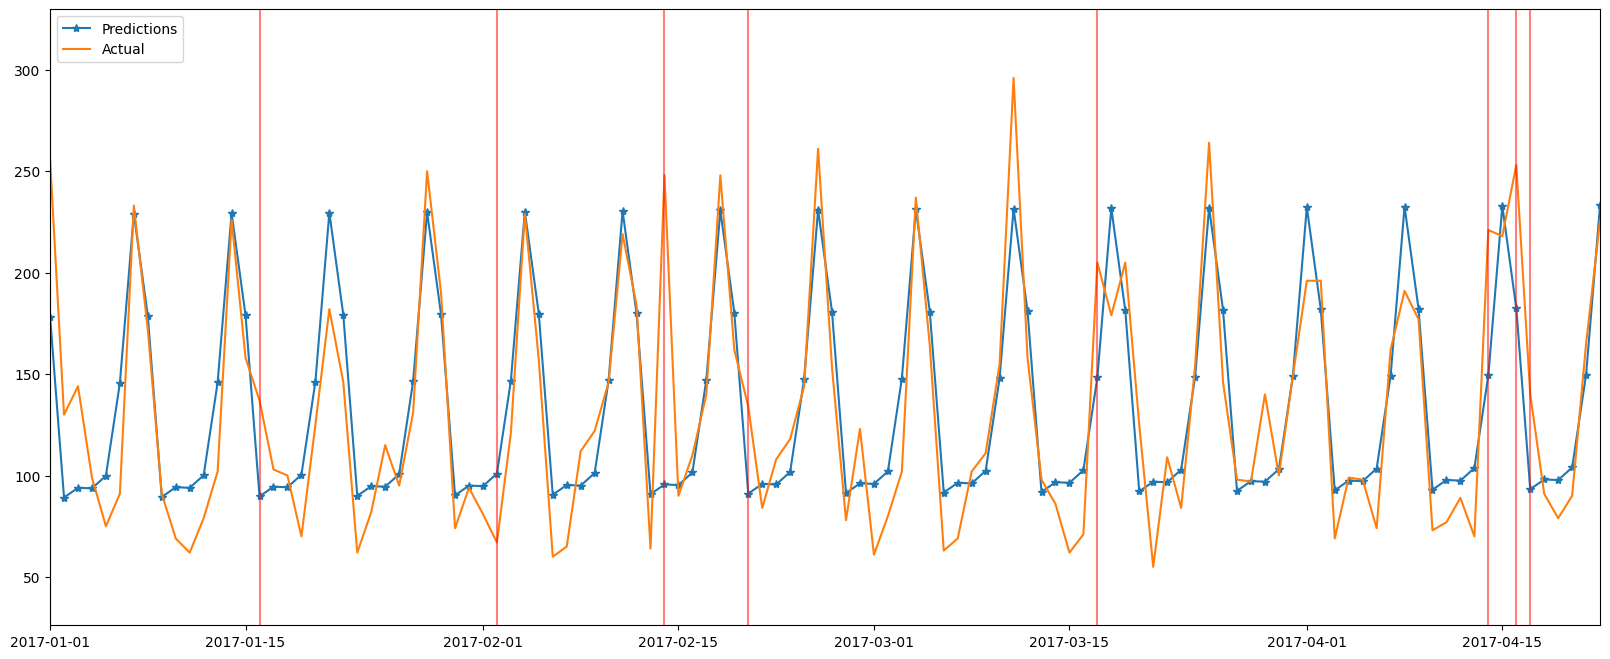

In [ ]:
plt.plot(forecast['ds'], forecast['yhat'],'-*', label = 'Predictions')
plt.plot(df2['ds'], df2['y'], label = 'Actual')
for x in df2.query('holiday==1')['ds']:
    plt.axvline(x=x, color='red', alpha = 0.5);
plt.xlim(pd.to_datetime('2017-01-01'), pd.to_datetime('2017-04-22'))
plt.legend()

In [ ]:
performance(df2['y'][:-39],forecast['yhat'][:-39])

MAE: 24.01
MSE: 1029.57
MAPE: 0.21


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


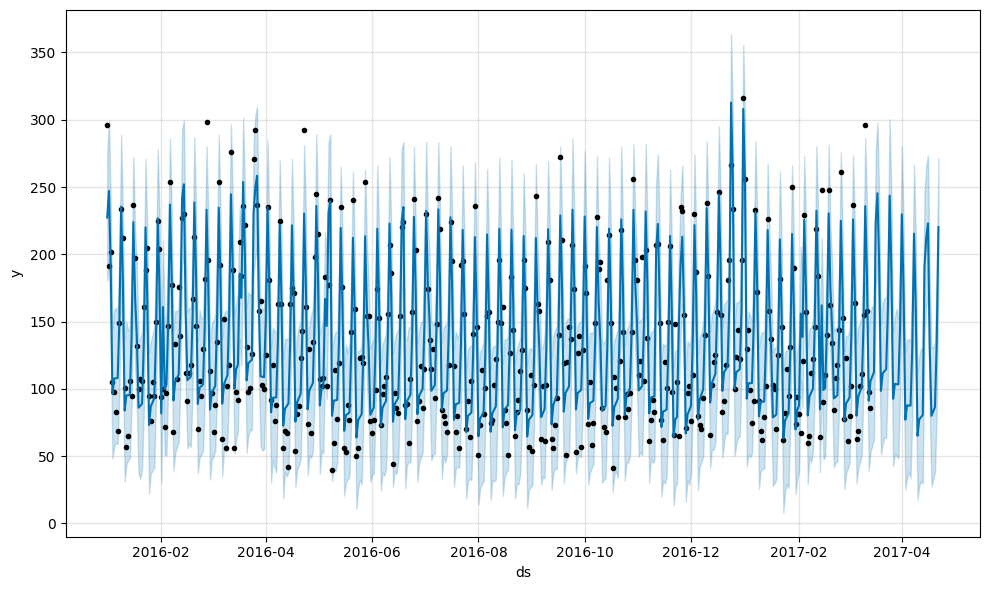

In [ ]:
model2=Prophet(interval_width=0.95, yearly_seasonality=True, weekly_seasonality=True,
               changepoint_prior_scale=4)
model2.add_regressor('holiday') #adding holidays data in the model3
model2.fit(df2[:-39])
forecast2 = model2.predict(df2)
fig = model2.plot(forecast2)

In [ ]:
performance(df2['y'][:-39],forecast2['yhat'][:-39])

MAE: 20.15
MSE: 671.16
MAPE: 0.18


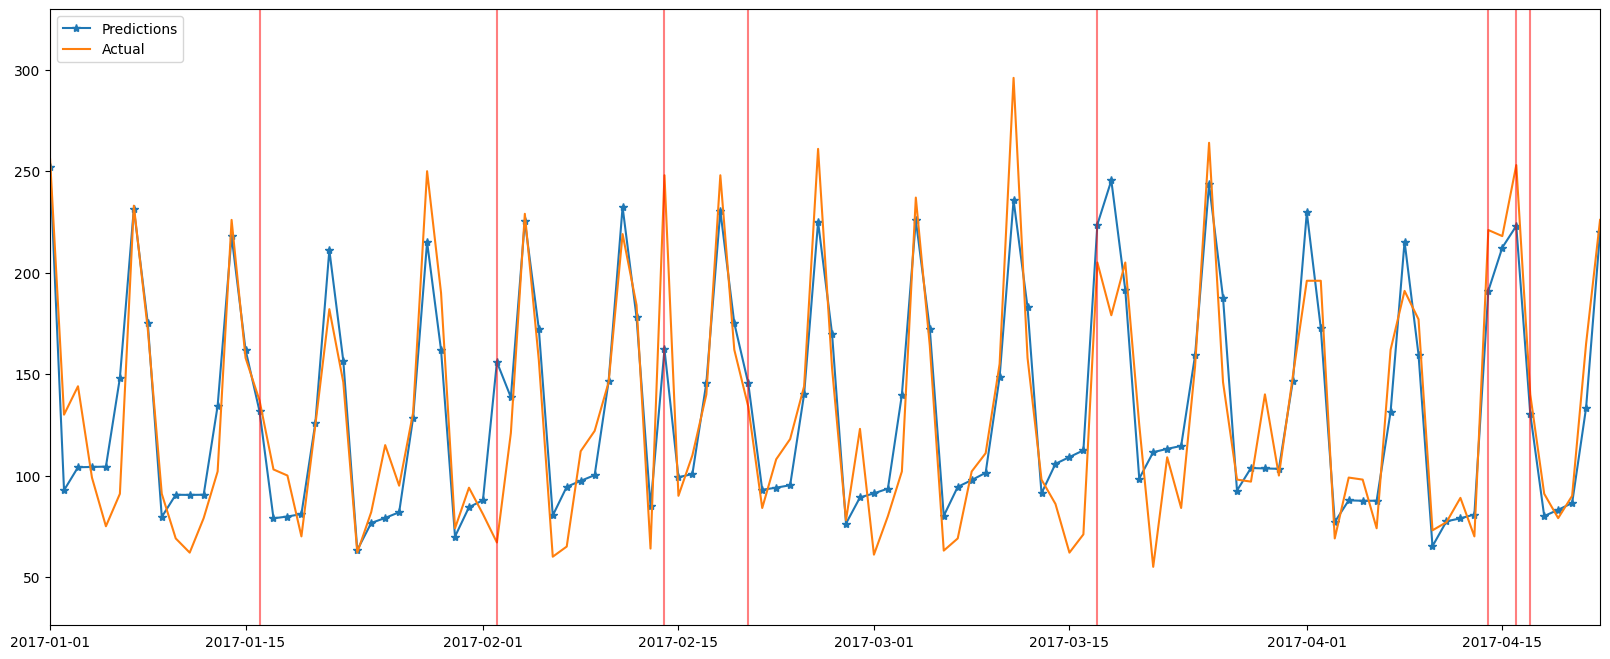

In [ ]:
plt.plot(forecast2['ds'], forecast2['yhat'],'-*', label = 'Predictions')
plt.plot(df2['ds'], df2['y'], label = 'Actual')
plt.xlim(pd.to_datetime('2017-01-01'), pd.to_datetime('2017-04-22'))
for x in df2.query('holiday==1')['ds']:
    plt.axvline(x=x, color='red', alpha = 0.5);
plt.legend()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


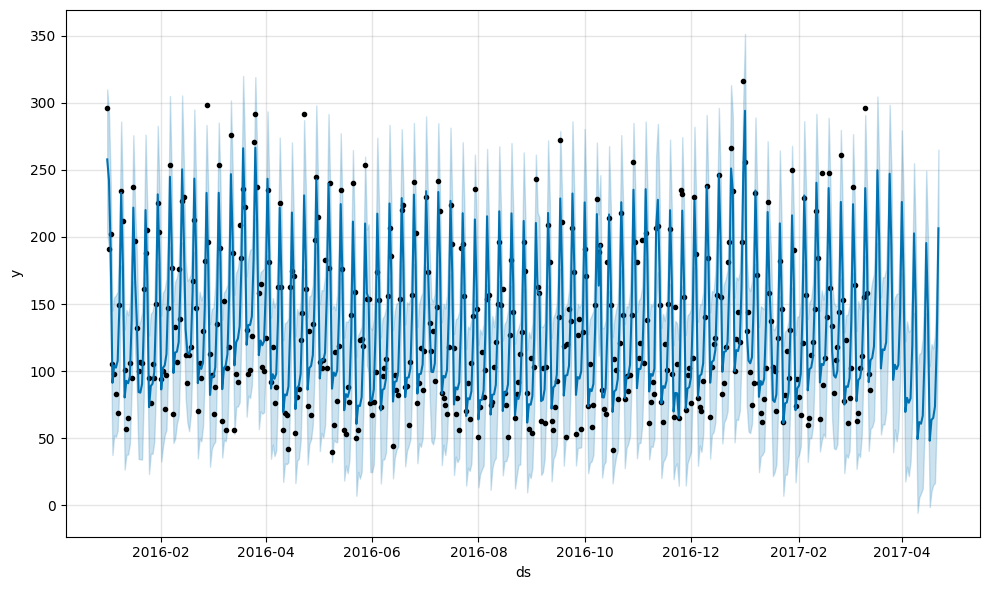

In [ ]:
model3=Prophet(interval_width=0.95, yearly_seasonality=True, weekly_seasonality=True,
               changepoint_prior_scale=4)
model3.add_country_holidays(country_name='US') #adding holidays data in the model2
model3.fit(df2[:-39])
future = m.make_future_dataframe(periods=39,freq="D")
forecast3 = model3.predict(df2)
fig = model3.plot(forecast3)

In [ ]:
performance(df2['y'][:-39],forecast3['yhat'][:-39])

MAE: 20.59
MSE: 744.28
MAPE: 0.18


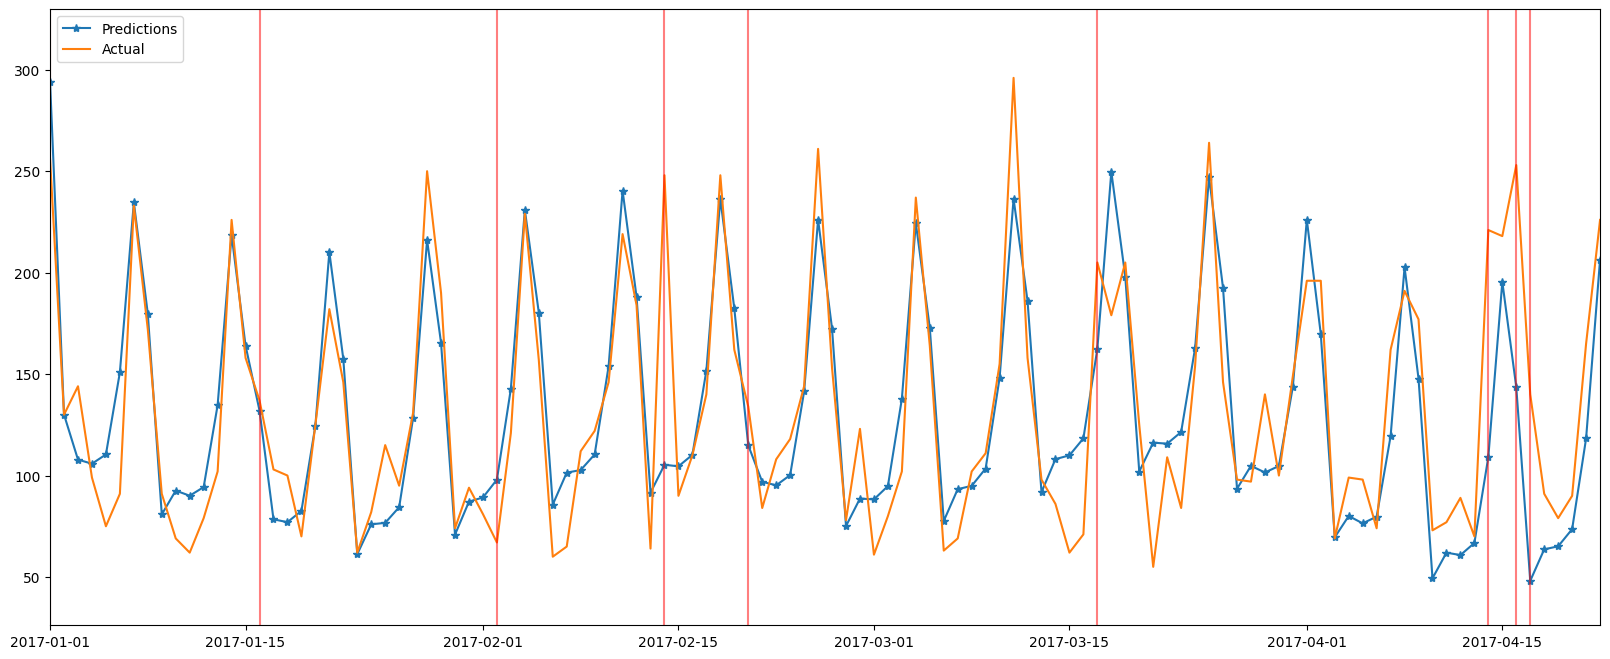

In [ ]:
plt.plot(forecast3['ds'], forecast3['yhat'],'-*', label = 'Predictions')
plt.plot(df2['ds'], df2['y'], label = 'Actual')
plt.xlim(pd.to_datetime('2017-01-01'), pd.to_datetime('2017-04-22'))
for x in df2.query('holiday==1')['ds']:
    plt.axvline(x=x, color='red', alpha = 0.5);
plt.legend()

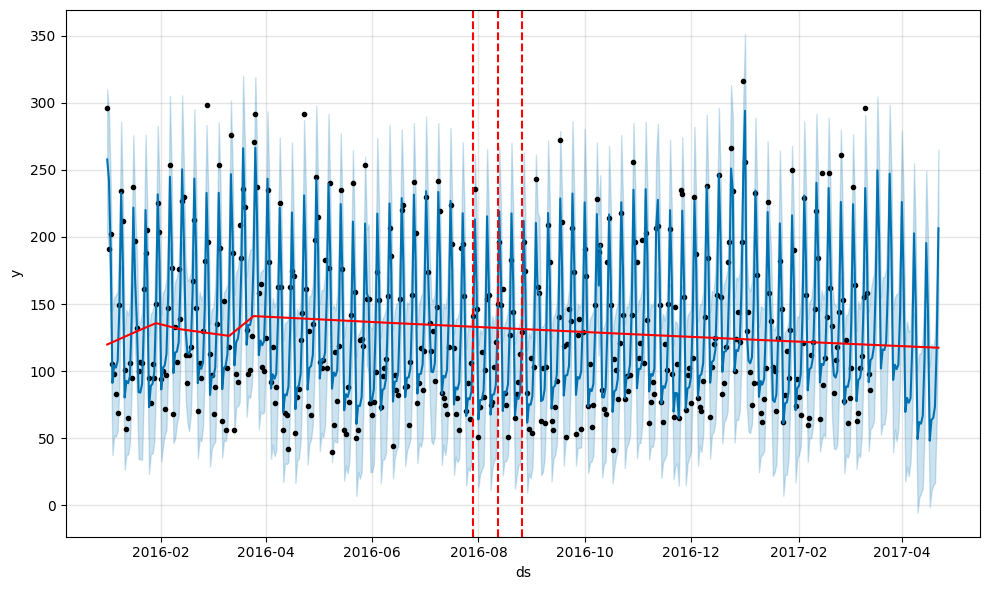

In [ ]:
from prophet.plot import add_changepoints_to_plot
fig = m.plot(forecast3)
a = add_changepoints_to_plot(fig.gca(), m, forecast3)